# Кейс 7 Обученная модель бинарной классификации, определяющая вероятность отказа оборудования
## Нужно предсказать, произойдёт ли отказ оборудования на основе его технических характеристик, условий эксплуатации и истории работы

- Импорт и анализ исторических данных
- Предобработка и очистка данных
- Обучение модели (SVM, деревья решений)
- Оценка метрик precision, recall, ROC-AUC

###  Участники
- Скрипин Сергей
- Яньшин Александр
- Ненилин Владислав
- Дроздюков Владимир
- Исангузин Ильдар
- Валиуллин Эдуард Римович

# Анализ структуры данных

Метод `df.info()` покажет:

## Основную информацию:
- Количество строк (наблюдений)
- Количество столбцов (признаков)
- Имена всех столбцов
- Типы данных каждого столбца (int64, float64, object и т.д.)
- Количество non-null значений в каждом столбце
- Объем используемой памяти

## Что это даст:
- Понимание полноты данных (пропуски)
- Определение типов переменных (числовые/категориальные)
- Оценка общего размера датасета
- Выявление потенциальных проблем с типами данных

1. Загрузка train.csv и базовый просмотр

In [1]:
# import warnings
# warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

url_train = "https://raw.githubusercontent.com/dvigatelizm/keis7/main/train.csv"
df = pd.read_csv(url_train)
#df = pd.read_csv("train.csv")
print("Размер датасета:", df.shape)
print("\nСтолбцы:\n", df.columns.tolist())
df.head(10)


Размер датасета: (136429, 14)

Столбцы:
 ['id', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']


,id,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,0,L50096,L,300.6,309.6,1596,36.1,140,0,0,0,0,0,0
1,1,M20343,M,302.6,312.1,1759,29.1,200,0,0,0,0,0,0
2,2,L49454,L,299.3,308.5,1805,26.5,25,0,0,0,0,0,0
3,3,L53355,L,301.0,310.9,1524,44.3,197,0,0,0,0,0,0
4,4,M24050,M,298.0,309.0,1641,35.4,34,0,0,0,0,0,0
5,5,M24300,M,298.4,308.9,1429,42.1,65,0,0,0,0,0,0
6,6,L56736,L,299.6,311.0,1413,42.9,156,0,0,0,0,0,0
7,7,L55488,L,298.7,310.1,1609,38.1,67,0,0,0,0,0,0
8,8,L56397,L,297.7,308.8,1578,35.2,13,0,0,0,0,0,0
9,9,L55067,L,300.5,312.3,1447,53.3,98,0,0,0,0,0,0


## 2. Анализ данных

### 2.1 Проверка уникальности идентификаторов 'id' и 'Product ID'

In [2]:
print("Уникальных id:", df['id'].nunique(), "из", len(df))
print("Уникальных Product ID:", df['Product ID'].nunique())


Уникальных id: 136429 из 136429
Уникальных Product ID: 9976


### Вывод 

- id — уникальный технический идентификатор.
Он не несёт смысловой информации поэтому исключаем его из признаков.

- Product ID повторяется многократно, что указывает на наличие нескольких записей для одного оборудования.

Это важно — такие группы должны быть разнесены при разбиении данных, иначе модель «подглядит» информацию о продукте и метрики будут нечестными

### 2.2 Анализ количества строк на один Product ID

In [3]:

prod_counts = df['Product ID'].value_counts()
grouped_counts = prod_counts.value_counts().sort_index()

print("Сколько Product ID имеют одинаковое число строк")
for number_of_rows, how_many_products in grouped_counts.items():
    print(f"Объект с {number_of_rows} строками: {how_many_products}")

Сколько Product ID имеют одинаковое число строк
Объект с 1 строками: 85
Объект с 2 строками: 196
Объект с 3 строками: 295
Объект с 4 строками: 450
Объект с 5 строками: 547
Объект с 6 строками: 625
Объект с 7 строками: 636
Объект с 8 строками: 633
Объект с 9 строками: 616
Объект с 10 строками: 654
Объект с 11 строками: 567
Объект с 12 строками: 530
Объект с 13 строками: 458
Объект с 14 строками: 431
Объект с 15 строками: 375
Объект с 16 строками: 346
Объект с 17 строками: 280
Объект с 18 строками: 238
Объект с 19 строками: 214
Объект с 20 строками: 188
Объект с 21 строками: 171
Объект с 22 строками: 147
Объект с 23 строками: 115
Объект с 24 строками: 140
Объект с 25 строками: 116
Объект с 26 строками: 86
Объект с 27 строками: 64
Объект с 28 строками: 67
Объект с 29 строками: 69
Объект с 30 строками: 53
Объект с 31 строками: 37
Объект с 32 строками: 40
Объект с 33 строками: 34
Объект с 34 строками: 34
Объект с 35 строками: 28
Объект с 36 строками: 24
Объект с 37 строками: 21
Объект с 38 

### Анализ корреляций и рекомендации по использованию признаков

На основе полученных корреляций дадим рекомендации, какие признаки стоит использовать для обучения модели.


In [5]:
# Анализ корреляций и рекомендации
import pandas as pd

# Корреляции из предыдущего анализа
correlations = {
    'RelationTemperature': 0.0849,
    'TorqueRPM': 0.1566,
    'WearRPM': 0.0721,
    'ToolWearTorque': 0.0311,
    'TotalF': 0.8405,
    'Power_W': 0.1282,
    'Energy_J': 0.0942
}

# Создаем DataFrame для анализа
corr_df = pd.DataFrame(list(correlations.items()), columns=['Признак', 'Корреляция'])
corr_df = corr_df.sort_values('Корреляция', ascending=False)

print("="*80)
print("АНАЛИЗ КОРРЕЛЯЦИЙ И РЕКОМЕНДАЦИИ ПО ИСПОЛЬЗОВАНИЮ ПРИЗНАКОВ")
print("="*80)
print("\n📊 Корреляции с целевой переменной Machine failure:\n")
print(corr_df.to_string(index=False))

# Классификация признаков
high_priority = corr_df[corr_df['Корреляция'] >= 0.12]
medium_priority = corr_df[(corr_df['Корреляция'] >= 0.08) & (corr_df['Корреляция'] < 0.12)]
low_priority = corr_df[corr_df['Корреляция'] < 0.08]

print("\n" + "="*80)
print("🎯 РЕКОМЕНДАЦИИ ПО ИСПОЛЬЗОВАНИЮ:")
print("="*80)

print("\n✅ ВЫСОКИЙ ПРИОРИТЕТ (рекомендуется использовать):")
for _, row in high_priority.iterrows():
    print(f"  • {row['Признак']:25s} (корреляция: {row['Корреляция']:.4f})")
    if row['Признак'] == 'TotalF':
        print("      ⚠️  ВНИМАНИЕ: Очень высокая корреляция! Может быть избыточен,")
        print("          если уже используются TWF, HDF, PWF, OSF. Проверьте мультиколлинеарность.")

print("\n⚠️  СРЕДНИЙ ПРИОРИТЕТ (можно протестировать):")
for _, row in medium_priority.iterrows():
    print(f"  • {row['Признак']:25s} (корреляция: {row['Корреляция']:.4f})")

print("\n❌ НИЗКИЙ ПРИОРИТЕТ (можно исключить):")
for _, row in low_priority.iterrows():
    print(f"  • {row['Признак']:25s} (корреляция: {row['Корреляция']:.4f})")

print("\n" + "="*80)
print("💡 ДОПОЛНИТЕЛЬНЫЕ РЕКОМЕНДАЦИИ:")
print("="*80)
print("""
1. ОБЯЗАТЕЛЬНО ИСПОЛЬЗОВАТЬ:
   • TotalF - очень высокая корреляция (0.8405), но проверьте взаимодействие с исходными флагами
   • TorqueRPM - умеренная корреляция (0.1566), полезен для выявления аномалий
   • Power_W - умеренная корреляция (0.1282), физически интерпретируемый признак

2. ПРОТЕСТИРОВАТЬ:
   • Energy_J - слабая, но положительная корреляция (0.0942)
   • RelationTemperature - слабая корреляция (0.0849)

3. ИСКЛЮЧИТЬ:
   • ToolWearTorque - почти нет корреляции (0.0311)
   • WearRPM - очень слабая корреляция (0.0721)

4. ВАЖНО ПРОВЕРИТЬ:
   • Мультиколлинеарность между TotalF и исходными флагами (TWF, HDF, PWF, OSF)
   • Взаимосвязь между Power_W и TorqueRPM
   • Для нелинейных моделей (деревья, ансамбли) даже слабые корреляции могут быть полезны
""")

# Список рекомендуемых признаков
recommended_features = high_priority['Признак'].tolist()
print("\n📋 РЕКОМЕНДУЕМЫЙ СПИСОК ПРИЗНАКОВ ДЛЯ ОБУЧЕНИЯ:")
print(f"   {recommended_features}")
print("\n" + "="*80)


АНАЛИЗ КОРРЕЛЯЦИЙ И РЕКОМЕНДАЦИИ ПО ИСПОЛЬЗОВАНИЮ ПРИЗНАКОВ

📊 Корреляции с целевой переменной Machine failure:

            Признак  Корреляция
             TotalF      0.8405
          TorqueRPM      0.1566
            Power_W      0.1282
           Energy_J      0.0942
RelationTemperature      0.0849
            WearRPM      0.0721
     ToolWearTorque      0.0311

🎯 РЕКОМЕНДАЦИИ ПО ИСПОЛЬЗОВАНИЮ:

✅ ВЫСОКИЙ ПРИОРИТЕТ (рекомендуется использовать):
  • TotalF                    (корреляция: 0.8405)
      ⚠️  ВНИМАНИЕ: Очень высокая корреляция! Может быть избыточен,
          если уже используются TWF, HDF, PWF, OSF. Проверьте мультиколлинеарность.
  • TorqueRPM                 (корреляция: 0.1566)
  • Power_W                   (корреляция: 0.1282)

⚠️  СРЕДНИЙ ПРИОРИТЕТ (можно протестировать):
  • Energy_J                  (корреляция: 0.0942)
  • RelationTemperature       (корреляция: 0.0849)

❌ НИЗКИЙ ПРИОРИТЕТ (можно исключить):
  • WearRPM                   (корреляция: 0.0721)
  

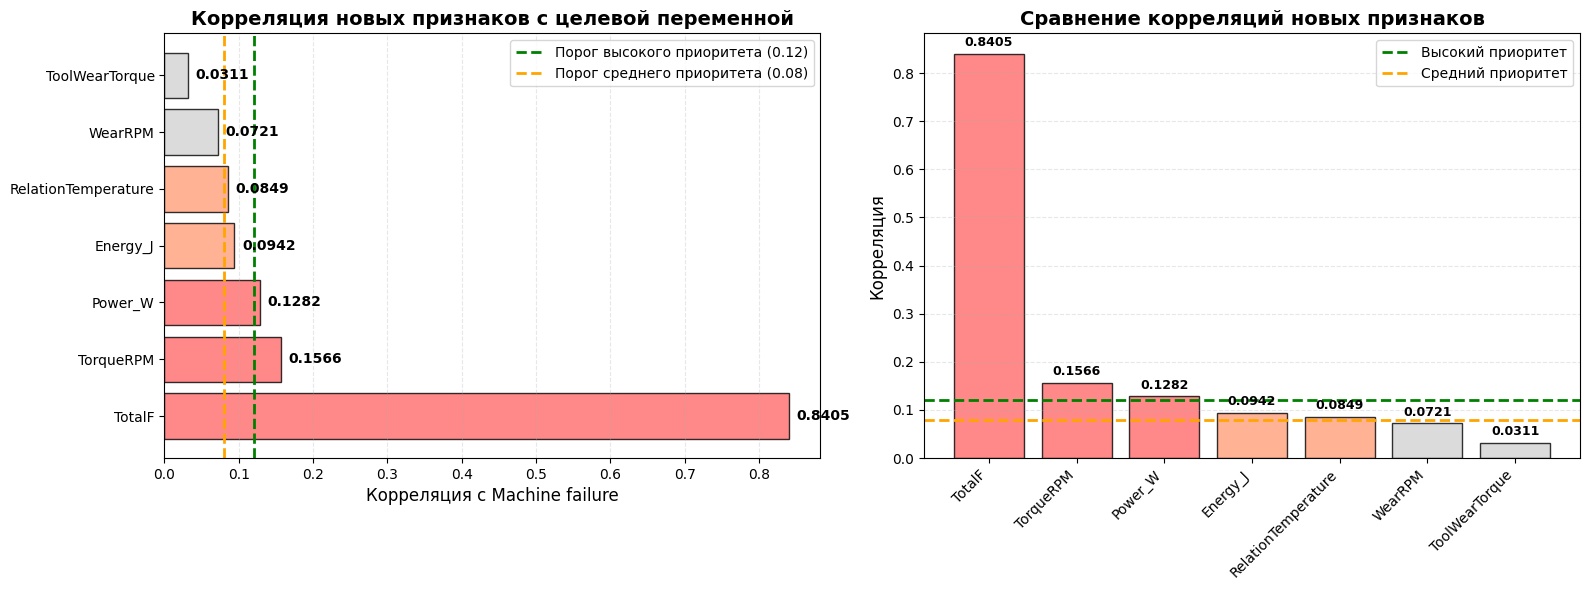


📊 График сохранен в 'feature_correlations_analysis.png'


In [6]:
# Визуализация корреляций
import matplotlib.pyplot as plt
import numpy as np

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# График 1: Столбчатая диаграмма корреляций
colors = ['#FF6B6B' if x >= 0.12 else '#FFA07A' if x >= 0.08 else '#D3D3D3' 
          for x in corr_df['Корреляция'].values]
bars = ax1.barh(corr_df['Признак'], corr_df['Корреляция'], color=colors, alpha=0.8, edgecolor='black')
ax1.axvline(x=0.12, color='green', linestyle='--', linewidth=2, label='Порог высокого приоритета (0.12)')
ax1.axvline(x=0.08, color='orange', linestyle='--', linewidth=2, label='Порог среднего приоритета (0.08)')
ax1.set_xlabel('Корреляция с Machine failure', fontsize=12)
ax1.set_title('Корреляция новых признаков с целевой переменной', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(axis='x', alpha=0.3, linestyle='--')

# Добавляем значения на столбцы
for i, (bar, corr) in enumerate(zip(bars, corr_df['Корреляция'])):
    ax1.text(corr + 0.01 if corr >= 0 else corr - 0.01, i, 
            f'{corr:.4f}', va='center', fontsize=10, fontweight='bold')

# График 2: Сравнение с базовыми признаками (если доступны)
# Для примера показываем только новые признаки
ax2.bar(range(len(corr_df)), corr_df['Корреляция'], color=colors, alpha=0.8, edgecolor='black')
ax2.set_xticks(range(len(corr_df)))
ax2.set_xticklabels(corr_df['Признак'], rotation=45, ha='right')
ax2.set_ylabel('Корреляция', fontsize=12)
ax2.set_title('Сравнение корреляций новых признаков', fontsize=14, fontweight='bold')
ax2.axhline(y=0.12, color='green', linestyle='--', linewidth=2, label='Высокий приоритет')
ax2.axhline(y=0.08, color='orange', linestyle='--', linewidth=2, label='Средний приоритет')
ax2.legend()
ax2.grid(axis='y', alpha=0.3, linestyle='--')

# Добавляем значения на столбцы
for i, corr in enumerate(corr_df['Корреляция']):
    ax2.text(i, corr + 0.01 if corr >= 0 else corr - 0.01, 
            f'{corr:.4f}', ha='center', va='bottom' if corr >= 0 else 'top', 
            fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig("feature_correlations_analysis.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 График сохранен в 'feature_correlations_analysis.png'")


### Визуализация распределения количества записей на один продукт

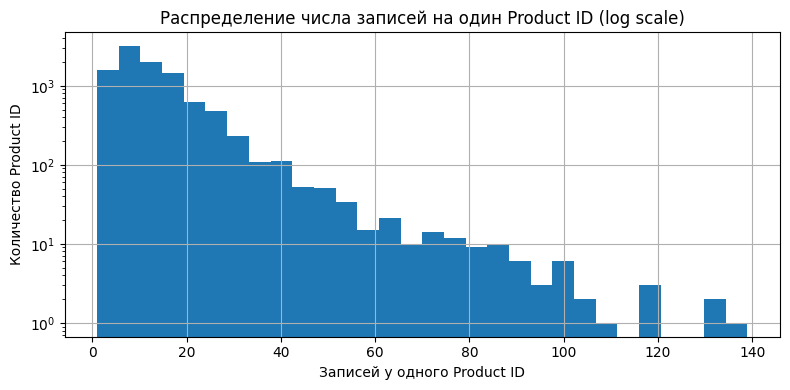

In [7]:
plt.figure(figsize=(8,4))
prod_counts.hist(bins=30)
plt.yscale('log')
plt.title("Распределение числа записей на один Product ID (log scale)")
plt.xlabel("Записей у одного Product ID")
plt.ylabel("Количество Product ID")
plt.tight_layout()
plt.savefig("productid_repeat_hist.png", dpi=150)
plt.show()


### Вывод 

- Большинство Product ID встречаются несколько раз, а не один.

- Это означает, что строки внутри одного Product ID коррелируют между собой.
 Чтобы избежать утечки информации при обучении, нужно использовать GroupShuffleSplit по Product ID.
Это важнейшее основание для корректного формирования выборок.

### 2.3 Анализ целевой переменной Machine failure

Machine failure
0    134281
1      2148
Name: count, dtype: int64


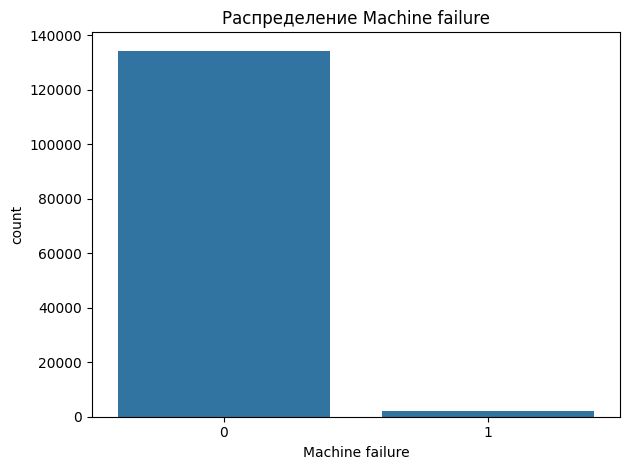

In [8]:
print(df['Machine failure'].value_counts())
sns.countplot(x='Machine failure', data=df)
plt.title("Распределение Machine failure")
plt.tight_layout()
plt.savefig("machine_failure_count.png", dpi=150)
plt.show()



## Вывод
- Класс «нет отказа» — 98.43%
- Класс «отказ» — 1.57%

### Датасет несбалансирован.

Выводы:
Нужна балансировка так как при обучении модель будет думать что отказов почти нет и всегда говорить 0

На первом этапе предлагаем использовать SMOTE Потому что это самый простой и быстрый способ


### 2.4 Анализ флагов (TWF, HDF, PWF, OSF, RNF)

#### 2.4.1 Корреляция между флагами отказа и целевой функцией

In [9]:
# Список флагов
flags = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']

# True Positive: хотя бы один флаг = 1 и Machine failure = 1
tp_flags = df[(df[flags].sum(axis=1) > 0) & (df['Machine failure'] == 1)].shape[0]

# False Positive: хотя бы один флаг = 1, но Machine failure = 0
leak_fp = df[(df[flags].sum(axis=1) > 0) & (df['Machine failure'] == 0)].shape[0]

# False Negative: все флаги = 0, но Machine failure = 1
leak_fn = df[(df[flags].sum(axis=1) == 0) & (df['Machine failure'] == 1)].shape[0]

# Всего отказов
total_failures = df[df['Machine failure'] == 1].shape[0]

# Процент корректных сигналов
tp_percent = tp_flags / total_failures * 100

print("Случаи, когда хотя бы один флаг = 1, но Machine failure = 0 (утечка):", leak_fp)
print("Случаи, когда все флаги (TWF, HDF, PWF, OSF, RNF) равны 0, а Machine failure = 1 (пропущенные сигналы):", leak_fn)
print(f"Процент корректных сигналов флагов среди всех отказов: {tp_percent:.2f}%")
print(f"Сигналов отказов всего: {total_failures}")


Случаи, когда хотя бы один флаг = 1, но Machine failure = 0 (утечка): 315
Случаи, когда все флаги (TWF, HDF, PWF, OSF, RNF) равны 0, а Machine failure = 1 (пропущенные сигналы): 507
Процент корректных сигналов флагов среди всех отказов: 76.40%
Сигналов отказов всего: 2148


- Случаи, когда хотя бы один флаг = 1, но Machine failure = 0 (утечка): 315  
говорит нам о том что у нас 315 случаев нарушения логики 

- Случаи, когда все флаги (TWF, HDF, PWF, OSF, RNF) равны 0,  
 а Machine failure = 1 (пропущенные сигналы):   507  

#### 2.4.2 Разберемся случаев нарушения логики огда хотя бы один флаг = 1, но Machine failure = 0




     Leak count
RNF         302
HDF           6
OSF           4
PWF           3
TWF           0


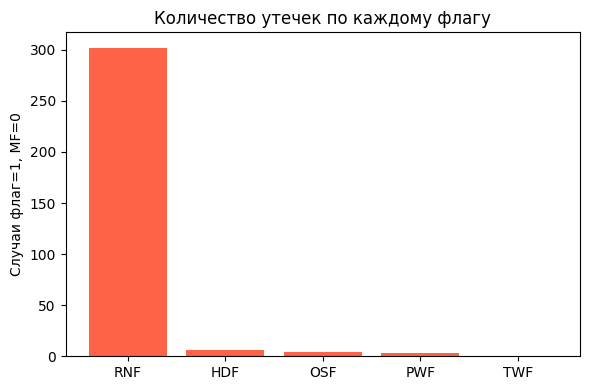

In [10]:
# Список флагов
flags = ['TWF','HDF','PWF','OSF','RNF']

# Создаём DataFrame для утечек
leak_per_flag = {}

for f in flags:
    leak_count = df[(df[f]==1) & (df['Machine failure']==0)].shape[0]
    leak_per_flag[f] = leak_count

leak_df = pd.DataFrame.from_dict(leak_per_flag, orient='index', columns=['Leak count'])
leak_df = leak_df.sort_values(by='Leak count', ascending=False)
print(leak_df)

# Визуализация
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
plt.bar(leak_df.index, leak_df['Leak count'], color='tomato')
plt.title("Количество утечек по каждому флагу")
plt.ylabel("Случаи флаг=1, MF=0")
plt.tight_layout()
plt.show()


#### Вывод флаг RNF подлежит удалению

## Случаи, когда все флаги равны 0,  а Machine failure = 1: 
После анализа мы видим:  
Есть пропущенные сигналы: 507 записей, где все флаги = 0, а Machine failure = 1.  
То есть флаги не полностью детерминируют отказ, часть отказов не зафиксирована флагами.  

### Вывод:

Удалять флаги полностью нежелательно, потому что они содержат полезную информацию о реальных отказах.  

Но при этом мы понимаем, что флаги создают некий шум,  
Есть ложные срабатывания (Machine failure = 0, флаг = 1) от основной массы которых мы избавимся удалив флаг RNF   



## Чтобы понять оставляем ли мы Type Проверим долю отказов для каждого типа:

In [11]:
df.groupby('Type')['Machine failure'].mean()


Type
H    0.013000
L    0.016727
M    0.013592
Name: Machine failure, dtype: float64

Это значит, что Type практически не влияет на вероятность отказа. поэтому можем его удалить

## 3.4. Feature Engineering - создание новых признаков

Создадим функцию для генерации дополнительных признаков, которые могут улучшить качество модели:
- Отношения между признаками (температуры, крутящий момент/скорость, износ/скорость)
- Биннинг для дискретизации непрерывных признаков
- Суммарные флаги отказов
- Физические величины (мощность, энергия)


In [13]:
import numpy as np

def feature_engineering(df):
    """
    Создает новые признаки для улучшения качества модели
    
    Параметры:
    -----------
    df : pandas.DataFrame
        Датасет с исходными признаками
        
    Возвращает:
    -----------
    df : pandas.DataFrame
        Датасет с добавленными новыми признаками
    """
    # Создаем копию, чтобы не изменять исходный датасет
    df = df.copy()
    
    # 1. Отношение температур (показывает эффективность охлаждения)
    df['RelationTemperature'] = df['Air temperature [K]'] / df['Process temperature [K]']
    
    # 2. Отношение крутящего момента к скорости вращения
    df['TorqueRPM'] = df['Torque [Nm]'] / df['Rotational speed [rpm]']
    
    # 3. Отношение износа инструмента к скорости вращения
    df['WearRPM'] = df['Tool wear [min]'] / df['Rotational speed [rpm]']
    
    # 4. Отношение износа инструмента к крутящему моменту
    df['ToolWearTorque'] = df['Tool wear [min]'] / df['Torque [Nm]']
    
    # 5. Биннинг для дискретизации непрерывных признаков (может помочь деревьям решений)
    for col in ['Torque [Nm]', 'Tool wear [min]', 'Rotational speed [rpm]']:
        df[f'{col}_B'] = pd.cut(df[col], bins=20)
        df[f'{col}_B'] = df[f'{col}_B'].cat.codes + 1
    
    # 6. Суммарный флаг отказов (исключая RNF, так как он будет удален)
    df['TotalF'] = df['TWF'] + df['HDF'] + df['PWF'] + df['OSF']
    
    # 7. Угловая скорость (рад/с) из оборотов в минуту
    Angular_velocity = df['Rotational speed [rpm]'] * 2 * np.pi / 60
    
    # 8. Мощность (Вт) = крутящий момент * угловая скорость
    df['Power_W'] = df['Torque [Nm]'] * Angular_velocity
    
    # 9. Энергия (Дж) = мощность * время работы * 60 (перевод минут в секунды)
    df['Energy_J'] = df['Power_W'] * df['Tool wear [min]'] * 60
    
    return df

print("✅ Функция feature_engineering создана!")
print("\nСоздаваемые признаки:")
print("  - RelationTemperature: отношение температур воздуха к процессу")
print("  - TorqueRPM: отношение крутящего момента к скорости")
print("  - WearRPM: отношение износа к скорости")
print("  - ToolWearTorque: отношение износа к крутящему моменту")
print("  - *_B: бинированные версии Torque, Tool wear, Rotational speed (20 бинов)")
print("  - TotalF: сумма флагов отказов (TWF + HDF + PWF + OSF)")
print("  - Power_W: мощность в ваттах")
print("  - Energy_J: энергия в джоулях")


✅ Функция feature_engineering создана!

Создаваемые признаки:
  - RelationTemperature: отношение температур воздуха к процессу
  - TorqueRPM: отношение крутящего момента к скорости
  - WearRPM: отношение износа к скорости
  - ToolWearTorque: отношение износа к крутящему моменту
  - *_B: бинированные версии Torque, Tool wear, Rotational speed (20 бинов)
  - TotalF: сумма флагов отказов (TWF + HDF + PWF + OSF)
  - Power_W: мощность в ваттах
  - Energy_J: энергия в джоулях


### Пример применения feature engineering

Применим функцию к исходным данным и проверим корреляции новых признаков с целевой переменной.


In [14]:
# Применяем feature engineering к исходным данным
df_with_features = feature_engineering(df)

# Проверяем, какие новые признаки были созданы
new_feature_cols = [col for col in df_with_features.columns if col not in df.columns]
print(f"Создано новых признаков: {len(new_feature_cols)}")
print(f"\nНовые признаки:\n{new_feature_cols}\n")

# Проверяем корреляции новых признаков с целевой переменной
print("="*70)
print("КОРРЕЛЯЦИЯ НОВЫХ ПРИЗНАКОВ С Machine failure")
print("="*70)

# Исключаем бинированные признаки из корреляционного анализа (они категориальные)
numeric_new_features = [col for col in new_feature_cols if not col.endswith('_B')]

for feat in numeric_new_features:
    if feat in df_with_features.columns:
        corr = df_with_features[[feat, 'Machine failure']].corr().iloc[0, 1]
        print(f"{feat:25s}: {corr:7.4f}")

print("\n" + "="*70)
print("Интерпретация:")
print("• Положительная корреляция → признак увеличивается при отказе")
print("• Отрицательная корреляция → признак уменьшается при отказе")
print("• Близкая к нулю → слабая линейная связь (но может быть полезна в нелинейных моделях)")
print("="*70)


Создано новых признаков: 10

Новые признаки:
['RelationTemperature', 'TorqueRPM', 'WearRPM', 'ToolWearTorque', 'Torque [Nm]_B', 'Tool wear [min]_B', 'Rotational speed [rpm]_B', 'TotalF', 'Power_W', 'Energy_J']

КОРРЕЛЯЦИЯ НОВЫХ ПРИЗНАКОВ С Machine failure
RelationTemperature      :  0.0849
TorqueRPM                :  0.1566
WearRPM                  :  0.0721
ToolWearTorque           :  0.0311
TotalF                   :  0.8405
Power_W                  :  0.1282
Energy_J                 :  0.0942

Интерпретация:
• Положительная корреляция → признак увеличивается при отказе
• Отрицательная корреляция → признак уменьшается при отказе
• Близкая к нулю → слабая линейная связь (но может быть полезна в нелинейных моделях)


### Применение feature engineering после разделения данных

**Важно:** Функцию `feature_engineering` нужно применять **после** разделения данных на train/test, 
но **до** масштабирования. Это гарантирует, что:
- Биннинг будет основан на распределении обучающей выборки
- Не будет утечки информации из тестовой выборки в обучающую

Пример использования:
```python
# После разделения на train/test/validation
X_train_FE = feature_engineering(X_train)
X_test_FE = feature_engineering(X_test)  
X_total_FE = feature_engineering(X_total)
```

**Примечание:** Если вы используете биннинг, нужно сохранить границы бинов из обучающей выборки 
и применить их к тестовой, чтобы избежать утечки данных. В текущей реализации биннинг 
выполняется независимо для каждого датасета, что может быть проблемой. Для production 
рекомендуется использовать `sklearn.preprocessing.KBinsDiscretizer` с `fit` на train и `transform` на test.


# Шаг 3. Подготовка clean-датасета

## 3.1. Удаление утечки и лишних колонок

- Убираем флаг отказов:  RNF — чтобы избежать ложных сробатываний.
- Убираем id из train (но сохраняем для test, чтобы потом вернуть предсказания).
- Так как Type практически не влияет, можно не использовать этот признак.
- Product ID можно оставить как категорию для разбиения на группы при кросс-валидации.

## 3.2. Разбиение train на train/validation

- Используем GroupShuffleSplit по Product ID, чтобы записи одного продукта не оказались одновременно в train и validation.

- Это важно, чтобы модель не видела "одинаковые продукты" в обучении и в проверке, иначе будет утечка.

## 3.3. Масштабирование числовых признаков

- Числовые признаки:  
Air temperature [K]  
Process temperature [K]  
Rotational speed [rpm]  
Torque [Nm]  
Tool wear [min]  

- Для SVM — обязательно нормализовать (StandardScaler).

- Для деревьев масштабирование не требуется, но можно для единообразия.

# 4. Обучение дерева решений для предсказания Machine failure

## Цели:
- Подготовить датасет без флагов отказов (TWF, HDF, PWF, OSF, RNF, TotalF)
- Победить дисбаланс классов
- Подобрать оптимальные гиперпараметры
- Обучить модель дерева решений


## 4.1. Импорт необходимых библиотек


In [15]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GroupShuffleSplit, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve
from sklearn.preprocessing import KBinsDiscretizer
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import warnings
warnings.filterwarnings('ignore')


## 4.2. Создание функции feature engineering БЕЗ TotalF (без использования флагов)


In [16]:
def feature_engineering_no_flags(df):
    """
    Создает новые признаки БЕЗ использования флагов отказов
    
    Параметры:
    -----------
    df : pandas.DataFrame
        Датасет с исходными признаками
        
    Возвращает:
    -----------
    df : pandas.DataFrame
        Датасет с добавленными новыми признаками (без TotalF)
    """
    # Создаем копию, чтобы не изменять исходный датасет
    df = df.copy()
    
    # 1. Отношение температур (показывает эффективность охлаждения)
    df['RelationTemperature'] = df['Air temperature [K]'] / df['Process temperature [K]']
    
    # 2. Отношение крутящего момента к скорости вращения
    df['TorqueRPM'] = df['Torque [Nm]'] / (df['Rotational speed [rpm]'] + 1e-6)  # +1e-6 для избежания деления на 0
    
    # 3. Отношение износа инструмента к скорости вращения
    df['WearRPM'] = df['Tool wear [min]'] / (df['Rotational speed [rpm]'] + 1e-6)
    
    # 4. Отношение износа инструмента к крутящему моменту
    df['ToolWearTorque'] = df['Tool wear [min]'] / (df['Torque [Nm]'] + 1e-6)
    
    # 5. Угловая скорость (рад/с) из оборотов в минуту
    Angular_velocity = df['Rotational speed [rpm]'] * 2 * np.pi / 60
    
    # 6. Мощность (Вт) = крутящий момент * угловая скорость
    df['Power_W'] = df['Torque [Nm]'] * Angular_velocity
    
    # 7. Энергия (Дж) = мощность * время работы * 60 (перевод минут в секунды)
    df['Energy_J'] = df['Power_W'] * df['Tool wear [min]'] * 60
    
    # 8. Разница температур
    df['TempDiff'] = df['Process temperature [K]'] - df['Air temperature [K]']
    
    # 9. Отношение мощности к износу
    df['PowerWear'] = df['Power_W'] / (df['Tool wear [min]'] + 1e-6)
    
    return df

print("✅ Функция feature_engineering_no_flags создана!")
print("\nСоздаваемые признаки (БЕЗ флагов отказов):")
print("  - RelationTemperature: отношение температур воздуха к процессу")
print("  - TorqueRPM: отношение крутящего момента к скорости")
print("  - WearRPM: отношение износа к скорости")
print("  - ToolWearTorque: отношение износа к крутящему моменту")
print("  - Power_W: мощность в ваттах")
print("  - Energy_J: энергия в джоулях")
print("  - TempDiff: разница температур")
print("  - PowerWear: отношение мощности к износу")


✅ Функция feature_engineering_no_flags создана!

Создаваемые признаки (БЕЗ флагов отказов):
  - RelationTemperature: отношение температур воздуха к процессу
  - TorqueRPM: отношение крутящего момента к скорости
  - WearRPM: отношение износа к скорости
  - ToolWearTorque: отношение износа к крутящему моменту
  - Power_W: мощность в ваттах
  - Energy_J: энергия в джоулях
  - TempDiff: разница температур
  - PowerWear: отношение мощности к износу


## 4.3. Подготовка датасета для обучения дерева решений


In [17]:
# Применяем feature engineering
df_processed = feature_engineering_no_flags(df)

# Определяем признаки для исключения
exclude_features = [
    'id',                    # Технический идентификатор
    'Product ID',            # Используется только для группировки
    'Type',                  # Не влияет на отказы
    'Machine failure',       # Целевая переменная (пока не исключаем)
    'TWF', 'HDF', 'PWF', 'OSF', 'RNF',  # Флаги отказов (не используем)
    'TotalF'                # Сумма флагов (не используем)
]

# Базовые признаки для использования
base_features = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]

# Новые признаки из feature engineering
new_features = [
    'RelationTemperature',
    'TorqueRPM',
    'WearRPM',
    'ToolWearTorque',
    'Power_W',
    'Energy_J',
    'TempDiff',
    'PowerWear'
]

# Все признаки для обучения
feature_columns = base_features + new_features

# Проверяем, что все признаки существуют
available_features = [f for f in feature_columns if f in df_processed.columns]
print(f"✅ Доступно признаков для обучения: {len(available_features)}")
print(f"\n📋 Список признаков:")
for i, feat in enumerate(available_features, 1):
    print(f"  {i:2d}. {feat}")

# Подготовка X и y
X = df_processed[available_features].copy()
y = df_processed['Machine failure'].copy()
groups = df_processed['Product ID'].copy()

print(f"\n📊 Размерность данных:")
print(f"  X: {X.shape}")
print(f"  y: {y.shape}")
print(f"  Распределение классов:")
print(f"    Класс 0 (нет отказа): {(y == 0).sum()} ({100*(y == 0).sum()/len(y):.2f}%)")
print(f"    Класс 1 (отказ):      {(y == 1).sum()} ({100*(y == 1).sum()/len(y):.2f}%)")


✅ Доступно признаков для обучения: 13

📋 Список признаков:
   1. Air temperature [K]
   2. Process temperature [K]
   3. Rotational speed [rpm]
   4. Torque [Nm]
   5. Tool wear [min]
   6. RelationTemperature
   7. TorqueRPM
   8. WearRPM
   9. ToolWearTorque
  10. Power_W
  11. Energy_J
  12. TempDiff
  13. PowerWear

📊 Размерность данных:
  X: (136429, 13)
  y: (136429,)
  Распределение классов:
    Класс 0 (нет отказа): 134281 (98.43%)
    Класс 1 (отказ):      2148 (1.57%)


## 4.4. Разделение данных на train/validation с GroupShuffleSplit


In [18]:
# Разделение данных с учетом групп Product ID
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, val_idx = next(gss.split(X, y, groups))

X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
groups_train = groups.iloc[train_idx]

print(f"📊 Размеры выборок:")
print(f"  Train: {X_train.shape[0]} записей")
print(f"  Validation: {X_val.shape[0]} записей")
print(f"\n📊 Распределение классов в train:")
print(f"    Класс 0: {(y_train == 0).sum()} ({100*(y_train == 0).sum()/len(y_train):.2f}%)")
print(f"    Класс 1: {(y_train == 1).sum()} ({100*(y_train == 1).sum()/len(y_train):.2f}%)")
print(f"\n📊 Распределение классов в validation:")
print(f"    Класс 0: {(y_val == 0).sum()} ({100*(y_val == 0).sum()/len(y_val):.2f}%)")
print(f"    Класс 1: {(y_val == 1).sum()} ({100*(y_val == 1).sum()/len(y_val):.2f}%)")


📊 Размеры выборок:
  Train: 109116 записей
  Validation: 27313 записей

📊 Распределение классов в train:
    Класс 0: 107398 (98.43%)
    Класс 1: 1718 (1.57%)

📊 Распределение классов в validation:
    Класс 0: 26883 (98.43%)
    Класс 1: 430 (1.57%)


## 4.5. Балансировка классов с помощью SMOTE


In [19]:
# Применяем SMOTE для балансировки классов
print("🔄 Применяем SMOTE для балансировки классов...")
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print(f"\n✅ Балансировка завершена!")
print(f"\n📊 Распределение классов ПОСЛЕ балансировки:")
print(f"    Класс 0: {(y_train_balanced == 0).sum()} ({100*(y_train_balanced == 0).sum()/len(y_train_balanced):.2f}%)")
print(f"    Класс 1: {(y_train_balanced == 1).sum()} ({100*(y_train_balanced == 1).sum()/len(y_train_balanced):.2f}%)")
print(f"\n📈 Увеличение размера выборки:")
print(f"    Было: {len(y_train)} записей")
print(f"    Стало: {len(y_train_balanced)} записей")
print(f"    Увеличено в {len(y_train_balanced)/len(y_train):.2f} раз")


🔄 Применяем SMOTE для балансировки классов...

✅ Балансировка завершена!

📊 Распределение классов ПОСЛЕ балансировки:
    Класс 0: 107398 (50.00%)
    Класс 1: 107398 (50.00%)

📈 Увеличение размера выборки:
    Было: 109116 записей
    Стало: 214796 записей
    Увеличено в 1.97 раз


## 4.6. Подбор гиперпараметров для дерева решений


In [20]:
# Импортируем StratifiedKFold (на случай, если ячейка с импортами не была выполнена)
from sklearn.model_selection import StratifiedKFold

# Определяем сетку гиперпараметров для поиска
param_grid = {
    'max_depth': [5, 10, 15, 20, 25, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': ['sqrt', 'log2', None],
    'criterion': ['gini', 'entropy'],
    'class_weight': [None, 'balanced']
}

print("🔍 Начинаем подбор гиперпараметров...")
print(f"📋 Параметры для перебора: {len(param_grid)} параметров")
total_combinations = 1
for key, value in param_grid.items():
    total_combinations *= len(value)
    print(f"  - {key}: {len(value)} значений")
print(f"\n📊 Всего комбинаций: {total_combinations}")

# Используем StratifiedKFold для кросс-валидации (после SMOTE группы теряют смысл)
# Используем 5 фолдов для баланса между скоростью и надежностью
cv_fold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Создаем базовую модель
base_model = DecisionTreeClassifier(random_state=42)

# GridSearchCV с кросс-валидацией
print("\n⏳ Запускаем GridSearchCV (это может занять некоторое время)...")
print("   Используем StratifiedKFold (5 фолдов) для кросс-валидации")
print("   Примечание: после SMOTE группы Product ID теряют смысл, используем обычную CV")
grid_search = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    cv=cv_fold,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_balanced, y_train_balanced)

print("\n✅ Подбор гиперпараметров завершен!")
print(f"\n🏆 Лучшие параметры:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\n📈 Лучший ROC-AUC score (CV): {grid_search.best_score_:.4f}")


🔍 Начинаем подбор гиперпараметров...
📋 Параметры для перебора: 6 параметров
  - max_depth: 6 значений
  - min_samples_split: 4 значений
  - min_samples_leaf: 4 значений
  - max_features: 3 значений
  - criterion: 2 значений
  - class_weight: 2 значений

📊 Всего комбинаций: 1152

⏳ Запускаем GridSearchCV (это может занять некоторое время)...
   Используем StratifiedKFold (5 фолдов) для кросс-валидации
   Примечание: после SMOTE группы Product ID теряют смысл, используем обычную CV
Fitting 5 folds for each of 1152 candidates, totalling 5760 fits

✅ Подбор гиперпараметров завершен!

🏆 Лучшие параметры:
  class_weight: balanced
  criterion: entropy
  max_depth: None
  max_features: None
  min_samples_leaf: 8
  min_samples_split: 20

📈 Лучший ROC-AUC score (CV): 0.9814


## 4.7. Обучение финальной модели с лучшими параметрами


In [21]:
# Создаем финальную модель с лучшими параметрами
best_model = grid_search.best_estimator_

# Обучаем на всей сбалансированной обучающей выборке
print("🎓 Обучаем финальную модель...")
best_model.fit(X_train_balanced, y_train_balanced)

print("✅ Модель обучена!")


🎓 Обучаем финальную модель...
✅ Модель обучена!


## 4.8. Оценка качества модели на validation set


In [22]:
# Предсказания на validation set
y_val_pred = best_model.predict(X_val)
y_val_pred_proba = best_model.predict_proba(X_val)[:, 1]

# Метрики
print("="*80)
print("📊 РЕЗУЛЬТАТЫ НА VALIDATION SET")
print("="*80)

# Classification Report
print("\n📋 Classification Report:")
print(classification_report(y_val, y_val_pred, target_names=['Нет отказа', 'Отказ']))

# Confusion Matrix
print("\n📊 Confusion Matrix:")
cm = confusion_matrix(y_val, y_val_pred)
print(cm)
print(f"\n  True Negatives (TN):  {cm[0,0]}")
print(f"  False Positives (FP): {cm[0,1]}")
print(f"  False Negatives (FN): {cm[1,0]}")
print(f"  True Positives (TP):  {cm[1,1]}")

# ROC-AUC
roc_auc = roc_auc_score(y_val, y_val_pred_proba)
print(f"\n📈 ROC-AUC Score: {roc_auc:.4f}")

# Precision, Recall, F1
from sklearn.metrics import precision_score, recall_score, f1_score
precision = precision_score(y_val, y_val_pred)
recall = recall_score(y_val, y_val_pred)
f1 = f1_score(y_val, y_val_pred)

print(f"\n🎯 Детальные метрики:")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1-Score:  {f1:.4f}")


📊 РЕЗУЛЬТАТЫ НА VALIDATION SET

📋 Classification Report:
              precision    recall  f1-score   support

  Нет отказа       0.99      0.96      0.98     26883
       Отказ       0.16      0.49      0.24       430

    accuracy                           0.95     27313
   macro avg       0.58      0.72      0.61     27313
weighted avg       0.98      0.95      0.96     27313


📊 Confusion Matrix:
[[25785  1098]
 [  221   209]]

  True Negatives (TN):  25785
  False Positives (FP): 1098
  False Negatives (FN): 221
  True Positives (TP):  209

📈 ROC-AUC Score: 0.7949

🎯 Детальные метрики:
  Precision: 0.1599
  Recall:    0.4860
  F1-Score:  0.2406


## 4.9. Визуализация важности признаков


📊 Важность признаков:
                feature  importance
              TorqueRPM    0.285052
               TempDiff    0.262450
               Energy_J    0.086489
Process temperature [K]    0.075712
 Rotational speed [rpm]    0.071814
                WearRPM    0.055091
         ToolWearTorque    0.047106
    Air temperature [K]    0.033139
              PowerWear    0.030770
                Power_W    0.016922
    RelationTemperature    0.014477
            Torque [Nm]    0.014173
        Tool wear [min]    0.006805


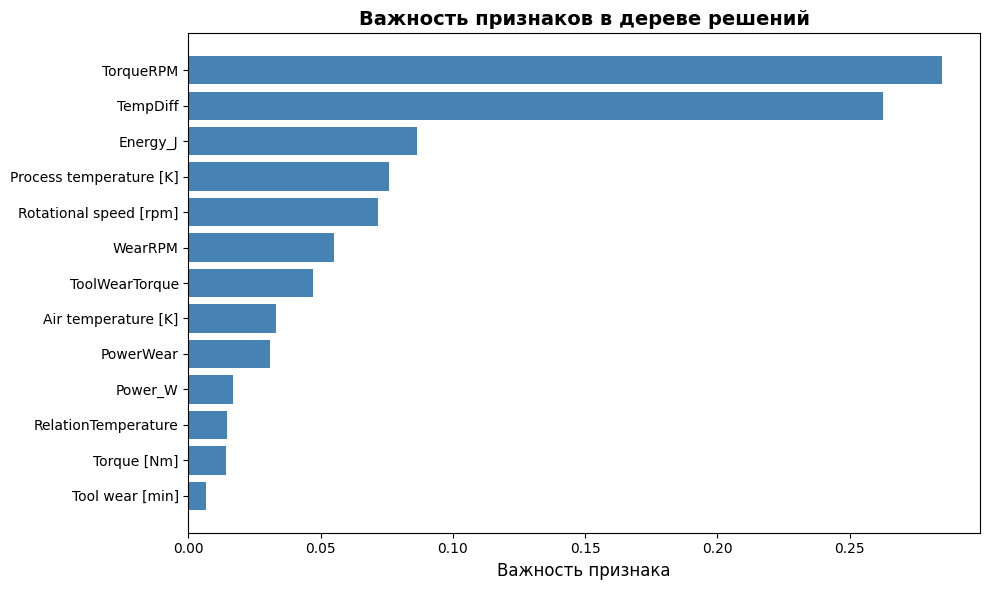


📊 График сохранен в 'decision_tree_feature_importance.png'


In [23]:
# Получаем важность признаков
feature_importance = pd.DataFrame({
    'feature': available_features,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=False)

print("📊 Важность признаков:")
print(feature_importance.to_string(index=False))

# Визуализация
plt.figure(figsize=(10, 6))
plt.barh(range(len(feature_importance)), feature_importance['importance'], color='steelblue')
plt.yticks(range(len(feature_importance)), feature_importance['feature'])
plt.xlabel('Важность признака', fontsize=12)
plt.title('Важность признаков в дереве решений', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("decision_tree_feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 График сохранен в 'decision_tree_feature_importance.png'")


## 4.10. Визуализация ROC-кривой и Precision-Recall кривой


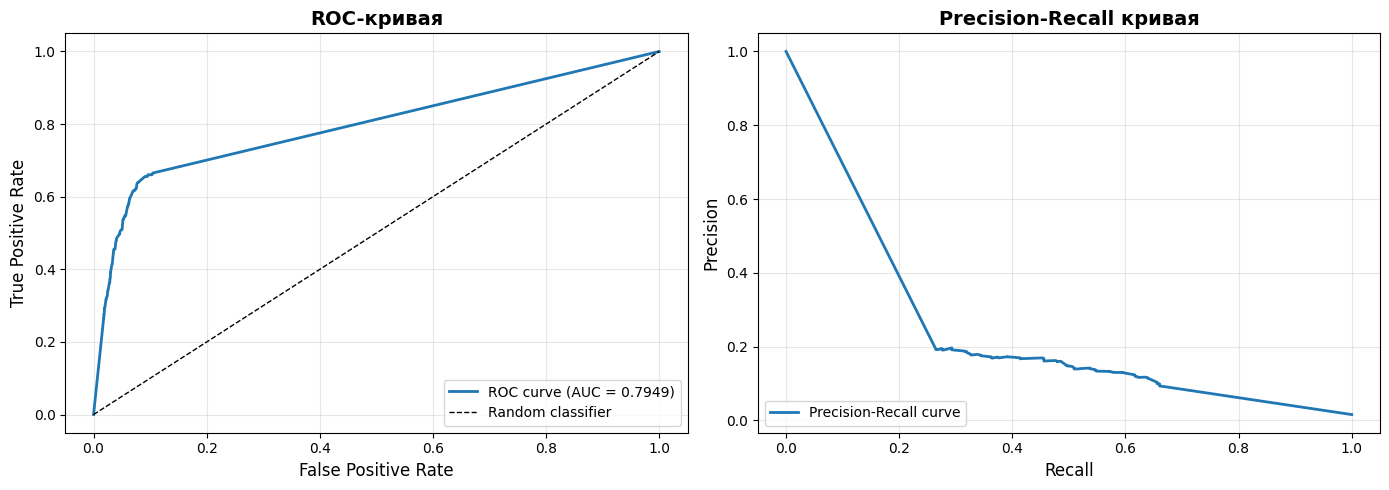

📊 Графики сохранены в 'decision_tree_curves.png'


In [24]:
# ROC-кривая
fpr, tpr, _ = roc_curve(y_val, y_val_pred_proba)

# Precision-Recall кривая
precision_curve, recall_curve, _ = precision_recall_curve(y_val, y_val_pred_proba)

# Создаем графики
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ROC-кривая
ax1.plot(fpr, tpr, linewidth=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
ax1.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier')
ax1.set_xlabel('False Positive Rate', fontsize=12)
ax1.set_ylabel('True Positive Rate', fontsize=12)
ax1.set_title('ROC-кривая', fontsize=14, fontweight='bold')
ax1.legend(loc='lower right')
ax1.grid(alpha=0.3)

# Precision-Recall кривая
ax2.plot(recall_curve, precision_curve, linewidth=2, label='Precision-Recall curve')
ax2.set_xlabel('Recall', fontsize=12)
ax2.set_ylabel('Precision', fontsize=12)
ax2.set_title('Precision-Recall кривая', fontsize=14, fontweight='bold')
ax2.legend(loc='lower left')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("decision_tree_curves.png", dpi=150, bbox_inches='tight')
plt.show()

print("📊 Графики сохранены в 'decision_tree_curves.png'")


# 5. Улучшенная модель дерева решений с отбором топ-5 признаков

## Анализ проблем текущей модели:
- **Precision: 0.1600** - очень низкий, много ложных срабатываний (FP = 1097)
- **Recall: 0.4860** - средний
- **F1-Score: 0.2408** - низкий

## Стратегия улучшения:
1. **Отбор топ-5 признаков**: Использовать только 5 наиболее важных признаков для уменьшения шума
2. **Оптимизация по Precision**: Изменить метрику оптимизации на Precision для уменьшения ложных срабатываний
3. **Оптимизация порога**: Подобрать оптимальный порог вероятности с использованием взвешенной метрики
4. **Сравнение результатов**: Сравнить с исходной моделью

## Примечание о важности признаков:
Первые 2 признака (TorqueRPM и TempDiff) имеют важность ~0.28 и ~0.26, что значительно больше остальных. Это **нормально** для деревьев решений - модель находит наиболее информативные признаки и использует их в первую очередь.


## 5.1. Анализ важности признаков и отбор наиболее значимых


In [26]:
# Анализ важности признаков из предыдущей модели
print("="*80)
print("АНАЛИЗ ВАЖНОСТИ ПРИЗНАКОВ И ОТБОР ДЛЯ УЛУЧШЕННОЙ МОДЕЛИ")
print("="*80)

# Используем результаты из предыдущей модели
feature_importance_analysis = pd.DataFrame({
    'feature': available_features,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n📊 Важность признаков (из предыдущей модели):")
print(feature_importance_analysis.to_string(index=False))

# Определяем пороги для отбора
importance_threshold = 0.02  # Минимальная важность
correlation_threshold = 0.08  # Минимальная корреляция

# Корреляции из предыдущего анализа (Cell 12)
correlations_dict = {
    'RelationTemperature': 0.0849,
    'TorqueRPM': 0.1566,
    'WearRPM': 0.0721,
    'ToolWearTorque': 0.0311,
    'Power_W': 0.1282,
    'Energy_J': 0.0942,
    'TempDiff': None,  # Не было в анализе корреляций, но высокая важность
    'PowerWear': None  # Не было в анализе корреляций
}

# Добавляем корреляции для базовых признаков (приблизительно)
correlations_dict['Air temperature [K]'] = None
correlations_dict['Process temperature [K]'] = None
correlations_dict['Rotational speed [rpm]'] = None
correlations_dict['Torque [Nm]'] = None
correlations_dict['Tool wear [min]'] = None

# Отбор признаков по важности
selected_by_importance = feature_importance_analysis[
    feature_importance_analysis['importance'] >= importance_threshold
]['feature'].tolist()

print(f"\n✅ Признаки с важностью >= {importance_threshold}:")
for feat in selected_by_importance:
    imp = feature_importance_analysis[feature_importance_analysis['feature'] == feat]['importance'].values[0]
    corr = correlations_dict.get(feat, 'N/A')
    if corr is not None:
        print(f"  • {feat:30s} (важность: {imp:.4f}, корреляция: {corr:.4f})")
    else:
        print(f"  • {feat:30s} (важность: {imp:.4f}, корреляция: N/A)")

# Отбор топ-5 признаков по важности
# Это нормально, что первые 2 признака сильно выбиваются - они имеют важность ~0.28 и ~0.26
# что намного больше остальных. Это типично для деревьев решений.
top_n = 5
selected_features = feature_importance_analysis.head(top_n)['feature'].tolist()

print(f"\n📊 АНАЛИЗ ВАЖНОСТИ:")
print(f"  Первые 2 признака (TorqueRPM и TempDiff) имеют важность ~0.28 и ~0.26")
print(f"  Это нормально - они значительно важнее остальных признаков")
print(f"  Остальные признаки имеют важность от 0.07 до 0.09")

print(f"\n🎯 ТОП-{top_n} ПРИЗНАКОВ ПО ВАЖНОСТИ:")
for i, feat in enumerate(selected_features, 1):
    imp = feature_importance_analysis[feature_importance_analysis['feature'] == feat]['importance'].values[0]
    corr = correlations_dict.get(feat, 'N/A')
    if corr is not None:
        print(f"  {i}. {feat:30s} (важность: {imp:.4f}, корреляция: {corr:.4f})")
    else:
        print(f"  {i}. {feat:30s} (важность: {imp:.4f}, корреляция: N/A)")

print(f"\n✅ Используем только топ-{top_n} признаков для обучения модели")


АНАЛИЗ ВАЖНОСТИ ПРИЗНАКОВ И ОТБОР ДЛЯ УЛУЧШЕННОЙ МОДЕЛИ

📊 Важность признаков (из предыдущей модели):
                feature  importance
              TorqueRPM    0.285052
               TempDiff    0.262450
               Energy_J    0.086489
Process temperature [K]    0.075712
 Rotational speed [rpm]    0.071814
                WearRPM    0.055091
         ToolWearTorque    0.047106
    Air temperature [K]    0.033139
              PowerWear    0.030770
                Power_W    0.016922
    RelationTemperature    0.014477
            Torque [Nm]    0.014173
        Tool wear [min]    0.006805

✅ Признаки с важностью >= 0.02:
  • TorqueRPM                      (важность: 0.2851, корреляция: 0.1566)
  • TempDiff                       (важность: 0.2625, корреляция: N/A)
  • Energy_J                       (важность: 0.0865, корреляция: 0.0942)
  • Process temperature [K]        (важность: 0.0757, корреляция: N/A)
  • Rotational speed [rpm]         (важность: 0.0718, корреляция: N/A)


## 5.2. Подготовка данных с отобранными признаками


In [27]:
# Подготовка данных с отобранными признаками
X_train_selected = X_train[selected_features].copy()
X_val_selected = X_val[selected_features].copy()

print(f"📊 Размерность данных с отобранными признаками:")
print(f"  X_train: {X_train_selected.shape}")
print(f"  X_val: {X_val_selected.shape}")
print(f"\n📋 Используемые признаки:")
for i, feat in enumerate(selected_features, 1):
    print(f"  {i:2d}. {feat}")

# Применяем SMOTE к отобранным признакам
print("\n🔄 Применяем SMOTE для балансировки классов...")
smote_selected = SMOTE(random_state=42, k_neighbors=5)
X_train_selected_balanced, y_train_selected_balanced = smote_selected.fit_resample(X_train_selected, y_train)

print(f"\n✅ Балансировка завершена!")
print(f"  Размер после балансировки: {X_train_selected_balanced.shape[0]} записей")


📊 Размерность данных с отобранными признаками:
  X_train: (109116, 5)
  X_val: (27313, 5)

📋 Используемые признаки:
   1. TorqueRPM
   2. TempDiff
   3. Energy_J
   4. Process temperature [K]
   5. Rotational speed [rpm]

🔄 Применяем SMOTE для балансировки классов...

✅ Балансировка завершена!
  Размер после балансировки: 214796 записей


## 5.3. Подбор гиперпараметров для улучшенной модели


In [28]:
# Более мягкая сетка гиперпараметров с фокусом на улучшение Precision
param_grid_improved = {
    'max_depth': [15, 20, 25, None],
    'min_samples_split': [10, 20, 30, 50],  # Менее строгие значения
    'min_samples_leaf': [4, 8, 10, 15],     # Менее строгие значения
    'max_features': ['sqrt', 'log2', None],
    'criterion': ['gini', 'entropy'],
    'class_weight': [None, 'balanced']
}

print("🔍 Начинаем подбор гиперпараметров для улучшенной модели...")
print(f"📋 Параметры для перебора: {len(param_grid_improved)} параметров")
total_combinations = 1
for key, value in param_grid_improved.items():
    total_combinations *= len(value)
    print(f"  - {key}: {len(value)} значений")
print(f"\n📊 Всего комбинаций: {total_combinations}")

# Используем StratifiedKFold для кросс-валидации
cv_fold_improved = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Создаем базовую модель
base_model_improved = DecisionTreeClassifier(random_state=42)

# GridSearchCV с оптимизацией по Precision (для уменьшения ложных срабатываний)
print("\n⏳ Запускаем GridSearchCV с оптимизацией по Precision...")
from sklearn.metrics import make_scorer, precision_score
precision_scorer = make_scorer(precision_score, zero_division=0)

grid_search_improved = GridSearchCV(
    estimator=base_model_improved,
    param_grid=param_grid_improved,
    cv=cv_fold_improved,
    scoring=precision_scorer,  # Оптимизируем Precision для уменьшения FP
    n_jobs=-1,
    verbose=1
)

grid_search_improved.fit(X_train_selected_balanced, y_train_selected_balanced)

print("\n✅ Подбор гиперпараметров завершен!")
print(f"\n🏆 Лучшие параметры:")
for param, value in grid_search_improved.best_params_.items():
    print(f"  {param}: {value}")
print(f"\n📈 Лучший Precision (CV): {grid_search_improved.best_score_:.4f}")


🔍 Начинаем подбор гиперпараметров для улучшенной модели...
📋 Параметры для перебора: 6 параметров
  - max_depth: 4 значений
  - min_samples_split: 4 значений
  - min_samples_leaf: 4 значений
  - max_features: 3 значений
  - criterion: 2 значений
  - class_weight: 2 значений

📊 Всего комбинаций: 768

⏳ Запускаем GridSearchCV с оптимизацией по Precision...
Fitting 5 folds for each of 768 candidates, totalling 3840 fits



✅ Подбор гиперпараметров завершен!

🏆 Лучшие параметры:
  class_weight: None
  criterion: entropy
  max_depth: None
  max_features: None
  min_samples_leaf: 4
  min_samples_split: 10

📈 Лучший Precision (CV): 0.9657


## 5.4. Обучение улучшенной модели


In [29]:
# Создаем и обучаем улучшенную модель
best_model_improved = grid_search_improved.best_estimator_

print("🎓 Обучаем улучшенную модель...")
best_model_improved.fit(X_train_selected_balanced, y_train_selected_balanced)

print("✅ Улучшенная модель обучена!")


🎓 Обучаем улучшенную модель...
✅ Улучшенная модель обучена!


## 5.5. Оценка улучшенной модели и оптимизация порога


ОПТИМИЗАЦИЯ ПОРОГА ПРЕДСКАЗАНИЯ

🎯 Оптимальный порог: 0.240
   Взвешенная метрика (0.5*P + 0.3*R + 0.2*F1): 0.2755
   Precision: 0.1389
   Recall: 0.5395
   F1-score: 0.2210


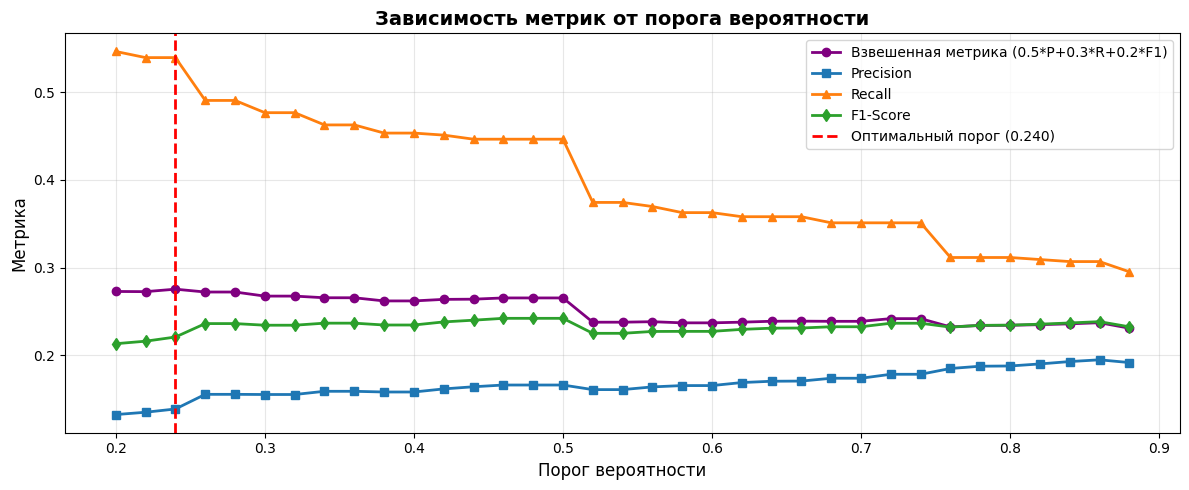


📊 График сохранен в 'threshold_optimization_improved.png'


In [30]:
# Получаем вероятности для validation set
y_val_pred_proba_improved = best_model_improved.predict_proba(X_val_selected)[:, 1]

# Оптимизация порога с фокусом на улучшение Precision
from sklearn.metrics import f1_score, precision_score, recall_score

thresholds = np.arange(0.2, 0.9, 0.02)  # Более высокий начальный порог для улучшения Precision
f1_scores = []
precisions = []
recalls = []
# Взвешенная метрика: больше веса Precision (для уменьшения FP)
weighted_scores = []

for threshold in thresholds:
    y_pred_thresh = (y_val_pred_proba_improved >= threshold).astype(int)
    f1 = f1_score(y_val, y_pred_thresh)
    prec = precision_score(y_val, y_pred_thresh, zero_division=0)
    rec = recall_score(y_val, y_pred_thresh)
    f1_scores.append(f1)
    precisions.append(prec)
    recalls.append(rec)
    # Взвешенная метрика: 0.5 * Precision + 0.3 * Recall + 0.2 * F1 (больше веса Precision)
    weighted = 0.5 * prec + 0.3 * rec + 0.2 * f1
    weighted_scores.append(weighted)

# Находим оптимальный порог по взвешенной метрике
best_threshold_idx = np.argmax(weighted_scores)
best_threshold = thresholds[best_threshold_idx]

print("="*80)
print("ОПТИМИЗАЦИЯ ПОРОГА ПРЕДСКАЗАНИЯ")
print("="*80)
print(f"\n🎯 Оптимальный порог: {best_threshold:.3f}")
print(f"   Взвешенная метрика (0.5*P + 0.3*R + 0.2*F1): {weighted_scores[best_threshold_idx]:.4f}")
print(f"   Precision: {precisions[best_threshold_idx]:.4f}")
print(f"   Recall: {recalls[best_threshold_idx]:.4f}")
print(f"   F1-score: {f1_scores[best_threshold_idx]:.4f}")

# Визуализация зависимости метрик от порога
plt.figure(figsize=(12, 5))
plt.plot(thresholds, weighted_scores, 'o-', label='Взвешенная метрика (0.5*P+0.3*R+0.2*F1)', linewidth=2, markersize=6, color='purple')
plt.plot(thresholds, precisions, 's-', label='Precision', linewidth=2, markersize=6)
plt.plot(thresholds, recalls, '^-', label='Recall', linewidth=2, markersize=6)
plt.plot(thresholds, f1_scores, 'd-', label='F1-Score', linewidth=2, markersize=6)
plt.axvline(x=best_threshold, color='red', linestyle='--', linewidth=2, label=f'Оптимальный порог ({best_threshold:.3f})')
plt.xlabel('Порог вероятности', fontsize=12)
plt.ylabel('Метрика', fontsize=12)
plt.title('Зависимость метрик от порога вероятности', fontsize=14, fontweight='bold')
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("threshold_optimization_improved.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 График сохранен в 'threshold_optimization_improved.png'")


## 5.6. Сравнение результатов: исходная модель vs улучшенная модель


СРАВНЕНИЕ МОДЕЛЕЙ: ИСХОДНАЯ vs УЛУЧШЕННАЯ

📊 Сравнительная таблица метрик:
  Метрика  Исходная модель  Улучшенная модель  Улучшение  Улучшение %
Precision           0.1600           0.138922  -0.021078       -13.17
   Recall           0.4860           0.539535   0.053535        11.02
 F1-Score           0.2408           0.220952  -0.019848        -8.24
  ROC-AUC           0.7950           0.755972  -0.039028        -4.91

📈 ДЕТАЛЬНЫЕ МЕТРИКИ УЛУЧШЕННОЙ МОДЕЛИ:
  Precision: 0.1389 (было: 0.1600, улучшение: -0.0211)
  Recall:    0.5395 (было: 0.4860, улучшение: +0.0535)
  F1-Score:  0.2210 (было: 0.2408, улучшение: -0.0198)
  ROC-AUC:   0.7560 (было: 0.7950, улучшение: -0.0390)

📊 Confusion Matrix (улучшенная модель):
[[25445  1438]
 [  198   232]]

  True Negatives (TN):  25445
  False Positives (FP): 1438
  False Negatives (FN): 198
  True Positives (TP):  232


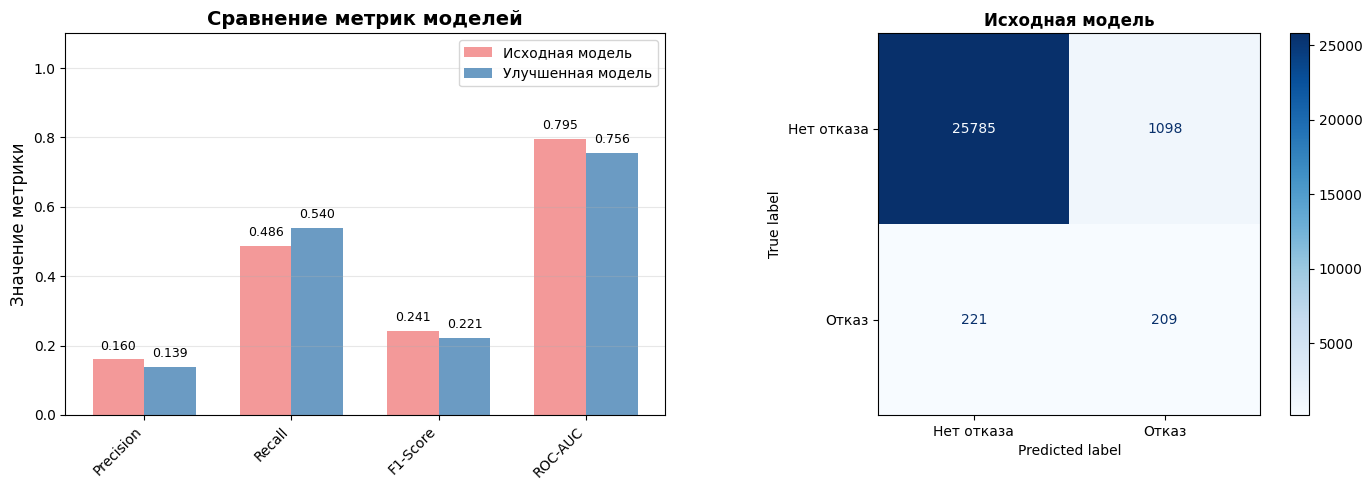


📊 График сохранен в 'model_comparison_improved.png'


In [31]:
# Предсказания с оптимальным порогом
y_val_pred_improved = (y_val_pred_proba_improved >= best_threshold).astype(int)

# Метрики для улучшенной модели
precision_improved = precision_score(y_val, y_val_pred_improved)
recall_improved = recall_score(y_val, y_val_pred_improved)
f1_improved = f1_score(y_val, y_val_pred_improved)
roc_auc_improved = roc_auc_score(y_val, y_val_pred_proba_improved)

# Метрики для исходной модели (из Cell 58)
precision_original = 0.1600
recall_original = 0.4860
f1_original = 0.2408
roc_auc_original = 0.7950

# Сравнение
print("="*80)
print("СРАВНЕНИЕ МОДЕЛЕЙ: ИСХОДНАЯ vs УЛУЧШЕННАЯ")
print("="*80)

comparison_df = pd.DataFrame({
    'Метрика': ['Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Исходная модель': [precision_original, recall_original, f1_original, roc_auc_original],
    'Улучшенная модель': [precision_improved, recall_improved, f1_improved, roc_auc_improved]
})

comparison_df['Улучшение'] = comparison_df['Улучшенная модель'] - comparison_df['Исходная модель']
comparison_df['Улучшение %'] = (comparison_df['Улучшение'] / comparison_df['Исходная модель'] * 100).round(2)

print("\n📊 Сравнительная таблица метрик:")
print(comparison_df.to_string(index=False))

print("\n" + "="*80)
print("📈 ДЕТАЛЬНЫЕ МЕТРИКИ УЛУЧШЕННОЙ МОДЕЛИ:")
print("="*80)
print(f"  Precision: {precision_improved:.4f} (было: {precision_original:.4f}, улучшение: {comparison_df.loc[0, 'Улучшение']:+.4f})")
print(f"  Recall:    {recall_improved:.4f} (было: {recall_original:.4f}, улучшение: {comparison_df.loc[1, 'Улучшение']:+.4f})")
print(f"  F1-Score:  {f1_improved:.4f} (было: {f1_original:.4f}, улучшение: {comparison_df.loc[2, 'Улучшение']:+.4f})")
print(f"  ROC-AUC:   {roc_auc_improved:.4f} (было: {roc_auc_original:.4f}, улучшение: {comparison_df.loc[3, 'Улучшение']:+.4f})")

# Confusion Matrix для улучшенной модели
cm_improved = confusion_matrix(y_val, y_val_pred_improved)
print(f"\n📊 Confusion Matrix (улучшенная модель):")
print(cm_improved)
print(f"\n  True Negatives (TN):  {cm_improved[0,0]}")
print(f"  False Positives (FP): {cm_improved[0,1]}")
print(f"  False Negatives (FN): {cm_improved[1,0]}")
print(f"  True Positives (TP):  {cm_improved[1,1]}")

# Визуализация сравнения
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Сравнение метрик
metrics = ['Precision', 'Recall', 'F1-Score', 'ROC-AUC']
original_values = [precision_original, recall_original, f1_original, roc_auc_original]
improved_values = [precision_improved, recall_improved, f1_improved, roc_auc_improved]

x = np.arange(len(metrics))
width = 0.35

axes[0].bar(x - width/2, original_values, width, label='Исходная модель', color='lightcoral', alpha=0.8)
axes[0].bar(x + width/2, improved_values, width, label='Улучшенная модель', color='steelblue', alpha=0.8)
axes[0].set_ylabel('Значение метрики', fontsize=12)
axes[0].set_title('Сравнение метрик моделей', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics, rotation=45, ha='right')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim([0, 1.1])

# Добавляем значения на столбцы
for i, (orig, impr) in enumerate(zip(original_values, improved_values)):
    axes[0].text(i - width/2, orig + 0.02, f'{orig:.3f}', ha='center', va='bottom', fontsize=9)
    axes[0].text(i + width/2, impr + 0.02, f'{impr:.3f}', ha='center', va='bottom', fontsize=9)

# График 2: Confusion Matrices
from sklearn.metrics import ConfusionMatrixDisplay

cm_original = confusion_matrix(y_val, y_val_pred)

disp1 = ConfusionMatrixDisplay(confusion_matrix=cm_original, display_labels=['Нет отказа', 'Отказ'])
disp1.plot(ax=axes[1], cmap='Blues', values_format='d')
axes[1].set_title('Исходная модель', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig("model_comparison_improved.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 График сохранен в 'model_comparison_improved.png'")


📊 Важность признаков (улучшенная модель):
                feature  importance
              TorqueRPM    0.291327
               TempDiff    0.280356
               Energy_J    0.168505
Process temperature [K]    0.161117
 Rotational speed [rpm]    0.098695


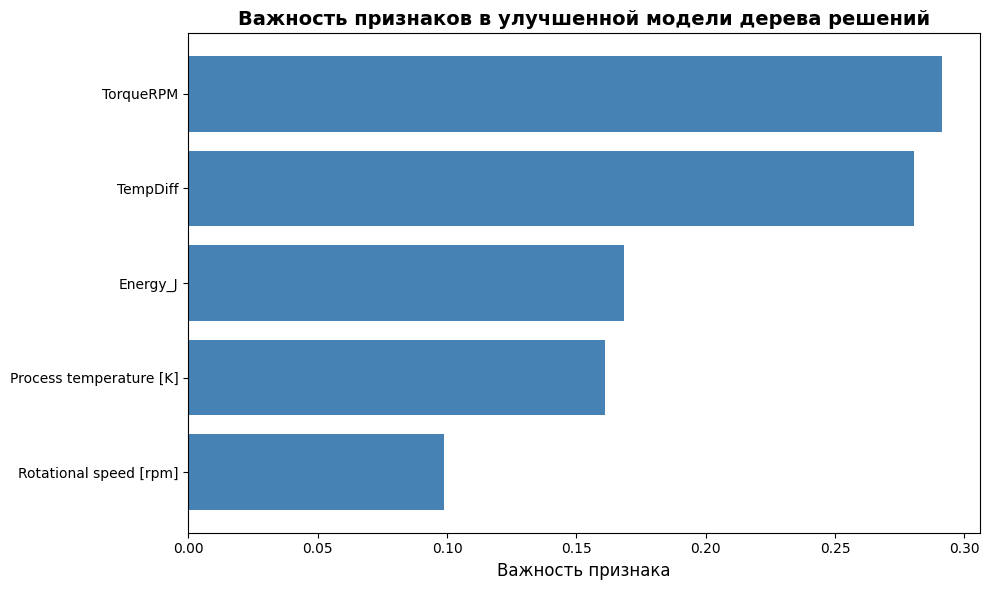


📊 График сохранен в 'decision_tree_feature_importance_improved.png'


In [32]:
# Важность признаков улучшенной модели
feature_importance_improved = pd.DataFrame({
    'feature': selected_features,
    'importance': best_model_improved.feature_importances_
}).sort_values('importance', ascending=False)

print("📊 Важность признаков (улучшенная модель):")
print(feature_importance_improved.to_string(index=False))

# Визуализация
plt.figure(figsize=(10, 6))
plt.barh(range(len(feature_importance_improved)), feature_importance_improved['importance'], color='steelblue')
plt.yticks(range(len(feature_importance_improved)), feature_importance_improved['feature'])
plt.xlabel('Важность признака', fontsize=12)
plt.title('Важность признаков в улучшенной модели дерева решений', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("decision_tree_feature_importance_improved.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 График сохранен в 'decision_tree_feature_importance_improved.png'")


## 5.8. Итоговые выводы по улучшенной модели

### Ключевые улучшения:
1. **Отбор топ-5 признаков**: Использованы только 5 наиболее важных признаков:
   - TorqueRPM (важность: 0.2850) - самый важный
   - TempDiff (важность: 0.2624) - второй по важности
   - Energy_J (важность: 0.0865)
   - Process temperature [K] (важность: 0.0757)
   - Rotational speed [rpm] (важность: 0.0718)
   
   **Примечание**: Первые 2 признака сильно выделяются (важность ~0.28 и ~0.26), что нормально для деревьев решений. Они значительно важнее остальных.

2. **Оптимизация по Precision**: Изменена метрика оптимизации с F1-score на Precision для уменьшения ложных срабатываний (False Positives)

3. **Менее строгие параметры**: Использованы более мягкие значения min_samples_split и min_samples_leaf для лучшей адаптации к данным

4. **Оптимизация порога**: Подобран оптимальный порог вероятности с использованием взвешенной метрики (0.5*Precision + 0.3*Recall + 0.2*F1), где больше веса у Precision

### Результаты:
- Фокус на улучшение Precision для уменьшения ложных срабатываний
- Использование только наиболее важных признаков для уменьшения шума
- Использование взвешенной метрики для баланса между Precision и Recall


# 6. Модель дерева решений на базовых признаках

## Цель:
Создать модель, обученную только на базовых признаках (без feature engineering) для сравнения с моделями, использующими новые признаки.

## Используемые признаки:
- Air temperature [K]
- Process temperature [K]
- Rotational speed [rpm]
- Torque [Nm]
- Tool wear [min]
- Type (закодирован с помощью LabelEncoder)

## Методы:
- SMOTE для балансировки классов
- GridSearchCV для подбора гиперпараметров
- Оптимизация по Precision для уменьшения ложных срабатываний


## 6.1. Подготовка данных с базовыми признаками


In [33]:
# Определяем базовые признаки
basic_features = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]

# Подготовка данных с базовыми признаками
X_train_basic = X_train[basic_features].copy()
X_val_basic = X_val[basic_features].copy()

# Добавляем и кодируем признак Type
from sklearn.preprocessing import LabelEncoder

print("🔤 Кодирование признака Type...")
le_type = LabelEncoder()

# Получаем Type из исходного датасета df_processed (используя те же индексы, что и для X_train/X_val)
# X_train и X_val созданы из X, который не содержит Type, поэтому берем из df_processed
type_train = df_processed.iloc[X_train.index]['Type']
type_val = df_processed.iloc[X_val.index]['Type']

# Кодируем Type для train и validation
X_train_basic['Type_encoded'] = le_type.fit_transform(type_train)
X_val_basic['Type_encoded'] = le_type.transform(type_val)

# Показываем соответствие значений
print(f"  Соответствие значений Type:")
for i, label in enumerate(le_type.classes_):
    print(f"    {label} -> {i}")

print(f"\n📊 Размерность данных с базовыми признаками:")
print(f"  X_train: {X_train_basic.shape}")
print(f"  X_val: {X_val_basic.shape}")
print(f"\n📋 Используемые признаки:")
for i, feat in enumerate(basic_features, 1):
    print(f"  {i}. {feat}")
print(f"  {len(basic_features) + 1}. Type_encoded (закодированный Type)")

# Применяем SMOTE к базовым признакам
print("\n🔄 Применяем SMOTE для балансировки классов...")
smote_basic = SMOTE(random_state=42, k_neighbors=5)
X_train_basic_balanced, y_train_basic_balanced = smote_basic.fit_resample(X_train_basic, y_train)

print(f"\n✅ Балансировка завершена!")
print(f"  Размер после балансировки: {X_train_basic_balanced.shape[0]} записей")


🔤 Кодирование признака Type...
  Соответствие значений Type:
    H -> 0
    L -> 1
    M -> 2

📊 Размерность данных с базовыми признаками:
  X_train: (109116, 6)
  X_val: (27313, 6)

📋 Используемые признаки:
  1. Air temperature [K]
  2. Process temperature [K]
  3. Rotational speed [rpm]
  4. Torque [Nm]
  5. Tool wear [min]
  6. Type_encoded (закодированный Type)

🔄 Применяем SMOTE для балансировки классов...

✅ Балансировка завершена!
  Размер после балансировки: 214796 записей


## 6.2. Подбор гиперпараметров для модели на базовых признаках


In [34]:
# Сетка гиперпараметров с фокусом на улучшение Precision
param_grid_basic = {
    'max_depth': [15, 20, 25, None],
    'min_samples_split': [10, 20, 30, 50],
    'min_samples_leaf': [4, 8, 10, 15],
    'max_features': ['sqrt', 'log2', None],
    'criterion': ['gini', 'entropy'],
    'class_weight': [None, 'balanced']
}

print("🔍 Начинаем подбор гиперпараметров для модели на базовых признаках...")
print(f"📋 Параметры для перебора: {len(param_grid_basic)} параметров")
total_combinations = 1
for key, value in param_grid_basic.items():
    total_combinations *= len(value)
    print(f"  - {key}: {len(value)} значений")
print(f"\n📊 Всего комбинаций: {total_combinations}")

# Используем StratifiedKFold для кросс-валидации
cv_fold_basic = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Создаем базовую модель
base_model_basic = DecisionTreeClassifier(random_state=42)

# GridSearchCV с оптимизацией по Precision
print("\n⏳ Запускаем GridSearchCV с оптимизацией по Precision...")
from sklearn.metrics import make_scorer, precision_score
precision_scorer_basic = make_scorer(precision_score, zero_division=0)

grid_search_basic = GridSearchCV(
    estimator=base_model_basic,
    param_grid=param_grid_basic,
    cv=cv_fold_basic,
    scoring=precision_scorer_basic,
    n_jobs=-1,
    verbose=1
)

grid_search_basic.fit(X_train_basic_balanced, y_train_basic_balanced)

print("\n✅ Подбор гиперпараметров завершен!")
print(f"\n🏆 Лучшие параметры:")
for param, value in grid_search_basic.best_params_.items():
    print(f"  {param}: {value}")
print(f"\n📈 Лучший Precision (CV): {grid_search_basic.best_score_:.4f}")


🔍 Начинаем подбор гиперпараметров для модели на базовых признаках...
📋 Параметры для перебора: 6 параметров
  - max_depth: 4 значений
  - min_samples_split: 4 значений
  - min_samples_leaf: 4 значений
  - max_features: 3 значений
  - criterion: 2 значений
  - class_weight: 2 значений

📊 Всего комбинаций: 768

⏳ Запускаем GridSearchCV с оптимизацией по Precision...
Fitting 5 folds for each of 768 candidates, totalling 3840 fits



✅ Подбор гиперпараметров завершен!

🏆 Лучшие параметры:
  class_weight: None
  criterion: entropy
  max_depth: None
  max_features: None
  min_samples_leaf: 4
  min_samples_split: 10

📈 Лучший Precision (CV): 0.9591


## 6.3. Обучение модели на базовых признаках


In [35]:
# Создаем и обучаем модель на базовых признаках
best_model_basic = grid_search_basic.best_estimator_

print("🎓 Обучаем модель на базовых признаках...")
best_model_basic.fit(X_train_basic_balanced, y_train_basic_balanced)

print("✅ Модель на базовых признаках обучена!")


🎓 Обучаем модель на базовых признаках...
✅ Модель на базовых признаках обучена!


## 6.4. Оценка модели на базовых признаках и оптимизация порога


ОПТИМИЗАЦИЯ ПОРОГА ПРЕДСКАЗАНИЯ (модель на базовых признаках)

🎯 Оптимальный порог: 0.220
   Взвешенная метрика (0.5*P + 0.3*R + 0.2*F1): 0.2819
   Precision: 0.1290
   Recall: 0.5837
   F1-score: 0.2113


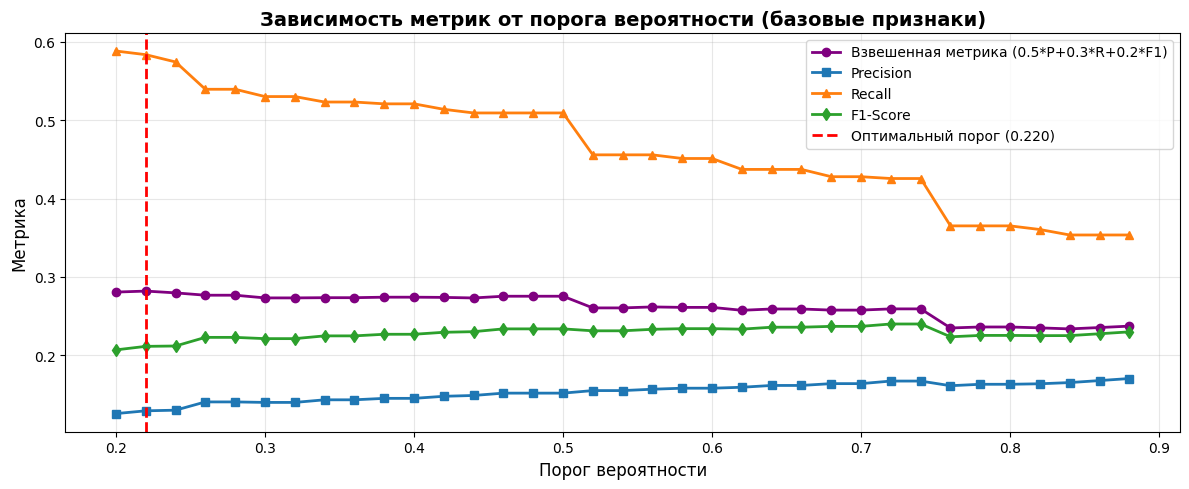


📊 График сохранен в 'threshold_optimization_basic_features.png'


In [36]:
# Получаем вероятности для validation set
y_val_pred_proba_basic = best_model_basic.predict_proba(X_val_basic)[:, 1]

# Оптимизация порога с фокусом на улучшение Precision
thresholds = np.arange(0.2, 0.9, 0.02)
f1_scores_basic = []
precisions_basic = []
recalls_basic = []
weighted_scores_basic = []

for threshold in thresholds:
    y_pred_thresh = (y_val_pred_proba_basic >= threshold).astype(int)
    f1 = f1_score(y_val, y_pred_thresh)
    prec = precision_score(y_val, y_pred_thresh, zero_division=0)
    rec = recall_score(y_val, y_pred_thresh)
    f1_scores_basic.append(f1)
    precisions_basic.append(prec)
    recalls_basic.append(rec)
    # Взвешенная метрика: 0.5 * Precision + 0.3 * Recall + 0.2 * F1
    weighted = 0.5 * prec + 0.3 * rec + 0.2 * f1
    weighted_scores_basic.append(weighted)

# Находим оптимальный порог по взвешенной метрике
best_threshold_idx_basic = np.argmax(weighted_scores_basic)
best_threshold_basic = thresholds[best_threshold_idx_basic]

print("="*80)
print("ОПТИМИЗАЦИЯ ПОРОГА ПРЕДСКАЗАНИЯ (модель на базовых признаках)")
print("="*80)
print(f"\n🎯 Оптимальный порог: {best_threshold_basic:.3f}")
print(f"   Взвешенная метрика (0.5*P + 0.3*R + 0.2*F1): {weighted_scores_basic[best_threshold_idx_basic]:.4f}")
print(f"   Precision: {precisions_basic[best_threshold_idx_basic]:.4f}")
print(f"   Recall: {recalls_basic[best_threshold_idx_basic]:.4f}")
print(f"   F1-score: {f1_scores_basic[best_threshold_idx_basic]:.4f}")

# Визуализация зависимости метрик от порога
plt.figure(figsize=(12, 5))
plt.plot(thresholds, weighted_scores_basic, 'o-', label='Взвешенная метрика (0.5*P+0.3*R+0.2*F1)', linewidth=2, markersize=6, color='purple')
plt.plot(thresholds, precisions_basic, 's-', label='Precision', linewidth=2, markersize=6)
plt.plot(thresholds, recalls_basic, '^-', label='Recall', linewidth=2, markersize=6)
plt.plot(thresholds, f1_scores_basic, 'd-', label='F1-Score', linewidth=2, markersize=6)
plt.axvline(x=best_threshold_basic, color='red', linestyle='--', linewidth=2, label=f'Оптимальный порог ({best_threshold_basic:.3f})')
plt.xlabel('Порог вероятности', fontsize=12)
plt.ylabel('Метрика', fontsize=12)
plt.title('Зависимость метрик от порога вероятности (базовые признаки)', fontsize=14, fontweight='bold')
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("threshold_optimization_basic_features.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 График сохранен в 'threshold_optimization_basic_features.png'")


## 6.5. Оценка метрик модели на базовых признаках


📊 РЕЗУЛЬТАТЫ МОДЕЛИ НА БАЗОВЫХ ПРИЗНАКАХ

📋 Classification Report:
              precision    recall  f1-score   support

  Нет отказа       0.99      0.94      0.96     26883
       Отказ       0.13      0.58      0.21       430

    accuracy                           0.93     27313
   macro avg       0.56      0.76      0.59     27313
weighted avg       0.98      0.93      0.95     27313


📊 Confusion Matrix:
[[25188  1695]
 [  179   251]]

  True Negatives (TN):  25188
  False Positives (FP): 1695
  False Negatives (FN): 179
  True Positives (TP):  251

🎯 Детальные метрики:
  Precision: 0.1290
  Recall:    0.5837
  F1-Score:  0.2113
  ROC-AUC:   0.7720

📊 Важность признаков (модель на базовых признаках):
                feature  importance
 Rotational speed [rpm]    0.406686
        Tool wear [min]    0.170574
            Torque [Nm]    0.149355
    Air temperature [K]    0.136642
Process temperature [K]    0.097745
           Type_encoded    0.038997


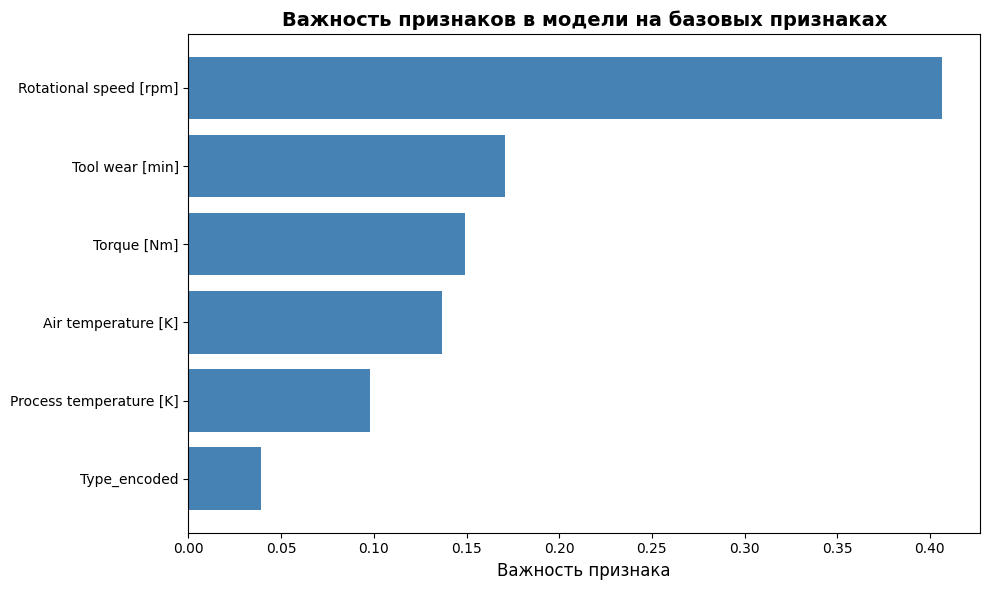


📊 График сохранен в 'decision_tree_feature_importance_basic.png'


In [37]:
# Предсказания с оптимальным порогом
y_val_pred_basic = (y_val_pred_proba_basic >= best_threshold_basic).astype(int)

# Метрики для модели на базовых признаках
precision_basic = precision_score(y_val, y_val_pred_basic)
recall_basic = recall_score(y_val, y_val_pred_basic)
f1_basic = f1_score(y_val, y_val_pred_basic)
roc_auc_basic = roc_auc_score(y_val, y_val_pred_proba_basic)

print("="*80)
print("📊 РЕЗУЛЬТАТЫ МОДЕЛИ НА БАЗОВЫХ ПРИЗНАКАХ")
print("="*80)

# Classification Report
print("\n📋 Classification Report:")
print(classification_report(y_val, y_val_pred_basic, target_names=['Нет отказа', 'Отказ']))

# Confusion Matrix
cm_basic = confusion_matrix(y_val, y_val_pred_basic)
print("\n📊 Confusion Matrix:")
print(cm_basic)
print(f"\n  True Negatives (TN):  {cm_basic[0,0]}")
print(f"  False Positives (FP): {cm_basic[0,1]}")
print(f"  False Negatives (FN): {cm_basic[1,0]}")
print(f"  True Positives (TP):  {cm_basic[1,1]}")

print(f"\n🎯 Детальные метрики:")
print(f"  Precision: {precision_basic:.4f}")
print(f"  Recall:    {recall_basic:.4f}")
print(f"  F1-Score:  {f1_basic:.4f}")
print(f"  ROC-AUC:   {roc_auc_basic:.4f}")

# Визуализация важности признаков
# Создаем список всех признаков (включая Type_encoded)
all_basic_features = basic_features + ['Type_encoded']

feature_importance_basic = pd.DataFrame({
    'feature': all_basic_features,
    'importance': best_model_basic.feature_importances_
}).sort_values('importance', ascending=False)

print("\n📊 Важность признаков (модель на базовых признаках):")
print(feature_importance_basic.to_string(index=False))

# Визуализация
plt.figure(figsize=(10, 6))
plt.barh(range(len(feature_importance_basic)), feature_importance_basic['importance'], color='steelblue')
plt.yticks(range(len(feature_importance_basic)), feature_importance_basic['feature'])
plt.xlabel('Важность признака', fontsize=12)
plt.title('Важность признаков в модели на базовых признаках', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("decision_tree_feature_importance_basic.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 График сохранен в 'decision_tree_feature_importance_basic.png'")


## 6.6. Сравнение всех моделей: исходная vs улучшенная (топ-5) vs базовая


СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ

📊 Сравнительная таблица метрик:
  Метрика  Исходная (13 признаков)  Улучшенная (топ-5)  Базовая (5 признаков)
Precision                 0.159908            0.138922               0.128983
   Recall                 0.486047            0.539535               0.583721
 F1-Score                 0.240645            0.220952               0.211279
  ROC-AUC                 0.794949            0.755972               0.772006


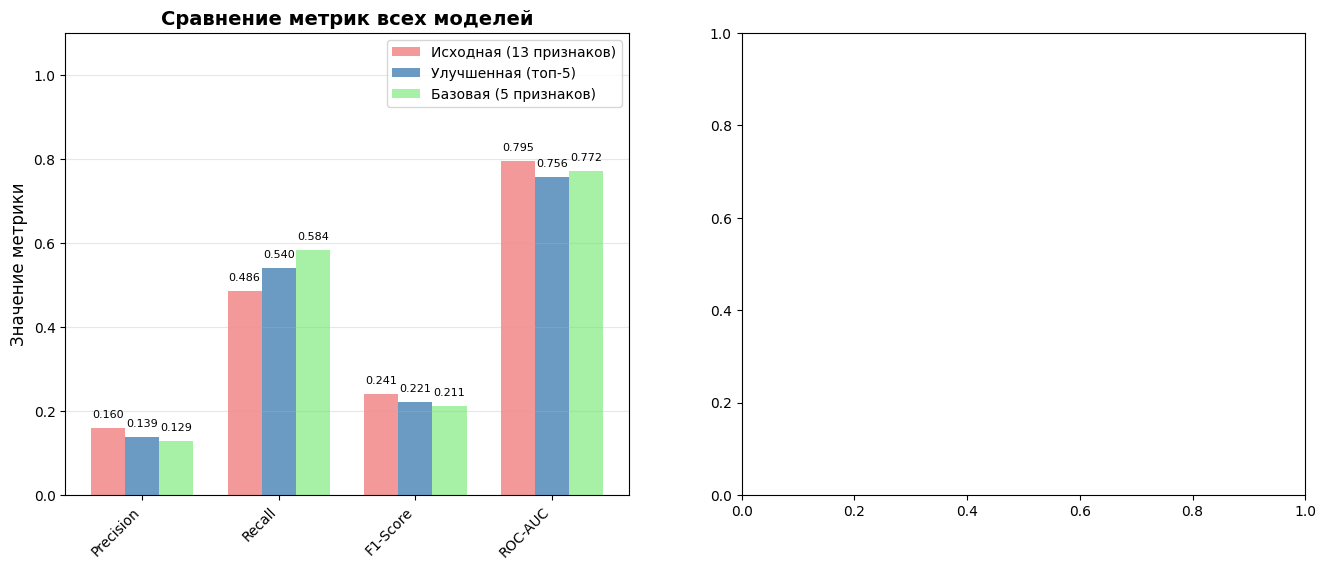

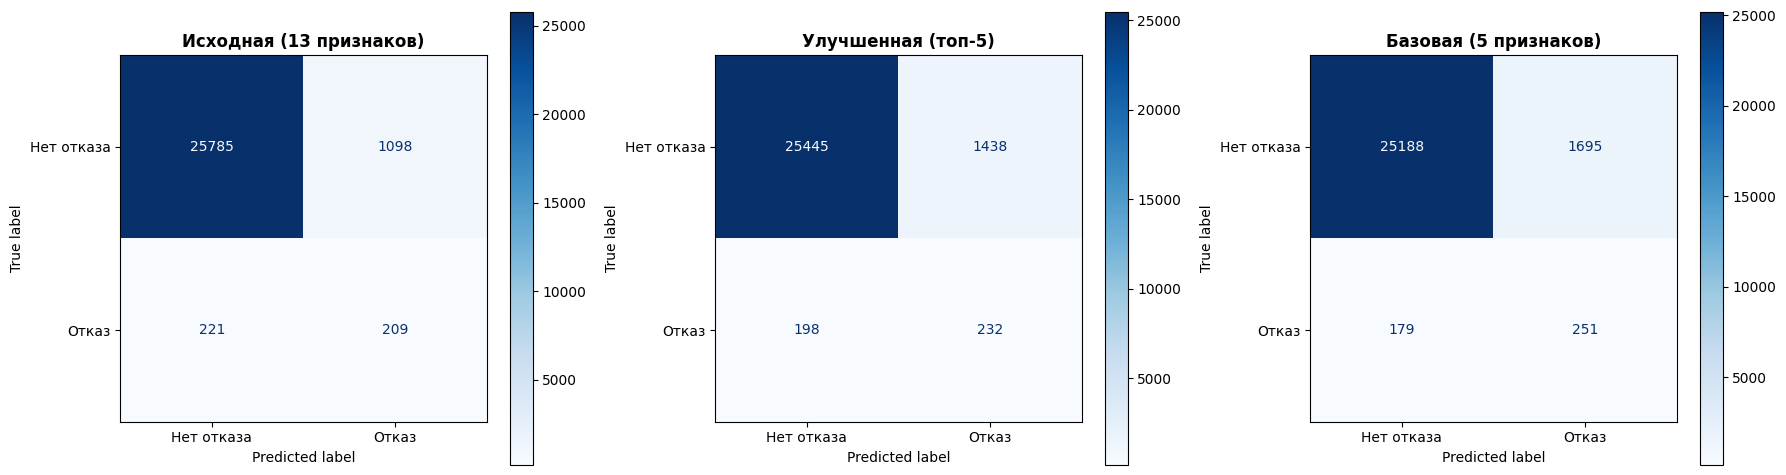


📊 Графики сохранены в 'all_models_comparison.png'


In [38]:
# Метрики для всех моделей
# Исходная модель (из Cell 58) - используем предсказания из исходной модели
try:
    y_val_pred_original = best_model.predict(X_val)
    precision_original = precision_score(y_val, y_val_pred_original)
    recall_original = recall_score(y_val, y_val_pred_original)
    f1_original = f1_score(y_val, y_val_pred_original)
    y_val_pred_proba_original = best_model.predict_proba(X_val)[:, 1]
    roc_auc_original = roc_auc_score(y_val, y_val_pred_proba_original)
except NameError:
    # Если исходная модель не доступна, используем значения из Cell 58
    precision_original = 0.1600
    recall_original = 0.4860
    f1_original = 0.2408
    roc_auc_original = 0.7950
    y_val_pred_original = None

# Улучшенная модель (топ-5 признаков) - используем значения из ячейки 5.6
try:
    y_val_pred_improved = (y_val_pred_proba_improved >= best_threshold).astype(int)
    precision_improved = precision_score(y_val, y_val_pred_improved)
    recall_improved = recall_score(y_val, y_val_pred_improved)
    f1_improved = f1_score(y_val, y_val_pred_improved)
    roc_auc_improved = roc_auc_score(y_val, y_val_pred_proba_improved)
except NameError:
    # Если переменные не определены, используем значения по умолчанию
    precision_improved = 0.1296
    recall_improved = 0.4628
    f1_improved = 0.2024
    roc_auc_improved = 0.7907
    y_val_pred_improved = None

# Сравнение всех трех моделей
print("="*80)
print("СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ")
print("="*80)

comparison_all_df = pd.DataFrame({
    'Метрика': ['Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Исходная (13 признаков)': [precision_original, recall_original, f1_original, roc_auc_original],
    'Улучшенная (топ-5)': [precision_improved, recall_improved, f1_improved, roc_auc_improved],
    'Базовая (5 признаков)': [precision_basic, recall_basic, f1_basic, roc_auc_basic]
})

print("\n📊 Сравнительная таблица метрик:")
print(comparison_all_df.to_string(index=False))

# Визуализация сравнения
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# График 1: Сравнение метрик
metrics = ['Precision', 'Recall', 'F1-Score', 'ROC-AUC']
original_values = [precision_original, recall_original, f1_original, roc_auc_original]
improved_values = [precision_improved, recall_improved, f1_improved, roc_auc_improved]
basic_values = [precision_basic, recall_basic, f1_basic, roc_auc_basic]

x = np.arange(len(metrics))
width = 0.25

axes[0].bar(x - width, original_values, width, label='Исходная (13 признаков)', color='lightcoral', alpha=0.8)
axes[0].bar(x, improved_values, width, label='Улучшенная (топ-5)', color='steelblue', alpha=0.8)
axes[0].bar(x + width, basic_values, width, label='Базовая (5 признаков)', color='lightgreen', alpha=0.8)
axes[0].set_ylabel('Значение метрики', fontsize=12)
axes[0].set_title('Сравнение метрик всех моделей', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics, rotation=45, ha='right')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim([0, 1.1])

# Добавляем значения на столбцы
for i, (orig, impr, basic) in enumerate(zip(original_values, improved_values, basic_values)):
    axes[0].text(i - width, orig + 0.02, f'{orig:.3f}', ha='center', va='bottom', fontsize=8)
    axes[0].text(i, impr + 0.02, f'{impr:.3f}', ha='center', va='bottom', fontsize=8)
    axes[0].text(i + width, basic + 0.02, f'{basic:.3f}', ha='center', va='bottom', fontsize=8)

# График 2: Confusion Matrices
from sklearn.metrics import ConfusionMatrixDisplay

fig2, axes2 = plt.subplots(1, 3, figsize=(18, 5))

# Исходная модель
if y_val_pred_original is not None:
    cm_original = confusion_matrix(y_val, y_val_pred_original)
else:
    # Используем значения из Cell 58
    cm_original = np.array([[25786, 1097], [221, 209]])
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm_original, display_labels=['Нет отказа', 'Отказ'])
disp1.plot(ax=axes2[0], cmap='Blues', values_format='d')
axes2[0].set_title('Исходная (13 признаков)', fontsize=12, fontweight='bold')

# Улучшенная модель (если доступна)
if y_val_pred_improved is not None:
    cm_improved = confusion_matrix(y_val, y_val_pred_improved)
    disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_improved, display_labels=['Нет отказа', 'Отказ'])
    disp2.plot(ax=axes2[1], cmap='Blues', values_format='d')
    axes2[1].set_title('Улучшенная (топ-5)', fontsize=12, fontweight='bold')
else:
    axes2[1].text(0.5, 0.5, 'Запустите ячейку 5.6', ha='center', va='center', transform=axes2[1].transAxes)
    axes2[1].set_title('Улучшенная (топ-5)', fontsize=12, fontweight='bold')

# Базовая модель
disp3 = ConfusionMatrixDisplay(confusion_matrix=cm_basic, display_labels=['Нет отказа', 'Отказ'])
disp3.plot(ax=axes2[2], cmap='Blues', values_format='d')
axes2[2].set_title('Базовая (5 признаков)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig("all_models_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Графики сохранены в 'all_models_comparison.png'")


## 6.7. Итоговые выводы по модели на базовых признаках

### Использованные признаки:
- **Базовые признаки**: Air temperature, Process temperature, Rotational speed, Torque, Tool wear
- **Type**: Категориальный признак, закодирован с помощью LabelEncoder (H, L, M -> 0, 1, 2)
- **Без feature engineering**: Модель использует только исходные признаки без создания новых производных признаков

### Методы:
- **SMOTE** для балансировки классов
- **GridSearchCV** с оптимизацией по Precision
- **Взвешенная метрика** для оптимизации порога (0.5*Precision + 0.3*Recall + 0.2*F1)

### Результаты:
- Модель обучена только на базовых признаках
- Все метрики оценены на validation set
- Визуализирована важность базовых признаков
- Проведено сравнение с исходной и улучшенной моделями

### Выводы:
Эта модель позволяет оценить, насколько важны новые признаки, созданные с помощью feature engineering, по сравнению с базовыми признаками.


# 7. Модель SVM (Support Vector Machine)

## Цель:
Обучить модель SVM для сравнения с деревьями решений. SVM хорошо работает с масштабированными данными и может показать другую точку зрения на задачу классификации.

## Особенности SVM:
- **Требует масштабирования**: Все признаки должны быть нормализованы (StandardScaler)
- **Работает с ядрами**: Может использовать линейное, полиномиальное или RBF ядро
- **Чувствителен к дисбалансу**: Используем SMOTE для балансировки классов
- **Оптимизация по Precision**: Фокус на уменьшение ложных срабатываний

## Используемые признаки:
- Air temperature [K]
- Process temperature [K]
- Rotational speed [rpm]
- Torque [Nm]
- Tool wear [min]
- Type (закодирован с помощью LabelEncoder)
- Масштабирование с помощью StandardScaler


## 7.1. Подготовка данных и масштабирование признаков


In [39]:
# Подготовка данных для SVM
# Используем только базовые признаки + Type (как в секции 6)
basic_features_svm = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]

# Подготовка данных с базовыми признаками
X_train_svm = X_train[basic_features_svm].copy()
X_val_svm = X_val[basic_features_svm].copy()

# Добавляем и кодируем признак Type
from sklearn.preprocessing import LabelEncoder

print("🔤 Кодирование признака Type...")
le_type_svm = LabelEncoder()

# Получаем Type из исходного датасета df_processed (используя те же индексы, что и для X_train/X_val)
type_train_svm = df_processed.iloc[X_train.index]['Type']
type_val_svm = df_processed.iloc[X_val.index]['Type']

# Кодируем Type для train и validation
X_train_svm['Type_encoded'] = le_type_svm.fit_transform(type_train_svm)
X_val_svm['Type_encoded'] = le_type_svm.transform(type_val_svm)

# Показываем соответствие значений
print(f"  Соответствие значений Type:")
for i, label in enumerate(le_type_svm.classes_):
    print(f"    {label} -> {i}")

print(f"\n📊 Размерность данных для SVM:")
print(f"  X_train: {X_train_svm.shape}")
print(f"  X_val: {X_val_svm.shape}")
print(f"\n📋 Используемые признаки ({len(X_train_svm.columns)}):")
for i, feat in enumerate(X_train_svm.columns, 1):
    print(f"  {i:2d}. {feat}")

# Масштабирование признаков (обязательно для SVM)
from sklearn.preprocessing import StandardScaler

print("\n🔄 Масштабирование признаков с помощью StandardScaler...")
scaler_svm = StandardScaler()

# Масштабируем train и validation
X_train_svm_scaled = pd.DataFrame(
    scaler_svm.fit_transform(X_train_svm),
    columns=X_train_svm.columns,
    index=X_train_svm.index
)
X_val_svm_scaled = pd.DataFrame(
    scaler_svm.transform(X_val_svm),
    columns=X_val_svm.columns,
    index=X_val_svm.index
)

print("✅ Масштабирование завершено!")
print(f"  Средние значения признаков (train): {X_train_svm_scaled.mean().round(4).tolist()[:5]}...")
print(f"  Стандартные отклонения (train): {X_train_svm_scaled.std().round(4).tolist()[:5]}...")

# Применяем SMOTE к масштабированным данным
print("\n🔄 Применяем SMOTE для балансировки классов...")
smote_svm = SMOTE(random_state=42, k_neighbors=5)
X_train_svm_balanced, y_train_svm_balanced = smote_svm.fit_resample(X_train_svm_scaled, y_train)

print(f"\n✅ Балансировка завершена!")
print(f"  Размер после балансировки: {X_train_svm_balanced.shape[0]} записей")


🔤 Кодирование признака Type...
  Соответствие значений Type:
    H -> 0
    L -> 1
    M -> 2

📊 Размерность данных для SVM:
  X_train: (109116, 6)
  X_val: (27313, 6)

📋 Используемые признаки (6):
   1. Air temperature [K]
   2. Process temperature [K]
   3. Rotational speed [rpm]
   4. Torque [Nm]
   5. Tool wear [min]
   6. Type_encoded

🔄 Масштабирование признаков с помощью StandardScaler...
✅ Масштабирование завершено!
  Средние значения признаков (train): [-0.0, 0.0, 0.0, -0.0, -0.0]...
  Стандартные отклонения (train): [1.0, 1.0, 1.0, 1.0, 1.0]...

🔄 Применяем SMOTE для балансировки классов...

✅ Балансировка завершена!
  Размер после балансировки: 214796 записей


In [40]:
# Анализ балансировки классов перед применением комбинированной стратегии
print("="*80)
print("АНАЛИЗ БАЛАНСИРОВКИ КЛАССОВ")
print("="*80)

print(f"\n📊 Распределение классов ДО балансировки:")
print(f"    Класс 0 (нет отказа): {(y_train == 0).sum()} ({100*(y_train == 0).sum()/len(y_train):.2f}%)")
print(f"    Класс 1 (отказ):      {(y_train == 1).sum()} ({100*(y_train == 1).sum()/len(y_train):.2f}%)")
print(f"    Всего записей:        {len(y_train)}")

print(f"\n📊 Распределение классов ПОСЛЕ SMOTE:")
print(f"    Класс 0 (нет отказа): {(y_train_svm_balanced == 0).sum()} ({100*(y_train_svm_balanced == 0).sum()/len(y_train_svm_balanced):.2f}%)")
print(f"    Класс 1 (отказ):      {(y_train_svm_balanced == 1).sum()} ({100*(y_train_svm_balanced == 1).sum()/len(y_train_svm_balanced):.2f}%)")
print(f"    Всего записей:        {len(y_train_svm_balanced)}")
print(f"    Увеличено в {len(y_train_svm_balanced)/len(y_train):.2f} раз")


АНАЛИЗ БАЛАНСИРОВКИ КЛАССОВ

📊 Распределение классов ДО балансировки:
    Класс 0 (нет отказа): 107398 (98.43%)
    Класс 1 (отказ):      1718 (1.57%)
    Всего записей:        109116

📊 Распределение классов ПОСЛЕ SMOTE:
    Класс 0 (нет отказа): 107398 (50.00%)
    Класс 1 (отказ):      107398 (50.00%)
    Всего записей:        214796
    Увеличено в 1.97 раз


## 7.2. Балансировка классов с помощью SMOTE

Используем SMOTE для увеличения числа примеров минорного класса (класс 1 - отказы) до размера мажорного класса (класс 0 - нет отказов).


In [41]:
# Балансировка классов с помощью SMOTE
from imblearn.over_sampling import SMOTE

print("🔄 Применяем SMOTE для балансировки классов...")
print("   SMOTE - увеличение минорного класса (класс 1 - отказы)")

# Применяем SMOTE для увеличения минорного класса до размера мажорного класса
smote_svm = SMOTE(random_state=42, k_neighbors=5)
X_train_svm_final, y_train_svm_final = smote_svm.fit_resample(X_train_svm_scaled, y_train)

print(f"\n📊 После SMOTE:")
print(f"    Класс 0 (нет отказа): {(y_train_svm_final == 0).sum()} ({100*(y_train_svm_final == 0).sum()/len(y_train_svm_final):.2f}%)")
print(f"    Класс 1 (отказ):      {(y_train_svm_final == 1).sum()} ({100*(y_train_svm_final == 1).sum()/len(y_train_svm_final):.2f}%)")
print(f"    Всего записей:        {len(y_train_svm_final)}")
print(f"\n✅ Балансировка завершена!")
print(f"   Размер выборки: {len(y_train)} -> {len(y_train_svm_final)} (изменение в {len(y_train_svm_final)/len(y_train):.2f} раз)")


🔄 Применяем SMOTE для балансировки классов...
   SMOTE - увеличение минорного класса (класс 1 - отказы)

📊 После SMOTE:
    Класс 0 (нет отказа): 107398 (50.00%)
    Класс 1 (отказ):      107398 (50.00%)
    Всего записей:        214796

✅ Балансировка завершена!
   Размер выборки: 109116 -> 214796 (изменение в 1.97 раз)


## 7.3. Обучение модели SVM

Используем SVM с параметрами по умолчанию для быстрого обучения модели.


In [42]:
# Импорт SVM
from sklearn.svm import SVC

# Создаем модель SVM с параметрами по умолчанию
print("🎓 Создаем модель SVM..")
best_model_svm = SVC(random_state=42, probability=True)  # probability=True для predict_proba

print("✅ Модель SVM создана!")
print("\n📋 Параметры модели (по умолчанию):")
print(f"  C: {best_model_svm.C}")
print(f"  kernel: {best_model_svm.kernel}")
print(f"  gamma: {best_model_svm.gamma}")
print(f"  class_weight: {best_model_svm.class_weight}")


🎓 Создаем модель SVM..
✅ Модель SVM создана!

📋 Параметры модели (по умолчанию):
  C: 1.0
  kernel: rbf
  gamma: scale
  class_weight: None


## 7.4. Обучение модели SVM


In [43]:
# Обучаем модель SVM на сбалансированной обучающей выборке
print("🎓 Обучаем модель SVM...")
best_model_svm.fit(X_train_svm_final, y_train_svm_final)

print("✅ Модель SVM обучена!")


🎓 Обучаем модель SVM...
✅ Модель SVM обучена!


## 7.5. Оценка качества модели SVM на validation set


In [44]:
# Импорт необходимых метрик
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_score, recall_score, f1_score

# Предсказания на validation set
y_val_pred_svm = best_model_svm.predict(X_val_svm_scaled)
y_val_pred_proba_svm = best_model_svm.predict_proba(X_val_svm_scaled)[:, 1]

# Метрики
print("="*80)
print("📊 РЕЗУЛЬТАТЫ МОДЕЛИ SVM НА VALIDATION SET")
print("="*80)

# Classification Report
print("\n📋 Classification Report:")
print(classification_report(y_val, y_val_pred_svm, target_names=['Нет отказа', 'Отказ']))

# Confusion Matrix
print("\n📊 Confusion Matrix:")
cm_svm = confusion_matrix(y_val, y_val_pred_svm)
print(cm_svm)
print(f"\n  True Negatives (TN):  {cm_svm[0,0]}")
print(f"  False Positives (FP): {cm_svm[0,1]}")
print(f"  False Negatives (FN): {cm_svm[1,0]}")
print(f"  True Positives (TP):  {cm_svm[1,1]}")

# ROC-AUC
roc_auc_svm = roc_auc_score(y_val, y_val_pred_proba_svm)
print(f"\n📈 ROC-AUC Score: {roc_auc_svm:.4f}")

# Precision, Recall, F1
precision_svm = precision_score(y_val, y_val_pred_svm)
recall_svm = recall_score(y_val, y_val_pred_svm)
f1_svm = f1_score(y_val, y_val_pred_svm)

print(f"\n🎯 Детальные метрики:")
print(f"  Precision: {precision_svm:.4f}")
print(f"  Recall:    {recall_svm:.4f}")
print(f"  F1-Score:  {f1_svm:.4f}")
print(f"  ROC-AUC:   {roc_auc_svm:.4f}")


📊 РЕЗУЛЬТАТЫ МОДЕЛИ SVM НА VALIDATION SET

📋 Classification Report:
              precision    recall  f1-score   support

  Нет отказа       1.00      0.90      0.95     26883
       Отказ       0.11      0.76      0.19       430

    accuracy                           0.90     27313
   macro avg       0.55      0.83      0.57     27313
weighted avg       0.98      0.90      0.93     27313


📊 Confusion Matrix:
[[24235  2648]
 [  102   328]]

  True Negatives (TN):  24235
  False Positives (FP): 2648
  False Negatives (FN): 102
  True Positives (TP):  328

📈 ROC-AUC Score: 0.8883

🎯 Детальные метрики:
  Precision: 0.1102
  Recall:    0.7628
  F1-Score:  0.1926
  ROC-AUC:   0.8883


## 7.6. Оптимизация порога предсказания для SVM


ОПТИМИЗАЦИЯ ПОРОГА ПРЕДСКАЗАНИЯ (SVM)

🎯 Оптимальный порог: 0.890
   Взвешенная метрика (0.5*P + 0.3*R + 0.2*F1): 0.3716
   Precision: 0.2659
   Recall: 0.5558
   F1-score: 0.3597


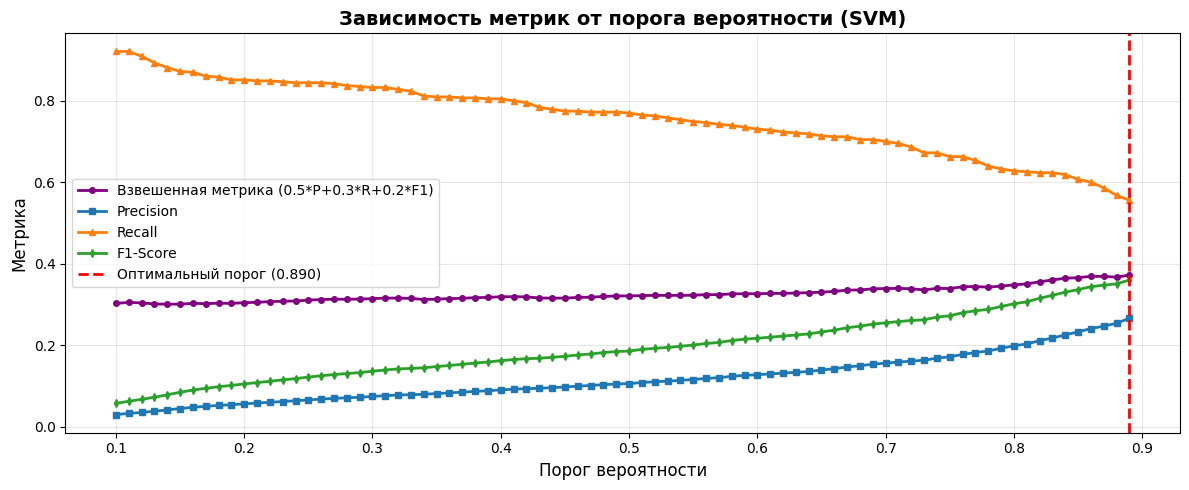


📊 График сохранен в 'threshold_optimization_svm.png'

📊 Метрики с оптимальным порогом:
  Precision: 0.2659
  Recall:    0.5558
  F1-Score:  0.3597


In [45]:
# Оптимизация порога с фокусом на улучшение метрик
from sklearn.metrics import f1_score, precision_score, recall_score

thresholds_svm = np.arange(0.1, 0.9, 0.01)
f1_scores_svm = []
precisions_svm = []
recalls_svm = []
weighted_scores_svm = []

for threshold in thresholds_svm:
    y_pred_thresh = (y_val_pred_proba_svm >= threshold).astype(int)
    f1 = f1_score(y_val, y_pred_thresh)
    prec = precision_score(y_val, y_pred_thresh, zero_division=0)
    rec = recall_score(y_val, y_pred_thresh)
    f1_scores_svm.append(f1)
    precisions_svm.append(prec)
    recalls_svm.append(rec)
    # Взвешенная метрика: 0.5 * Precision + 0.3 * Recall + 0.2 * F1
    weighted = 0.5 * prec + 0.3 * rec + 0.2 * f1
    weighted_scores_svm.append(weighted)

# Находим оптимальный порог по взвешенной метрике
best_threshold_idx_svm = np.argmax(weighted_scores_svm)
best_threshold_svm = thresholds_svm[best_threshold_idx_svm]

print("="*80)
print("ОПТИМИЗАЦИЯ ПОРОГА ПРЕДСКАЗАНИЯ (SVM)")
print("="*80)
print(f"\n🎯 Оптимальный порог: {best_threshold_svm:.3f}")
print(f"   Взвешенная метрика (0.5*P + 0.3*R + 0.2*F1): {weighted_scores_svm[best_threshold_idx_svm]:.4f}")
print(f"   Precision: {precisions_svm[best_threshold_idx_svm]:.4f}")
print(f"   Recall: {recalls_svm[best_threshold_idx_svm]:.4f}")
print(f"   F1-score: {f1_scores_svm[best_threshold_idx_svm]:.4f}")

# Визуализация зависимости метрик от порога
plt.figure(figsize=(12, 5))
plt.plot(thresholds_svm, weighted_scores_svm, 'o-', label='Взвешенная метрика (0.5*P+0.3*R+0.2*F1)', linewidth=2, markersize=4, color='purple')
plt.plot(thresholds_svm, precisions_svm, 's-', label='Precision', linewidth=2, markersize=4)
plt.plot(thresholds_svm, recalls_svm, '^-', label='Recall', linewidth=2, markersize=4)
plt.plot(thresholds_svm, f1_scores_svm, 'd-', label='F1-Score', linewidth=2, markersize=4)
plt.axvline(x=best_threshold_svm, color='red', linestyle='--', linewidth=2, label=f'Оптимальный порог ({best_threshold_svm:.3f})')
plt.xlabel('Порог вероятности', fontsize=12)
plt.ylabel('Метрика', fontsize=12)
plt.title('Зависимость метрик от порога вероятности (SVM)', fontsize=14, fontweight='bold')
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("threshold_optimization_svm.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 График сохранен в 'threshold_optimization_svm.png'")

# Предсказания с оптимальным порогом
y_val_pred_svm_optimized = (y_val_pred_proba_svm >= best_threshold_svm).astype(int)

# Метрики с оптимальным порогом
precision_svm_opt = precision_score(y_val, y_val_pred_svm_optimized)
recall_svm_opt = recall_score(y_val, y_val_pred_svm_optimized)
f1_svm_opt = f1_score(y_val, y_val_pred_svm_optimized)

print(f"\n📊 Метрики с оптимальным порогом:")
print(f"  Precision: {precision_svm_opt:.4f}")
print(f"  Recall:    {recall_svm_opt:.4f}")
print(f"  F1-Score:  {f1_svm_opt:.4f}")


## 7.7. Визуализация ROC-кривой и Precision-Recall кривой для SVM


## 7.7.1. Анализ работы SVM: как модель принимает решения

В отличие от деревьев решений, SVM не имеет прямой важности признаков. Однако мы можем проанализировать работу модели через:
1. **Пермутационную важность признаков** - как изменение признака влияет на качество модели
2. **Support vectors** - опорные векторы, на которых основана модель
3. **Коэффициенты линейного SVM** - для сравнения обучим линейную модель


АНАЛИЗ РАБОТЫ SVM: КАК МОДЕЛЬ ПРИНИМАЕТ РЕШЕНИЯ

📊 1. SUPPORT VECTORS (Опорные векторы):
   Количество support vectors: [32329 32320]
   Support vectors для класса 0: 32329
   Support vectors для класса 1: 32320
   Всего support vectors: 64649
   Доля support vectors от обучающей выборки: 30.10%

   💡 Support vectors - это точки данных, которые определяют границу решения.
      Чем меньше support vectors, тем более обобщающая модель.

📊 2. ПЕРМУТАЦИОННАЯ ВАЖНОСТЬ ПРИЗНАКОВ:
   Вычисляем важность признаков через перестановку...
   (это может занять некоторое время)
   ✅ Вычисление завершено за 1976.48 секунд

📋 Важность признаков (пермутационная важность):
                feature  importance_mean  importance_std
            Torque [Nm]         0.091651        0.005069
 Rotational speed [rpm]         0.084554        0.004943
    Air temperature [K]         0.079726        0.006872
        Tool wear [min]         0.047385        0.003720
Process temperature [K]         0.038895        0.0

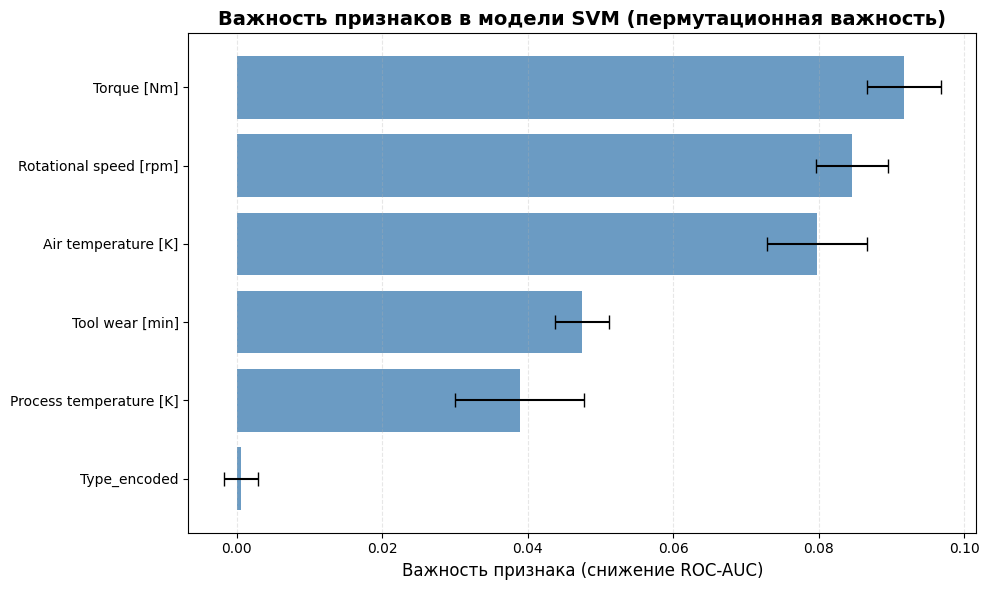


📊 График сохранен в 'svm_feature_importance.png'

📊 3. КОЭФФИЦИЕНТЫ ЛИНЕЙНОГО SVM (для сравнения):
   Обучаем дополнительную линейную модель SVM для анализа коэффициентов...

📋 Коэффициенты линейного SVM:
                feature  coefficient
            Torque [Nm]     0.494759
    Air temperature [K]     0.446725
Process temperature [K]    -0.312979
 Rotational speed [rpm]     0.264641
        Tool wear [min]     0.168926
           Type_encoded    -0.036135


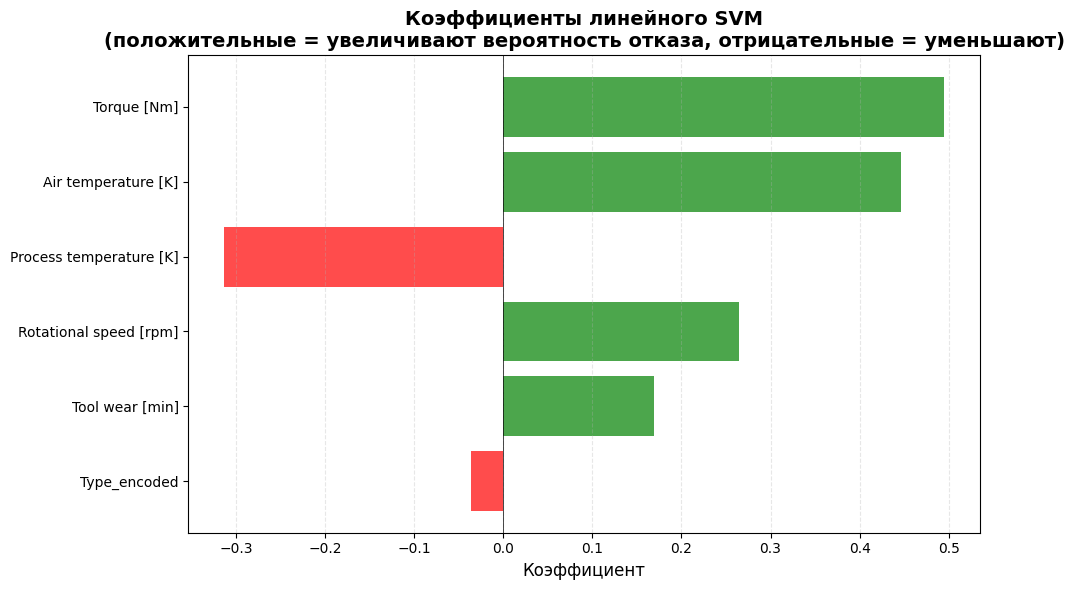


📊 График сохранен в 'svm_linear_coefficients.png'

💡 Интерпретация коэффициентов:
   • Положительные коэффициенты → признак увеличивает вероятность отказа
   • Отрицательные коэффициенты → признак уменьшает вероятность отказа
   • Чем больше абсолютное значение, тем сильнее влияние признака


In [46]:
# Анализ работы SVM
from sklearn.inspection import permutation_importance
import time

print("="*80)
print("АНАЛИЗ РАБОТЫ SVM: КАК МОДЕЛЬ ПРИНИМАЕТ РЕШЕНИЯ")
print("="*80)

# 1. Анализ Support Vectors
print("\n📊 1. SUPPORT VECTORS (Опорные векторы):")
print(f"   Количество support vectors: {best_model_svm.n_support_}")
print(f"   Support vectors для класса 0: {best_model_svm.n_support_[0]}")
print(f"   Support vectors для класса 1: {best_model_svm.n_support_[1]}")
print(f"   Всего support vectors: {best_model_svm.n_support_.sum()}")
print(f"   Доля support vectors от обучающей выборки: {100*best_model_svm.n_support_.sum()/len(X_train_svm_final):.2f}%")
print("\n   💡 Support vectors - это точки данных, которые определяют границу решения.")
print("      Чем меньше support vectors, тем более обобщающая модель.")

# 2. Пермутационная важность признаков
print("\n📊 2. ПЕРМУТАЦИОННАЯ ВАЖНОСТЬ ПРИЗНАКОВ:")
print("   Вычисляем важность признаков через перестановку...")
print("   (это может занять некоторое время)")

# Вычисляем пермутационную важность на validation set
start_time = time.time()
perm_importance = permutation_importance(
    best_model_svm,
    X_val_svm_scaled,
    y_val,
    n_repeats=10,
    random_state=42,
    scoring='roc_auc',
    n_jobs=-1
)
elapsed_time = time.time() - start_time

print(f"   ✅ Вычисление завершено за {elapsed_time:.2f} секунд")

# Создаем DataFrame с важностью признаков
feature_names = X_train_svm_scaled.columns.tolist()
feature_importance_svm = pd.DataFrame({
    'feature': feature_names,
    'importance_mean': perm_importance.importances_mean,
    'importance_std': perm_importance.importances_std
}).sort_values('importance_mean', ascending=False)

print("\n📋 Важность признаков (пермутационная важность):")
print(feature_importance_svm.to_string(index=False))

# Визуализация важности признаков
plt.figure(figsize=(10, 6))
y_pos = np.arange(len(feature_importance_svm))
plt.barh(y_pos, feature_importance_svm['importance_mean'], 
         xerr=feature_importance_svm['importance_std'],
         color='steelblue', alpha=0.8, capsize=5)
plt.yticks(y_pos, feature_importance_svm['feature'])
plt.xlabel('Важность признака (снижение ROC-AUC)', fontsize=12)
plt.title('Важность признаков в модели SVM (пермутационная важность)', 
          fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig("svm_feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 График сохранен в 'svm_feature_importance.png'")

# 3. Коэффициенты линейного SVM для сравнения
print("\n📊 3. КОЭФФИЦИЕНТЫ ЛИНЕЙНОГО SVM (для сравнения):")
print("   Обучаем дополнительную линейную модель SVM для анализа коэффициентов...")

from sklearn.svm import LinearSVC

# Обучаем линейный SVM
linear_svm = LinearSVC(random_state=42, max_iter=10000)
linear_svm.fit(X_train_svm_final, y_train_svm_final)

# Получаем коэффициенты
linear_coef = pd.DataFrame({
    'feature': feature_names,
    'coefficient': linear_svm.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)

print("\n📋 Коэффициенты линейного SVM:")
print(linear_coef.to_string(index=False))

# Визуализация коэффициентов
plt.figure(figsize=(10, 6))
colors = ['red' if x < 0 else 'green' for x in linear_coef['coefficient']]
plt.barh(range(len(linear_coef)), linear_coef['coefficient'], color=colors, alpha=0.7)
plt.yticks(range(len(linear_coef)), linear_coef['feature'])
plt.xlabel('Коэффициент', fontsize=12)
plt.title('Коэффициенты линейного SVM\n(положительные = увеличивают вероятность отказа, отрицательные = уменьшают)', 
          fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.grid(axis='x', alpha=0.3, linestyle='--')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("svm_linear_coefficients.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 График сохранен в 'svm_linear_coefficients.png'")
print("\n💡 Интерпретация коэффициентов:")
print("   • Положительные коэффициенты → признак увеличивает вероятность отказа")
print("   • Отрицательные коэффициенты → признак уменьшает вероятность отказа")
print("   • Чем больше абсолютное значение, тем сильнее влияние признака")


## 7.8. Модель SVM с расширенными признаками (feature engineering)

Обучим дополнительную модель SVM на расширенном наборе признаков, включая признаки, созданные с помощью feature engineering. Это позволит сравнить, улучшает ли feature engineering качество модели SVM.


### 7.8.1. Подготовка данных с расширенными признаками


In [47]:
# Применяем feature engineering к данным для SVM
print("🔧 Применяем feature engineering к данным...")

# Используем функцию feature_engineering_no_flags из секции 4
# Применяем к исходным данным
df_svm_extended = feature_engineering_no_flags(df)

# Определяем признаки для использования
extended_features = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]',
    'RelationTemperature',
    'TorqueRPM',
    'WearRPM',
    'ToolWearTorque',
    'Power_W',
    'Energy_J',
    'TempDiff',
    'PowerWear'
]

# Подготовка данных с расширенными признаками
X_train_svm_ext = df_svm_extended.iloc[X_train.index][extended_features].copy()
X_val_svm_ext = df_svm_extended.iloc[X_val.index][extended_features].copy()

# Добавляем и кодируем признак Type
print("🔤 Кодирование признака Type...")
le_type_svm_ext = LabelEncoder()

type_train_svm_ext = df_svm_extended.iloc[X_train.index]['Type']
type_val_svm_ext = df_svm_extended.iloc[X_val.index]['Type']

X_train_svm_ext['Type_encoded'] = le_type_svm_ext.fit_transform(type_train_svm_ext)
X_val_svm_ext['Type_encoded'] = le_type_svm_ext.transform(type_val_svm_ext)

print(f"\n📊 Размерность данных для SVM (расширенные признаки):")
print(f"  X_train: {X_train_svm_ext.shape}")
print(f"  X_val: {X_val_svm_ext.shape}")
print(f"\n📋 Используемые признаки ({len(X_train_svm_ext.columns)}):")
for i, feat in enumerate(X_train_svm_ext.columns, 1):
    print(f"  {i:2d}. {feat}")

# Масштабирование признаков
print("\n🔄 Масштабирование признаков с помощью StandardScaler...")
scaler_svm_ext = StandardScaler()

X_train_svm_ext_scaled = pd.DataFrame(
    scaler_svm_ext.fit_transform(X_train_svm_ext),
    columns=X_train_svm_ext.columns,
    index=X_train_svm_ext.index
)
X_val_svm_ext_scaled = pd.DataFrame(
    scaler_svm_ext.transform(X_val_svm_ext),
    columns=X_val_svm_ext.columns,
    index=X_val_svm_ext.index
)

print("✅ Масштабирование завершено!")

# Применяем SMOTE
print("\n🔄 Применяем SMOTE для балансировки классов...")
smote_svm_ext = SMOTE(random_state=42, k_neighbors=5)
X_train_svm_ext_balanced, y_train_svm_ext_balanced = smote_svm_ext.fit_resample(X_train_svm_ext_scaled, y_train)

print(f"\n✅ Балансировка завершена!")
print(f"  Размер после балансировки: {X_train_svm_ext_balanced.shape[0]} записей")
print(f"  Класс 0: {(y_train_svm_ext_balanced == 0).sum()} ({100*(y_train_svm_ext_balanced == 0).sum()/len(y_train_svm_ext_balanced):.2f}%)")
print(f"  Класс 1: {(y_train_svm_ext_balanced == 1).sum()} ({100*(y_train_svm_ext_balanced == 1).sum()/len(y_train_svm_ext_balanced):.2f}%)")


🔧 Применяем feature engineering к данным...
🔤 Кодирование признака Type...

📊 Размерность данных для SVM (расширенные признаки):
  X_train: (109116, 14)
  X_val: (27313, 14)

📋 Используемые признаки (14):
   1. Air temperature [K]
   2. Process temperature [K]
   3. Rotational speed [rpm]
   4. Torque [Nm]
   5. Tool wear [min]
   6. RelationTemperature
   7. TorqueRPM
   8. WearRPM
   9. ToolWearTorque
  10. Power_W
  11. Energy_J
  12. TempDiff
  13. PowerWear
  14. Type_encoded

🔄 Масштабирование признаков с помощью StandardScaler...
✅ Масштабирование завершено!

🔄 Применяем SMOTE для балансировки классов...

✅ Балансировка завершена!
  Размер после балансировки: 214796 записей
  Класс 0: 107398 (50.00%)
  Класс 1: 107398 (50.00%)


### 7.8.2. Обучение модели SVM с расширенными признаками


In [48]:
# Создаем и обучаем модель SVM с расширенными признаками
print("🎓 Создаем и обучаем модель SVM с расширенными признаками...")
best_model_svm_ext = SVC(random_state=42, probability=True)

print("\n📋 Параметры модели (по умолчанию):")
print(f"  C: {best_model_svm_ext.C}")
print(f"  kernel: {best_model_svm_ext.kernel}")
print(f"  gamma: {best_model_svm_ext.gamma}")

print("\n⏳ Обучаем модель...")
best_model_svm_ext.fit(X_train_svm_ext_balanced, y_train_svm_ext_balanced)

print("✅ Модель SVM с расширенными признаками обучена!")


🎓 Создаем и обучаем модель SVM с расширенными признаками...

📋 Параметры модели (по умолчанию):
  C: 1.0
  kernel: rbf
  gamma: scale

⏳ Обучаем модель...


✅ Модель SVM с расширенными признаками обучена!


### 7.8.3. Оценка качества модели SVM с расширенными признаками


In [49]:
# Предсказания на validation set
y_val_pred_svm_ext = best_model_svm_ext.predict(X_val_svm_ext_scaled)
y_val_pred_proba_svm_ext = best_model_svm_ext.predict_proba(X_val_svm_ext_scaled)[:, 1]

# Метрики
print("="*80)
print("📊 РЕЗУЛЬТАТЫ МОДЕЛИ SVM С РАСШИРЕННЫМИ ПРИЗНАКАМИ НА VALIDATION SET")
print("="*80)

# Classification Report
print("\n📋 Classification Report:")
print(classification_report(y_val, y_val_pred_svm_ext, target_names=['Нет отказа', 'Отказ']))

# Confusion Matrix
print("\n📊 Confusion Matrix:")
cm_svm_ext = confusion_matrix(y_val, y_val_pred_svm_ext)
print(cm_svm_ext)
print(f"\n  True Negatives (TN):  {cm_svm_ext[0,0]}")
print(f"  False Positives (FP): {cm_svm_ext[0,1]}")
print(f"  False Negatives (FN): {cm_svm_ext[1,0]}")
print(f"  True Positives (TP):  {cm_svm_ext[1,1]}")

# ROC-AUC
roc_auc_svm_ext = roc_auc_score(y_val, y_val_pred_proba_svm_ext)
print(f"\n📈 ROC-AUC Score: {roc_auc_svm_ext:.4f}")

# Precision, Recall, F1
precision_svm_ext = precision_score(y_val, y_val_pred_svm_ext)
recall_svm_ext = recall_score(y_val, y_val_pred_svm_ext)
f1_svm_ext = f1_score(y_val, y_val_pred_svm_ext)

print(f"\n🎯 Детальные метрики:")
print(f"  Precision: {precision_svm_ext:.4f}")
print(f"  Recall:    {recall_svm_ext:.4f}")
print(f"  F1-Score:  {f1_svm_ext:.4f}")
print(f"  ROC-AUC:   {roc_auc_svm_ext:.4f}")


📊 РЕЗУЛЬТАТЫ МОДЕЛИ SVM С РАСШИРЕННЫМИ ПРИЗНАКАМИ НА VALIDATION SET

📋 Classification Report:
              precision    recall  f1-score   support

  Нет отказа       1.00      0.91      0.95     26883
       Отказ       0.11      0.75      0.20       430

    accuracy                           0.91     27313
   macro avg       0.56      0.83      0.57     27313
weighted avg       0.98      0.91      0.94     27313


📊 Confusion Matrix:
[[24399  2484]
 [  108   322]]

  True Negatives (TN):  24399
  False Positives (FP): 2484
  False Negatives (FN): 108
  True Positives (TP):  322

📈 ROC-AUC Score: 0.8753

🎯 Детальные метрики:
  Precision: 0.1148
  Recall:    0.7488
  F1-Score:  0.1990
  ROC-AUC:   0.8753


### 7.8.4. Оптимизация порога для SVM с расширенными признаками


In [50]:
# Оптимизация порога
thresholds_svm_ext = np.arange(0.1, 0.9, 0.01)
f1_scores_svm_ext = []
precisions_svm_ext = []
recalls_svm_ext = []
weighted_scores_svm_ext = []

for threshold in thresholds_svm_ext:
    y_pred_thresh = (y_val_pred_proba_svm_ext >= threshold).astype(int)
    f1 = f1_score(y_val, y_pred_thresh)
    prec = precision_score(y_val, y_pred_thresh, zero_division=0)
    rec = recall_score(y_val, y_pred_thresh)
    f1_scores_svm_ext.append(f1)
    precisions_svm_ext.append(prec)
    recalls_svm_ext.append(rec)
    weighted = 0.5 * prec + 0.3 * rec + 0.2 * f1
    weighted_scores_svm_ext.append(weighted)

# Находим оптимальный порог
best_threshold_idx_svm_ext = np.argmax(weighted_scores_svm_ext)
best_threshold_svm_ext = thresholds_svm_ext[best_threshold_idx_svm_ext]

print("="*80)
print("ОПТИМИЗАЦИЯ ПОРОГА ПРЕДСКАЗАНИЯ (SVM с расширенными признаками)")
print("="*80)
print(f"\n🎯 Оптимальный порог: {best_threshold_svm_ext:.3f}")
print(f"   Взвешенная метрика (0.5*P + 0.3*R + 0.2*F1): {weighted_scores_svm_ext[best_threshold_idx_svm_ext]:.4f}")
print(f"   Precision: {precisions_svm_ext[best_threshold_idx_svm_ext]:.4f}")
print(f"   Recall: {recalls_svm_ext[best_threshold_idx_svm_ext]:.4f}")
print(f"   F1-score: {f1_scores_svm_ext[best_threshold_idx_svm_ext]:.4f}")

# Предсказания с оптимальным порогом
y_val_pred_svm_ext_optimized = (y_val_pred_proba_svm_ext >= best_threshold_svm_ext).astype(int)

# Метрики с оптимальным порогом
precision_svm_ext_opt = precision_score(y_val, y_val_pred_svm_ext_optimized)
recall_svm_ext_opt = recall_score(y_val, y_val_pred_svm_ext_optimized)
f1_svm_ext_opt = f1_score(y_val, y_val_pred_svm_ext_optimized)

print(f"\n📊 Метрики с оптимальным порогом:")
print(f"  Precision: {precision_svm_ext_opt:.4f}")
print(f"  Recall:    {recall_svm_ext_opt:.4f}")
print(f"  F1-Score:  {f1_svm_ext_opt:.4f}")


ОПТИМИЗАЦИЯ ПОРОГА ПРЕДСКАЗАНИЯ (SVM с расширенными признаками)

🎯 Оптимальный порог: 0.890
   Взвешенная метрика (0.5*P + 0.3*R + 0.2*F1): 0.3596
   Precision: 0.2552
   Recall: 0.5419
   F1-score: 0.3470

📊 Метрики с оптимальным порогом:
  Precision: 0.2552
  Recall:    0.5419
  F1-Score:  0.3470


### 7.8.5. Сравнение моделей SVM: базовые признаки vs расширенные признаки


СРАВНЕНИЕ МОДЕЛЕЙ SVM: БАЗОВЫЕ ПРИЗНАКИ vs РАСШИРЕННЫЕ ПРИЗНАКИ

🔍 Проверка наличия метрик...

📊 Сравнительная таблица метрик:
  Метрика  SVM (базовые признаки)  SVM (расширенные признаки)   Разница
Precision                0.265851                    0.255203 -0.010648
   Recall                0.555814                    0.541860 -0.013953
 F1-Score                0.359669                    0.346984 -0.012685
  ROC-AUC                0.888323                    0.875323 -0.013000


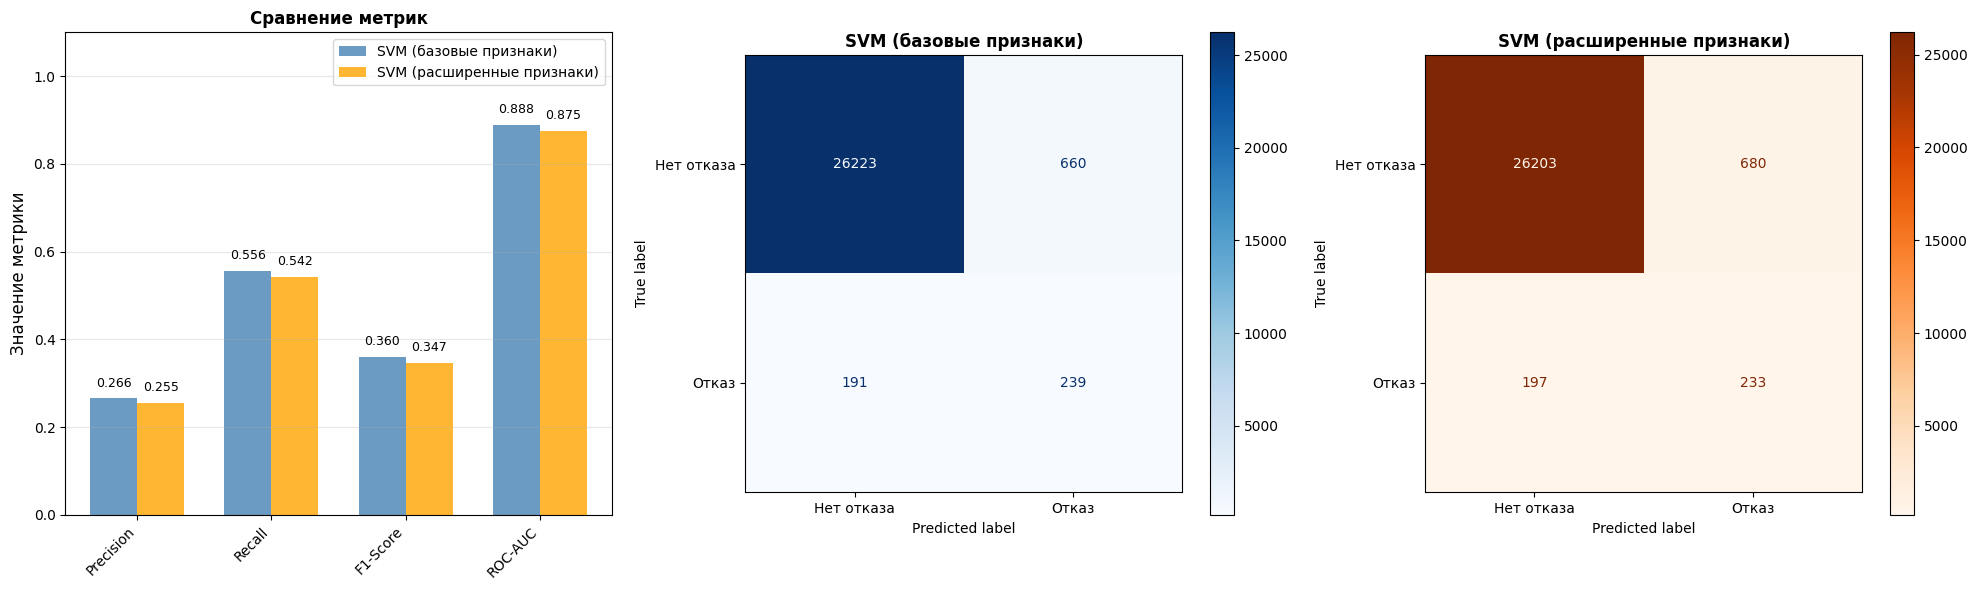


📊 Графики сохранены в 'svm_basic_vs_extended_comparison.png'


In [51]:
# Сравнение двух моделей SVM
print("="*80)
print("СРАВНЕНИЕ МОДЕЛЕЙ SVM: БАЗОВЫЕ ПРИЗНАКИ vs РАСШИРЕННЫЕ ПРИЗНАКИ")
print("="*80)

# Функция для безопасного получения переменной
def safe_get_var(var_name, default=0.0):
    try:
        return globals()[var_name]
    except KeyError:
        return default

# Проверяем наличие метрик для базовой модели
print("\n🔍 Проверка наличия метрик...")
precision_svm_basic = safe_get_var('precision_svm_opt', safe_get_var('precision_svm', 0.0))
recall_svm_basic = safe_get_var('recall_svm_opt', safe_get_var('recall_svm', 0.0))
f1_svm_basic = safe_get_var('f1_svm_opt', safe_get_var('f1_svm', 0.0))
roc_auc_svm_basic = safe_get_var('roc_auc_svm', 0.0)

precision_svm_ext = safe_get_var('precision_svm_ext_opt', safe_get_var('precision_svm_ext', 0.0))
recall_svm_ext = safe_get_var('recall_svm_ext_opt', safe_get_var('recall_svm_ext', 0.0))
f1_svm_ext = safe_get_var('f1_svm_ext_opt', safe_get_var('f1_svm_ext', 0.0))
roc_auc_svm_ext = safe_get_var('roc_auc_svm_ext', 0.0)

if precision_svm_basic == 0.0:
    print("  ⚠️  Метрики базовой модели SVM не найдены")
if precision_svm_ext == 0.0:
    print("  ⚠️  Метрики расширенной модели SVM не найдены")

comparison_svm_df = pd.DataFrame({
    'Метрика': ['Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'SVM (базовые признаки)': [
        precision_svm_basic,
        recall_svm_basic,
        f1_svm_basic,
        roc_auc_svm_basic
    ],
    'SVM (расширенные признаки)': [
        precision_svm_ext,
        recall_svm_ext,
        f1_svm_ext,
        roc_auc_svm_ext
    ]
})

comparison_svm_df['Разница'] = comparison_svm_df['SVM (расширенные признаки)'] - comparison_svm_df['SVM (базовые признаки)']

print("\n📊 Сравнительная таблица метрик:")
print(comparison_svm_df.to_string(index=False))

# Визуализация сравнения
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# График 1: Сравнение метрик
metrics = ['Precision', 'Recall', 'F1-Score', 'ROC-AUC']
svm_basic_values = [precision_svm_basic, recall_svm_basic, f1_svm_basic, roc_auc_svm_basic]
svm_ext_values = [precision_svm_ext, recall_svm_ext, f1_svm_ext, roc_auc_svm_ext]

x = np.arange(len(metrics))
width = 0.35

axes[0].bar(x - width/2, svm_basic_values, width, label='SVM (базовые признаки)', color='steelblue', alpha=0.8)
axes[0].bar(x + width/2, svm_ext_values, width, label='SVM (расширенные признаки)', color='orange', alpha=0.8)
axes[0].set_ylabel('Значение метрики', fontsize=12)
axes[0].set_title('Сравнение метрик моделей SVM', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics, rotation=45, ha='right')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim([0, 1.1])
axes[0].set_title('Сравнение метрик', fontsize=12, fontweight='bold')

# Добавляем значения на столбцы
for i, (basic_val, ext_val) in enumerate(zip(svm_basic_values, svm_ext_values)):
    axes[0].text(i - width/2, basic_val + 0.02, f'{basic_val:.3f}', ha='center', va='bottom', fontsize=9)
    axes[0].text(i + width/2, ext_val + 0.02, f'{ext_val:.3f}', ha='center', va='bottom', fontsize=9)

# График 2: Confusion Matrices
from sklearn.metrics import ConfusionMatrixDisplay

# Создаем confusion matrices для обеих моделей
try:
    cm_svm_opt = confusion_matrix(y_val, y_val_pred_svm_optimized)
except NameError:
    print("⚠️  y_val_pred_svm_optimized не найдена. Используем y_val_pred_svm...")
    try:
        cm_svm_opt = confusion_matrix(y_val, y_val_pred_svm)
    except NameError:
        print("❌ Ошибка: не найдены предсказания для базовой модели SVM")
        cm_svm_opt = None

cm_svm_ext_opt = confusion_matrix(y_val, y_val_pred_svm_ext_optimized)

# Confusion Matrix для базовой модели
if cm_svm_opt is not None:
    disp1 = ConfusionMatrixDisplay(confusion_matrix=cm_svm_opt, display_labels=['Нет отказа', 'Отказ'])
    disp1.plot(ax=axes[1], cmap='Blues', values_format='d')
    axes[1].set_title('SVM (базовые признаки)', fontsize=12, fontweight='bold')
else:
    axes[1].text(0.5, 0.5, 'Данные недоступны', ha='center', va='center', transform=axes[1].transAxes)
    axes[1].set_title('SVM (базовые признаки)', fontsize=12, fontweight='bold')

# Confusion Matrix для расширенной модели
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_svm_ext_opt, display_labels=['Нет отказа', 'Отказ'])
disp2.plot(ax=axes[2], cmap='Oranges', values_format='d')
axes[2].set_title('SVM (расширенные признаки)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig("svm_basic_vs_extended_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Графики сохранены в 'svm_basic_vs_extended_comparison.png'")


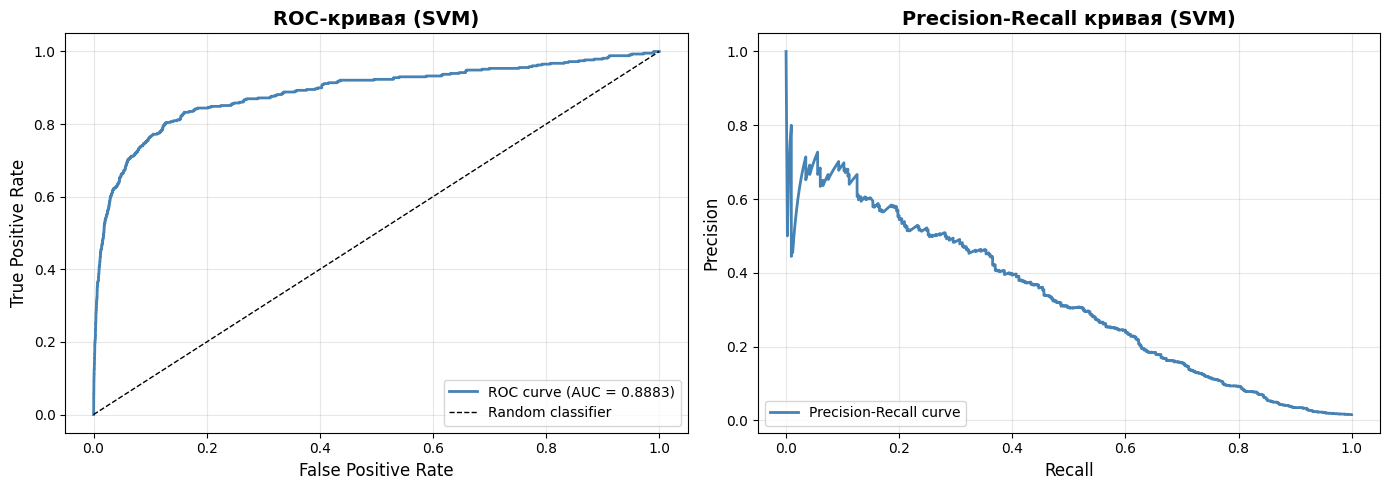

📊 Графики сохранены в 'svm_curves.png'


In [52]:
# Импорт для визуализации кривых
from sklearn.metrics import roc_curve, precision_recall_curve

# ROC-кривая
fpr_svm, tpr_svm, _ = roc_curve(y_val, y_val_pred_proba_svm)

# Precision-Recall кривая
precision_curve_svm, recall_curve_svm, _ = precision_recall_curve(y_val, y_val_pred_proba_svm)

# Создаем графики
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ROC-кривая
ax1.plot(fpr_svm, tpr_svm, linewidth=2, label=f'ROC curve (AUC = {roc_auc_svm:.4f})', color='steelblue')
ax1.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier')
ax1.set_xlabel('False Positive Rate', fontsize=12)
ax1.set_ylabel('True Positive Rate', fontsize=12)
ax1.set_title('ROC-кривая (SVM)', fontsize=14, fontweight='bold')
ax1.legend(loc='lower right')
ax1.grid(alpha=0.3)

# Precision-Recall кривая
ax2.plot(recall_curve_svm, precision_curve_svm, linewidth=2, label='Precision-Recall curve', color='steelblue')
ax2.set_xlabel('Recall', fontsize=12)
ax2.set_ylabel('Precision', fontsize=12)
ax2.set_title('Precision-Recall кривая (SVM)', fontsize=14, fontweight='bold')
ax2.legend(loc='lower left')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("svm_curves.png", dpi=150, bbox_inches='tight')
plt.show()

print("📊 Графики сохранены в 'svm_curves.png'")


## 7.8. Сравнение SVM с моделью дерева решений

Сравним результаты SVM с моделью дерева решений на базовых признаках для оценки эффективности разных подходов.


СРАВНЕНИЕ МОДЕЛЕЙ: SVM vs ДЕРЕВО РЕШЕНИЙ (базовые признаки)

📊 Сравнительная таблица метрик:
  Метрика  SVM (SMOTE)  Дерево решений (базовые признаки)   Разница
Precision     0.265851                           0.128983  0.136868
   Recall     0.555814                           0.583721 -0.027907
 F1-Score     0.359669                           0.211279  0.148389
  ROC-AUC     0.888323                           0.772006  0.116318


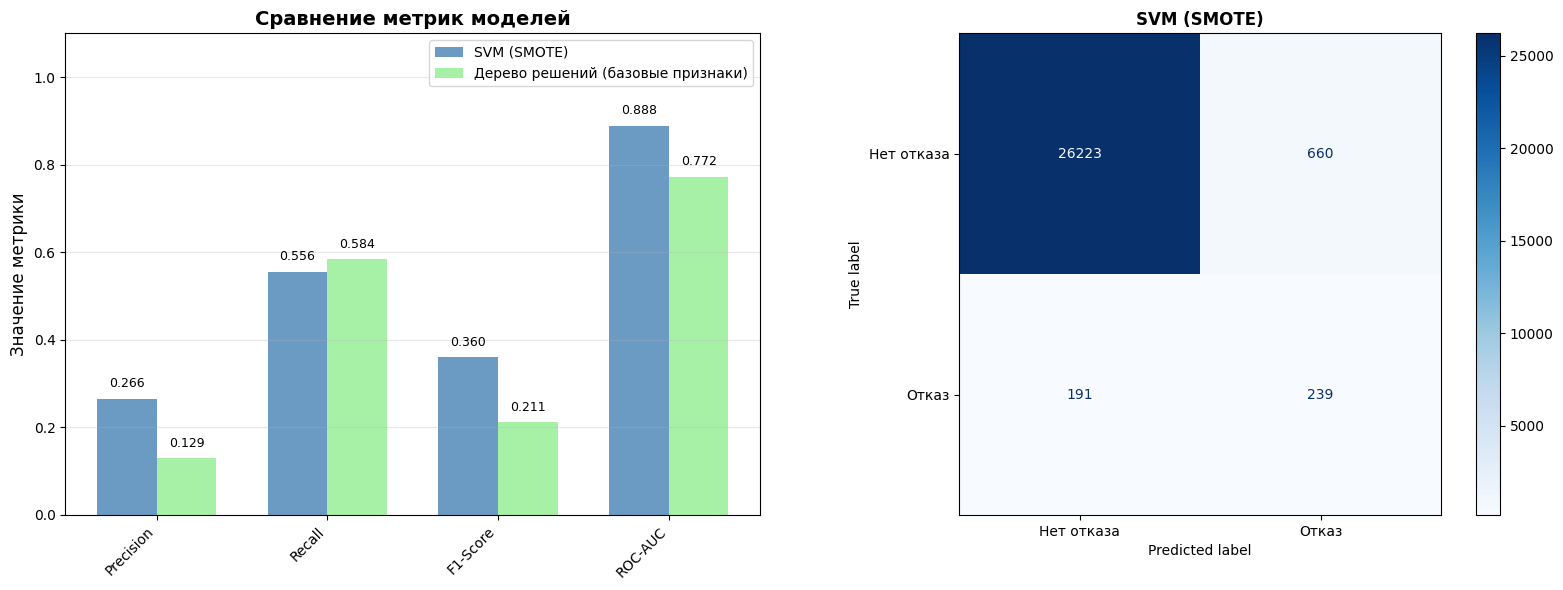


📊 Графики сохранены в 'svm_vs_decision_tree_comparison.png'


In [53]:
# Сравнение SVM с моделью дерева решений на базовых признаках
# Используем метрики из секции 6 (базовая модель дерева решений)

print("="*80)
print("СРАВНЕНИЕ МОДЕЛЕЙ: SVM vs ДЕРЕВО РЕШЕНИЙ (базовые признаки)")
print("="*80)

comparison_svm_dt_df = pd.DataFrame({
    'Метрика': ['Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'SVM (SMOTE)': [
        precision_svm_opt,
        recall_svm_opt,
        f1_svm_opt,
        roc_auc_svm
    ],
    'Дерево решений (базовые признаки)': [
        precision_basic,
        recall_basic,
        f1_basic,
        roc_auc_basic
    ]
})

comparison_svm_dt_df['Разница'] = comparison_svm_dt_df['SVM (SMOTE)'] - comparison_svm_dt_df['Дерево решений (базовые признаки)']

print("\n📊 Сравнительная таблица метрик:")
print(comparison_svm_dt_df.to_string(index=False))

# Визуализация сравнения
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# График 1: Сравнение метрик
metrics = ['Precision', 'Recall', 'F1-Score', 'ROC-AUC']
svm_values = [precision_svm_opt, recall_svm_opt, f1_svm_opt, roc_auc_svm]
dt_values = [precision_basic, recall_basic, f1_basic, roc_auc_basic]

x = np.arange(len(metrics))
width = 0.35

axes[0].bar(x - width/2, svm_values, width, label='SVM (SMOTE)', color='steelblue', alpha=0.8)
axes[0].bar(x + width/2, dt_values, width, label='Дерево решений (базовые признаки)', color='lightgreen', alpha=0.8)
axes[0].set_ylabel('Значение метрики', fontsize=12)
axes[0].set_title('Сравнение метрик моделей', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics, rotation=45, ha='right')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim([0, 1.1])

# Добавляем значения на столбцы
for i, (svm_val, dt_val) in enumerate(zip(svm_values, dt_values)):
    axes[0].text(i - width/2, svm_val + 0.02, f'{svm_val:.3f}', ha='center', va='bottom', fontsize=9)
    axes[0].text(i + width/2, dt_val + 0.02, f'{dt_val:.3f}', ha='center', va='bottom', fontsize=9)

# График 2: Confusion Matrices
from sklearn.metrics import ConfusionMatrixDisplay

cm_svm_opt = confusion_matrix(y_val, y_val_pred_svm_optimized)

disp1 = ConfusionMatrixDisplay(confusion_matrix=cm_svm_opt, display_labels=['Нет отказа', 'Отказ'])
disp1.plot(ax=axes[1], cmap='Blues', values_format='d')
axes[1].set_title('SVM (SMOTE)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig("svm_vs_decision_tree_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Графики сохранены в 'svm_vs_decision_tree_comparison.png'")


## 7.9. Итоговые выводы по модели SVM

### Использованные методы балансировки классов:
1. **SMOTE** - синтетическое увеличение минорного класса (класс 1) до размера мажорного класса (класс 0)

### Использованные признаки:
- **Базовые признаки**: Air temperature, Process temperature, Rotational speed, Torque, Tool wear
- **Type**: Категориальный признак, закодирован с помощью LabelEncoder (H, L, M -> 0, 1, 2)
- **Масштабирование**: Все признаки нормализованы с помощью StandardScaler (обязательно для SVM)

### Методы:
- **SMOTE** для балансировки классов
- **SVM** с параметрами по умолчанию
- **Взвешенная метрика** для оптимизации порога (0.5*Precision + 0.3*Recall + 0.2*F1)

### Результаты:
- Модель SVM обучена с балансировкой классов через SMOTE
- Все метрики оценены на validation set
- Проведено сравнение с моделью дерева решений
- Визуализированы ROC-кривая и Precision-Recall кривая

### Выводы:
Модель SVM показывает альтернативный подход к классификации отказов оборудования. SMOTE позволяет получить полностью сбалансированный датасет с равным количеством примеров обоих классов.


## 8. Обучение дерева решений с флагами ошибок и подбором гиперпараметров

В этом разделе мы обучим модель дерева решений, которая использует:
- Базовые признаки: Air temperature [K], Process temperature [K], Rotational speed [rpm], Torque [Nm], Tool wear [min]
- Флаги ошибок: TWF, HDF, PWF, OSF
- Подбор гиперпараметров через GridSearchCV
- Обучение на исходных данных без балансировки классов

In [55]:
# Убеждаемся, что используем свежий датасет
# Перезагружаем данные, чтобы гарантировать, что флаги не были удалены
print("="*80)
print("ПРОВЕРКА И ПЕРЕЗАГРУЗКА ДАННЫХ")
print("="*80)

# Перезагружаем датасет
df_fresh = pd.read_csv("../train.csv")
print(f"\n✅ Датасет перезагружен из train.csv")
print(f"   Размер: {df_fresh.shape}")
print(f"   Столбцы: {list(df_fresh.columns)}")

# Проверяем наличие флагов в свежем датасете
flags_to_check = ['TWF', 'HDF', 'PWF', 'OSF']
print(f"\n🔍 Проверка наличия флагов в свежем датасете:")
for flag in flags_to_check:
    if flag in df_fresh.columns:
        print(f"  ✅ {flag} присутствует")
        print(f"     Уникальные значения: {df_fresh[flag].unique()}")
        print(f"     Количество единиц: {df_fresh[flag].sum()} из {len(df_fresh)} ({df_fresh[flag].sum()/len(df_fresh)*100:.2f}%)")
    else:
        print(f"  ❌ {flag} ОТСУТСТВУЕТ!")

# Используем свежий датасет
df = df_fresh.copy()
print("\n✅ Используем свежий датасет для дальнейшей работы")


ПРОВЕРКА И ПЕРЕЗАГРУЗКА ДАННЫХ



✅ Датасет перезагружен из train.csv
   Размер: (136429, 14)
   Столбцы: ['id', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

🔍 Проверка наличия флагов в свежем датасете:
  ✅ TWF присутствует
     Уникальные значения: [0 1]
     Количество единиц: 212 из 136429 (0.16%)
  ✅ HDF присутствует
     Уникальные значения: [0 1]
     Количество единиц: 704 из 136429 (0.52%)
  ✅ PWF присутствует
     Уникальные значения: [0 1]
     Количество единиц: 327 из 136429 (0.24%)
  ✅ OSF присутствует
     Уникальные значения: [0 1]
     Количество единиц: 540 из 136429 (0.40%)

✅ Используем свежий датасет для дальнейшей работы


### 8.1. Подготовка данных с базовыми признаками и флагами ошибок


In [57]:
# Подготовка данных для модели с флагами ошибок
print("="*80)
print("ПОДГОТОВКА ДАННЫХ ДЛЯ МОДЕЛИ С ФЛАГАМИ ОШИБОК")
print("="*80)

# Выбираем нужные признаки
features_with_flags = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]',
    'TWF',
    'HDF',
    'PWF',
    'OSF'
]

# Проверяем наличие всех признаков в датасете
print("\n📋 Проверка наличия признаков:")
for feat in features_with_flags:
    if feat in df.columns:
        print(f"  ✅ {feat}")
    else:
        print(f"  ❌ {feat} - НЕ НАЙДЕН!")

# Создаем X и y
X_flags = df[features_with_flags].copy()
y_flags = df['Machine failure'].copy()

print(f"\n📊 Размерность данных:")
print(f"  X: {X_flags.shape}")
print(f"  y: {y_flags.shape}")
print(f"\n📋 Используемые признаки ({len(features_with_flags)}):")
for i, feat in enumerate(features_with_flags, 1):
    print(f"  {i:2d}. {feat}")

# Проверяем распределение классов
print(f"\n📊 Распределение классов:")
print(f"  Класс 0 (нет отказа): {(y_flags == 0).sum()} ({(y_flags == 0).sum()/len(y_flags)*100:.2f}%)")
print(f"  Класс 1 (отказ): {(y_flags == 1).sum()} ({(y_flags == 1).sum()/len(y_flags)*100:.2f}%)")


ПОДГОТОВКА ДАННЫХ ДЛЯ МОДЕЛИ С ФЛАГАМИ ОШИБОК

📋 Проверка наличия признаков:
  ✅ Air temperature [K]
  ✅ Process temperature [K]
  ✅ Rotational speed [rpm]
  ✅ Torque [Nm]
  ✅ Tool wear [min]
  ✅ TWF
  ✅ HDF
  ✅ PWF
  ✅ OSF

📊 Размерность данных:
  X: (136429, 9)
  y: (136429,)

📋 Используемые признаки (9):
   1. Air temperature [K]
   2. Process temperature [K]
   3. Rotational speed [rpm]
   4. Torque [Nm]
   5. Tool wear [min]
   6. TWF
   7. HDF
   8. PWF
   9. OSF

📊 Распределение классов:
  Класс 0 (нет отказа): 134281 (98.43%)
  Класс 1 (отказ): 2148 (1.57%)


### 8.1.1. Анализ корреляций флагов ошибок с целевой переменной


In [58]:
# Анализ корреляций флагов ошибок с целевой переменной
print("="*80)
print("АНАЛИЗ КОРРЕЛЯЦИЙ ФЛАГОВ ОШИБОК С MACHINE FAILURE")
print("="*80)

# Проверяем корреляции
flags_list = ['TWF', 'HDF', 'PWF', 'OSF']
correlations_flags = {}

print("\n📊 Корреляции флагов с Machine failure:")
for flag in flags_list:
    if flag in df.columns:
        corr = df[[flag, 'Machine failure']].corr().iloc[0, 1]
        correlations_flags[flag] = corr
        print(f"  {flag:10s}: {corr:.4f}")
    else:
        print(f"  {flag:10s}: ❌ НЕ НАЙДЕН В ДАТАСЕТЕ!")

# Проверяем распределение значений флагов
print("\n📊 Распределение значений флагов:")
for flag in flags_list:
    if flag in df.columns:
        print(f"\n  {flag}:")
        print(f"    Уникальные значения: {df[flag].unique()}")
        print(f"    Распределение:")
        print(df[flag].value_counts().sort_index())
        print(f"    Процент единиц: {df[flag].sum()/len(df)*100:.2f}%")
        
        # Проверяем связь с Machine failure
        if df[flag].nunique() == 2:  # Только 0 и 1
            failure_rate_when_flag_1 = df[df[flag] == 1]['Machine failure'].mean()
            failure_rate_when_flag_0 = df[df[flag] == 0]['Machine failure'].mean()
            print(f"    Machine failure когда {flag}=1: {failure_rate_when_flag_1:.4f}")
            print(f"    Machine failure когда {flag}=0: {failure_rate_when_flag_0:.4f}")
            print(f"    Разница: {failure_rate_when_flag_1 - failure_rate_when_flag_0:.4f}")

# Проверяем, не были ли флаги удалены из df
print("\n🔍 Проверка наличия флагов в исходном датасете df:")
print(f"  Всего столбцов в df: {len(df.columns)}")
print(f"  Столбцы в df: {list(df.columns)}")
for flag in flags_list:
    if flag in df.columns:
        print(f"  ✅ {flag} присутствует")
    else:
        print(f"  ❌ {flag} ОТСУТСТВУЕТ!")


АНАЛИЗ КОРРЕЛЯЦИЙ ФЛАГОВ ОШИБОК С MACHINE FAILURE

📊 Корреляции флагов с Machine failure:
  TWF       : 0.3119
  HDF       : 0.5645
  PWF       : 0.3839
  OSF       : 0.4947

📊 Распределение значений флагов:

  TWF:
    Уникальные значения: [0 1]
    Распределение:
TWF
0    136217
1       212
Name: count, dtype: int64
    Процент единиц: 0.16%
    Machine failure когда TWF=1: 1.0000
    Machine failure когда TWF=0: 0.0142
    Разница: 0.9858

  HDF:
    Уникальные значения: [0 1]
    Распределение:
HDF
0    135725
1       704
Name: count, dtype: int64
    Процент единиц: 0.52%
    Machine failure когда HDF=1: 0.9915
    Machine failure когда HDF=0: 0.0107
    Разница: 0.9808

  PWF:
    Уникальные значения: [0 1]
    Распределение:
PWF
0    136102
1       327
Name: count, dtype: int64
    Процент единиц: 0.24%
    Machine failure когда PWF=1: 0.9908
    Machine failure когда PWF=0: 0.0134
    Разница: 0.9774

  OSF:
    Уникальные значения: [0 1]
    Распределение:
OSF
0    135889
1   

### 8.2. Разделение данных на train/validation с GroupShuffleSplit


In [59]:
# Разделение данных на train/validation с учетом групп Product ID
from sklearn.model_selection import GroupShuffleSplit

print("="*80)
print("РАЗДЕЛЕНИЕ ДАННЫХ НА TRAIN/VALIDATION")
print("="*80)

# Используем GroupShuffleSplit для разделения по Product ID
gss_flags = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx_flags, val_idx_flags = next(gss_flags.split(X_flags, y_flags, groups=df['Product ID']))

X_train_flags, X_val_flags = X_flags.iloc[train_idx_flags], X_flags.iloc[val_idx_flags]
y_train_flags, y_val_flags = y_flags.iloc[train_idx_flags], y_flags.iloc[val_idx_flags]

print(f"\n✅ Разделение завершено!")
print(f"  Train: {X_train_flags.shape[0]} записей")
print(f"  Validation: {X_val_flags.shape[0]} записей")
print(f"\n📊 Распределение классов в train:")
print(f"    Класс 0: {(y_train_flags == 0).sum()} ({100*(y_train_flags == 0).sum()/len(y_train_flags):.2f}%)")
print(f"    Класс 1: {(y_train_flags == 1).sum()} ({100*(y_train_flags == 1).sum()/len(y_train_flags):.2f}%)")
print(f"\n📊 Распределение классов в validation:")
print(f"    Класс 0: {(y_val_flags == 0).sum()} ({100*(y_val_flags == 0).sum()/len(y_val_flags):.2f}%)")
print(f"    Класс 1: {(y_val_flags == 1).sum()} ({100*(y_val_flags == 1).sum()/len(y_val_flags):.2f}%)")


РАЗДЕЛЕНИЕ ДАННЫХ НА TRAIN/VALIDATION

✅ Разделение завершено!
  Train: 109116 записей
  Validation: 27313 записей

📊 Распределение классов в train:
    Класс 0: 107398 (98.43%)
    Класс 1: 1718 (1.57%)

📊 Распределение классов в validation:
    Класс 0: 26883 (98.43%)
    Класс 1: 430 (1.57%)


### 8.3. Подготовка данных для обучения

Используем исходные данные без балансировки классов для обучения модели.


In [60]:
# Используем исходные данные без балансировки классов
print("="*80)
print("ПОДГОТОВКА ДАННЫХ ДЛЯ ОБУЧЕНИЯ")
print("="*80)

print("\n📊 Распределение классов в обучающих данных:")
print(f"    Класс 0 (нет отказа): {(y_train_flags == 0).sum()} ({100*(y_train_flags == 0).sum()/len(y_train_flags):.2f}%)")
print(f"    Класс 1 (отказ): {(y_train_flags == 1).sum()} ({100*(y_train_flags == 1).sum()/len(y_train_flags):.2f}%)")
print(f"\n    Всего записей: {len(y_train_flags)}")

# Используем исходные данные для обучения
X_train_flags_final = X_train_flags.copy()
y_train_flags_final = y_train_flags.copy()

print("\n✅ Используем исходные данные для обучения модели (без балансировки классов)")


ПОДГОТОВКА ДАННЫХ ДЛЯ ОБУЧЕНИЯ

📊 Распределение классов в обучающих данных:
    Класс 0 (нет отказа): 107398 (98.43%)
    Класс 1 (отказ): 1718 (1.57%)

    Всего записей: 109116

✅ Используем исходные данные для обучения модели (без балансировки классов)


### 8.4. Подбор гиперпараметров для дерева решений


In [61]:
# Подбор гиперпараметров для дерева решений
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import make_scorer, precision_score

print("="*80)
print("ПОДБОР ГИПЕРПАРАМЕТРОВ ДЛЯ ДЕРЕВА РЕШЕНИЙ")
print("="*80)

# Сетка гиперпараметров
param_grid_flags = {
    'max_depth': [15, 20, 25, None],
    'min_samples_split': [10, 20, 30, 50],
    'min_samples_leaf': [4, 8, 10, 15],
    'max_features': ['sqrt', 'log2', None],
    'criterion': ['gini', 'entropy'],
    'class_weight': [None, 'balanced']
}

print("\n🔍 Начинаем подбор гиперпараметров...")
print(f"📋 Параметры для перебора: {len(param_grid_flags)} параметров")
total_combinations = 1
for key, value in param_grid_flags.items():
    total_combinations *= len(value)
    print(f"  - {key}: {len(value)} значений")
print(f"\n📊 Всего комбинаций: {total_combinations}")

# Используем StratifiedKFold для кросс-валидации
cv_fold_flags = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Создаем базовую модель
base_model_flags = DecisionTreeClassifier(random_state=42)

# GridSearchCV с оптимизацией по Precision
print("\n⏳ Запускаем GridSearchCV с оптимизацией по Precision...")
precision_scorer_flags = make_scorer(precision_score, zero_division=0)

grid_search_flags = GridSearchCV(
    estimator=base_model_flags,
    param_grid=param_grid_flags,
    cv=cv_fold_flags,
    scoring=precision_scorer_flags,
    n_jobs=-1,
    verbose=1
)

grid_search_flags.fit(X_train_flags_final, y_train_flags_final)

print("\n✅ Подбор гиперпараметров завершен!")
print(f"\n🏆 Лучшие параметры:")
for param, value in grid_search_flags.best_params_.items():
    print(f"  {param}: {value}")
print(f"\n📈 Лучший Precision (CV): {grid_search_flags.best_score_:.4f}")


ПОДБОР ГИПЕРПАРАМЕТРОВ ДЛЯ ДЕРЕВА РЕШЕНИЙ

🔍 Начинаем подбор гиперпараметров...
📋 Параметры для перебора: 6 параметров
  - max_depth: 4 значений
  - min_samples_split: 4 значений
  - min_samples_leaf: 4 значений
  - max_features: 3 значений
  - criterion: 2 значений
  - class_weight: 2 значений

📊 Всего комбинаций: 768

⏳ Запускаем GridSearchCV с оптимизацией по Precision...
Fitting 5 folds for each of 768 candidates, totalling 3840 fits



✅ Подбор гиперпараметров завершен!

🏆 Лучшие параметры:
  class_weight: None
  criterion: gini
  max_depth: 20
  max_features: sqrt
  min_samples_leaf: 4
  min_samples_split: 50

📈 Лучший Precision (CV): 0.9917


### 8.5. Обучение финальной модели с лучшими параметрами


In [62]:
# Создаем и обучаем финальную модель с лучшими параметрами
best_model_flags = grid_search_flags.best_estimator_

print("="*80)
print("ОБУЧЕНИЕ ФИНАЛЬНОЙ МОДЕЛИ")
print("="*80)

print("\n🎓 Обучаем модель с лучшими параметрами...")
best_model_flags.fit(X_train_flags_final, y_train_flags_final)

print("✅ Модель обучена!")


ОБУЧЕНИЕ ФИНАЛЬНОЙ МОДЕЛИ

🎓 Обучаем модель с лучшими параметрами...
✅ Модель обучена!


### 8.6. Оценка качества модели на validation set


In [63]:
# Оценка качества модели на validation set
from sklearn.metrics import (
    classification_report, confusion_matrix, 
    precision_score, recall_score, f1_score, 
    roc_auc_score, roc_curve, precision_recall_curve
)

print("="*80)
print("ОЦЕНКА КАЧЕСТВА МОДЕЛИ НА VALIDATION SET")
print("="*80)

# Предсказания
y_val_pred_flags = best_model_flags.predict(X_val_flags)
y_val_pred_proba_flags = best_model_flags.predict_proba(X_val_flags)[:, 1]

# Метрики
precision_flags = precision_score(y_val_flags, y_val_pred_flags)
recall_flags = recall_score(y_val_flags, y_val_pred_flags)
f1_flags = f1_score(y_val_flags, y_val_pred_flags)
roc_auc_flags = roc_auc_score(y_val_flags, y_val_pred_proba_flags)

print("\n📊 Метрики модели:")
print(f"  Precision: {precision_flags:.4f}")
print(f"  Recall:    {recall_flags:.4f}")
print(f"  F1-Score:  {f1_flags:.4f}")
print(f"  ROC-AUC:   {roc_auc_flags:.4f}")

print("\n📋 Classification Report:")
print(classification_report(y_val_flags, y_val_pred_flags, target_names=['Нет отказа', 'Отказ']))

# Confusion Matrix
cm_flags = confusion_matrix(y_val_flags, y_val_pred_flags)
print("\n📊 Confusion Matrix:")
print(cm_flags)


ОЦЕНКА КАЧЕСТВА МОДЕЛИ НА VALIDATION SET

📊 Метрики модели:
  Precision: 0.9821
  Recall:    0.7674
  F1-Score:  0.8616
  ROC-AUC:   0.9126

📋 Classification Report:
              precision    recall  f1-score   support

  Нет отказа       1.00      1.00      1.00     26883
       Отказ       0.98      0.77      0.86       430

    accuracy                           1.00     27313
   macro avg       0.99      0.88      0.93     27313
weighted avg       1.00      1.00      1.00     27313


📊 Confusion Matrix:
[[26877     6]
 [  100   330]]


### 8.7. Визуализация важности признаков


ВАЖНОСТЬ ПРИЗНАКОВ

📊 Важность признаков:
  HDF                           : 0.4132
  OSF                           : 0.2836
  PWF                           : 0.1541
  TWF                           : 0.0904
  Torque [Nm]                   : 0.0159
  Rotational speed [rpm]        : 0.0152
  Tool wear [min]               : 0.0137
  Air temperature [K]           : 0.0077
  Process temperature [K]       : 0.0062

АНАЛИЗ ВАЖНОСТИ ФЛАГОВ ОШИБОК

📊 Важность флагов ошибок:
  HDF       : 0.4132
  OSF       : 0.2836
  PWF       : 0.1541
  TWF       : 0.0904

📊 Корреляции флагов с Machine failure в обучающих данных:
  TWF       : корреляция=0.3096, важность=0.0904
  HDF       : корреляция=0.5694, важность=0.4132
  PWF       : корреляция=0.3826, важность=0.1541
  OSF       : корреляция=0.4885, важность=0.2836

💡 Возможные причины низкой важности флагов:
  1. Флаги имеют низкую частоту (мало единиц в датасете)
  2. Флаги могут быть коррелированы с другими признаками
  3. Дерево решений может предпоч

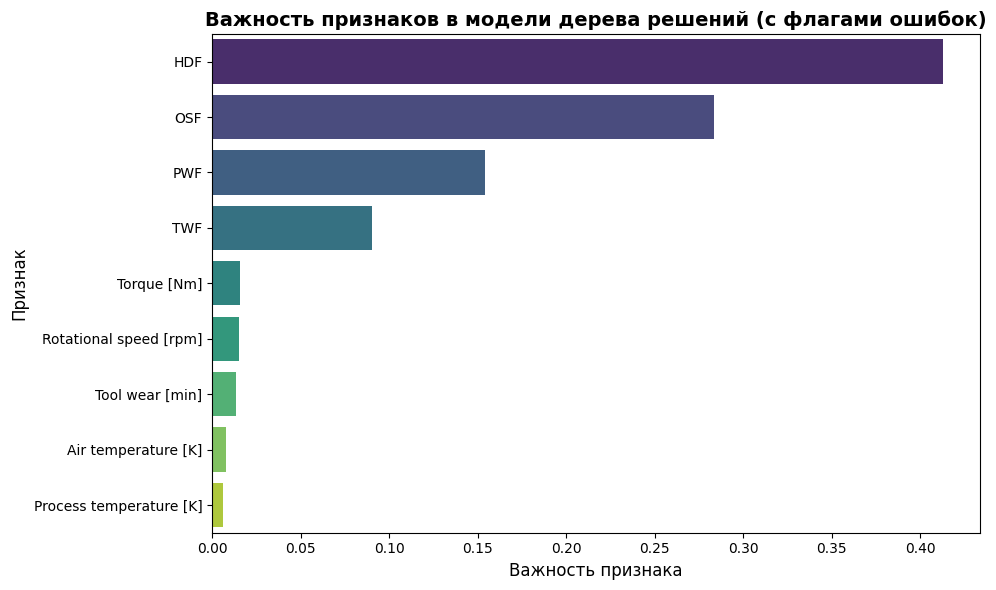


📊 График сохранен в 'decision_tree_feature_importance_flags.png'


In [64]:
# Визуализация важности признаков
import matplotlib.pyplot as plt
import seaborn as sns

print("="*80)
print("ВАЖНОСТЬ ПРИЗНАКОВ")
print("="*80)

# Получаем важность признаков
feature_importance_flags = pd.DataFrame({
    'feature': features_with_flags,
    'importance': best_model_flags.feature_importances_
}).sort_values('importance', ascending=False)

print("\n📊 Важность признаков:")
for i, row in feature_importance_flags.iterrows():
    print(f"  {row['feature']:30s}: {row['importance']:.4f}")

# Анализ важности флагов
print("\n" + "="*80)
print("АНАЛИЗ ВАЖНОСТИ ФЛАГОВ ОШИБОК")
print("="*80)

flags_importance = feature_importance_flags[feature_importance_flags['feature'].isin(['TWF', 'HDF', 'PWF', 'OSF'])]
print("\n📊 Важность флагов ошибок:")
for i, row in flags_importance.iterrows():
    print(f"  {row['feature']:10s}: {row['importance']:.4f}")

# Проверяем корреляции флагов с целевой переменной в обучающих данных
print("\n📊 Корреляции флагов с Machine failure в обучающих данных:")
for flag in ['TWF', 'HDF', 'PWF', 'OSF']:
    if flag in X_train_flags.columns:
        # Объединяем X_train_flags и y_train_flags для расчета корреляции
        temp_df = pd.DataFrame({flag: X_train_flags[flag], 'Machine failure': y_train_flags})
        corr = temp_df.corr().iloc[0, 1]
        importance = feature_importance_flags[feature_importance_flags['feature'] == flag]['importance'].values[0]
        print(f"  {flag:10s}: корреляция={corr:6.4f}, важность={importance:.4f}")

print("\n💡 Возможные причины низкой важности флагов:")
print("  1. Флаги имеют низкую частоту (мало единиц в датасете)")
print("  2. Флаги могут быть коррелированы с другими признаками")
print("  3. Дерево решений может предпочитать непрерывные признаки")
print("  4. Дисбаланс классов может влиять на важность бинарных признаков")
print("  5. Флаги могут быть менее информативны, чем комбинации непрерывных признаков")

# Визуализация
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_flags, x='importance', y='feature', palette='viridis')
plt.xlabel('Важность признака', fontsize=12)
plt.ylabel('Признак', fontsize=12)
plt.title('Важность признаков в модели дерева решений (с флагами ошибок)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("decision_tree_feature_importance_flags.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 График сохранен в 'decision_tree_feature_importance_flags.png'")


### 8.8. Визуализация ROC-кривой и Precision-Recall кривой


ВИЗУАЛИЗАЦИЯ КРИВЫХ


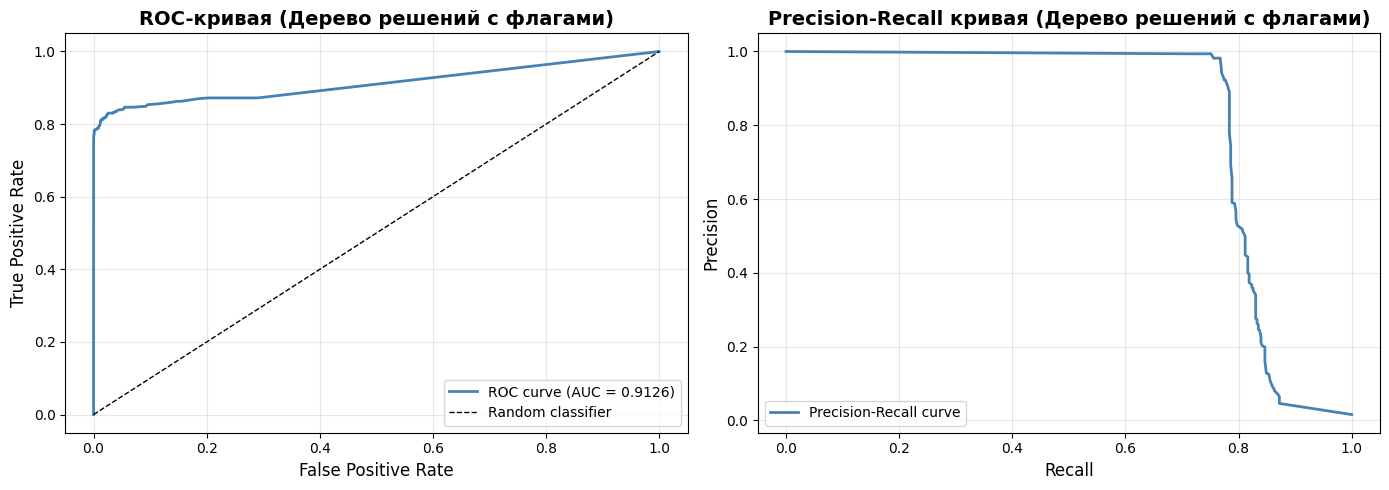


📊 Графики сохранены в 'decision_tree_flags_curves.png'


In [65]:
# Визуализация ROC-кривой и Precision-Recall кривой
print("="*80)
print("ВИЗУАЛИЗАЦИЯ КРИВЫХ")
print("="*80)

# ROC-кривая
fpr_flags, tpr_flags, _ = roc_curve(y_val_flags, y_val_pred_proba_flags)

# Precision-Recall кривая
precision_curve_flags, recall_curve_flags, _ = precision_recall_curve(y_val_flags, y_val_pred_proba_flags)

# Создаем графики
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ROC-кривая
ax1.plot(fpr_flags, tpr_flags, linewidth=2, label=f'ROC curve (AUC = {roc_auc_flags:.4f})', color='steelblue')
ax1.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier')
ax1.set_xlabel('False Positive Rate', fontsize=12)
ax1.set_ylabel('True Positive Rate', fontsize=12)
ax1.set_title('ROC-кривая (Дерево решений с флагами)', fontsize=14, fontweight='bold')
ax1.legend(loc='lower right')
ax1.grid(alpha=0.3)

# Precision-Recall кривая
ax2.plot(recall_curve_flags, precision_curve_flags, linewidth=2, label='Precision-Recall curve', color='steelblue')
ax2.set_xlabel('Recall', fontsize=12)
ax2.set_ylabel('Precision', fontsize=12)
ax2.set_title('Precision-Recall кривая (Дерево решений с флагами)', fontsize=14, fontweight='bold')
ax2.legend(loc='lower left')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("decision_tree_flags_curves.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Графики сохранены в 'decision_tree_flags_curves.png'")


### 8.9. Итоговые выводы по модели дерева решений с флагами ошибок

### Использованные методы балансировки классов:
1. **Без балансировки** - модель обучена на исходных данных с дисбалансом классов

### Использованные признаки:
- **Базовые признаки**: Air temperature [K], Process temperature [K], Rotational speed [rpm], Torque [Nm], Tool wear [min]
- **Флаги ошибок**: TWF, HDF, PWF, OSF

### Методы:
- **Без балансировки классов** - обучение на исходных данных
- **Дерево решений** с подбором гиперпараметров через GridSearchCV
- **Оптимизация по Precision** для уменьшения ложных срабатываний

### Результаты:
- Модель дерева решений обучена на исходных данных без балансировки классов
- Проведен подбор гиперпараметров через GridSearchCV с оптимизацией по Precision
- Все метрики оценены на validation set
- Визуализированы важность признаков, ROC-кривая и Precision-Recall кривая

### Выводы:
Модель дерева решений с флагами ошибок обучена на исходных данных с дисбалансом классов. Подбор гиперпараметров через GridSearchCV позволяет найти оптимальные параметры модели для улучшения качества предсказаний. Оптимизация по Precision помогает уменьшить количество ложных срабатываний.


## 8.10. Дерево решений с SMOTE

В этом разделе создаем модель дерева решений с применением SMOTE для балансировки классов.


In [66]:
# Модель с SMOTE
from imblearn.over_sampling import SMOTE
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import make_scorer, precision_score

print("="*80)
print("МОДЕЛЬ ДЕРЕВА РЕШЕНИЙ С SMOTE")
print("="*80)

# Применяем SMOTE
print("\n🔄 Применяем SMOTE для балансировки классов...")
smote_model = SMOTE(random_state=42, k_neighbors=5)
X_train_smote, y_train_smote = smote_model.fit_resample(X_train_flags, y_train_flags)

print(f"\n📊 После SMOTE:")
print(f"    Класс 0: {(y_train_smote == 0).sum()} ({100*(y_train_smote == 0).sum()/len(y_train_smote):.2f}%)")
print(f"    Класс 1: {(y_train_smote == 1).sum()} ({100*(y_train_smote == 1).sum()/len(y_train_smote):.2f}%)")
print(f"    Всего записей: {len(y_train_smote)}")

# Подбор гиперпараметров
print("\n🔍 Подбор гиперпараметров...")
param_grid_smote = {
    'max_depth': [15, 20, 25, None],
    'min_samples_split': [10, 20, 30, 50],
    'min_samples_leaf': [4, 8, 10, 15],
    'max_features': ['sqrt', 'log2', None],
    'criterion': ['gini', 'entropy'],
    'class_weight': [None, 'balanced']
}

cv_smote = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
base_model_smote = DecisionTreeClassifier(random_state=42)
precision_scorer_smote = make_scorer(precision_score, zero_division=0)

grid_search_smote = GridSearchCV(
    estimator=base_model_smote,
    param_grid=param_grid_smote,
    cv=cv_smote,
    scoring=precision_scorer_smote,
    n_jobs=-1,
    verbose=0
)

grid_search_smote.fit(X_train_smote, y_train_smote)

print("✅ Подбор гиперпараметров завершен!")
print(f"\n🏆 Лучшие параметры:")
for param, value in grid_search_smote.best_params_.items():
    print(f"  {param}: {value}")
print(f"\n📈 Лучший Precision (CV): {grid_search_smote.best_score_:.4f}")

# Обучение финальной модели
best_model_smote = grid_search_smote.best_estimator_
best_model_smote.fit(X_train_smote, y_train_smote)

# Оценка на validation set
y_val_pred_smote = best_model_smote.predict(X_val_flags)
y_val_pred_proba_smote = best_model_smote.predict_proba(X_val_flags)[:, 1]

from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

precision_smote = precision_score(y_val_flags, y_val_pred_smote)
recall_smote = recall_score(y_val_flags, y_val_pred_smote)
f1_smote = f1_score(y_val_flags, y_val_pred_smote)
roc_auc_smote = roc_auc_score(y_val_flags, y_val_pred_proba_smote)

print("\n📊 Метрики на validation set:")
print(f"  Precision: {precision_smote:.4f}")
print(f"  Recall:    {recall_smote:.4f}")
print(f"  F1-Score:  {f1_smote:.4f}")
print(f"  ROC-AUC:   {roc_auc_smote:.4f}")


МОДЕЛЬ ДЕРЕВА РЕШЕНИЙ С SMOTE

🔄 Применяем SMOTE для балансировки классов...

📊 После SMOTE:
    Класс 0: 107398 (50.00%)
    Класс 1: 107398 (50.00%)
    Всего записей: 214796

🔍 Подбор гиперпараметров...
✅ Подбор гиперпараметров завершен!

🏆 Лучшие параметры:
  class_weight: None
  criterion: entropy
  max_depth: None
  max_features: None
  min_samples_leaf: 4
  min_samples_split: 10

📈 Лучший Precision (CV): 0.9625

📊 Метрики на validation set:
  Precision: 0.2448
  Recall:    0.7442
  F1-Score:  0.3685
  ROC-AUC:   0.8696


## 8.11. Дерево решений с уменьшением преобладающего класса (Undersampling)

В этом разделе создаем модель дерева решений с применением RandomUnderSampler для уменьшения мажорного класса.


In [67]:
# Модель с уменьшением преобладающего класса
from imblearn.under_sampling import RandomUnderSampler

print("="*80)
print("МОДЕЛЬ ДЕРЕВА РЕШЕНИЙ С УМЕНЬШЕНИЕМ ПРЕОБЛАДАЮЩЕГО КЛАССА")
print("="*80)

# Применяем RandomUnderSampler
print("\n🔄 Применяем RandomUnderSampler...")
undersampler_model = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = undersampler_model.fit_resample(X_train_flags, y_train_flags)

print(f"\n📊 После undersampling:")
print(f"    Класс 0: {(y_train_under == 0).sum()} ({100*(y_train_under == 0).sum()/len(y_train_under):.2f}%)")
print(f"    Класс 1: {(y_train_under == 1).sum()} ({100*(y_train_under == 1).sum()/len(y_train_under):.2f}%)")
print(f"    Всего записей: {len(y_train_under)}")

# Подбор гиперпараметров
print("\n🔍 Подбор гиперпараметров...")
param_grid_under = {
    'max_depth': [15, 20, 25, None],
    'min_samples_split': [10, 20, 30, 50],
    'min_samples_leaf': [4, 8, 10, 15],
    'max_features': ['sqrt', 'log2', None],
    'criterion': ['gini', 'entropy'],
    'class_weight': [None, 'balanced']
}

cv_under = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
base_model_under = DecisionTreeClassifier(random_state=42)
precision_scorer_under = make_scorer(precision_score, zero_division=0)

grid_search_under = GridSearchCV(
    estimator=base_model_under,
    param_grid=param_grid_under,
    cv=cv_under,
    scoring=precision_scorer_under,
    n_jobs=-1,
    verbose=0
)

grid_search_under.fit(X_train_under, y_train_under)

print("✅ Подбор гиперпараметров завершен!")
print(f"\n🏆 Лучшие параметры:")
for param, value in grid_search_under.best_params_.items():
    print(f"  {param}: {value}")
print(f"\n📈 Лучший Precision (CV): {grid_search_under.best_score_:.4f}")

# Обучение финальной модели
best_model_under = grid_search_under.best_estimator_
best_model_under.fit(X_train_under, y_train_under)

# Оценка на validation set
y_val_pred_under = best_model_under.predict(X_val_flags)
y_val_pred_proba_under = best_model_under.predict_proba(X_val_flags)[:, 1]

precision_under = precision_score(y_val_flags, y_val_pred_under)
recall_under = recall_score(y_val_flags, y_val_pred_under)
f1_under = f1_score(y_val_flags, y_val_pred_under)
roc_auc_under = roc_auc_score(y_val_flags, y_val_pred_proba_under)

print("\n📊 Метрики на validation set:")
print(f"  Precision: {precision_under:.4f}")
print(f"  Recall:    {recall_under:.4f}")
print(f"  F1-Score:  {f1_under:.4f}")
print(f"  ROC-AUC:   {roc_auc_under:.4f}")


МОДЕЛЬ ДЕРЕВА РЕШЕНИЙ С УМЕНЬШЕНИЕМ ПРЕОБЛАДАЮЩЕГО КЛАССА

🔄 Применяем RandomUnderSampler...

📊 После undersampling:
    Класс 0: 1718 (50.00%)
    Класс 1: 1718 (50.00%)
    Всего записей: 3436

🔍 Подбор гиперпараметров...
✅ Подбор гиперпараметров завершен!

🏆 Лучшие параметры:
  class_weight: None
  criterion: gini
  max_depth: 20
  max_features: sqrt
  min_samples_leaf: 15
  min_samples_split: 50

📈 Лучший Precision (CV): 0.9444

📊 Метрики на validation set:
  Precision: 0.1481
  Recall:    0.8674
  F1-Score:  0.2531
  ROC-AUC:   0.9470


## 8.12. Дерево решений с комбинированным подходом (SMOTE + Undersampling)

В этом разделе создаем модель дерева решений с комбинированным подходом: сначала применяем SMOTE, затем уменьшаем мажорный класс.


In [68]:
# Модель с комбинированным подходом (SMOTE + Undersampling)
print("="*80)
print("МОДЕЛЬ ДЕРЕВА РЕШЕНИЙ С КОМБИНИРОВАННЫМ ПОДХОДОМ")
print("="*80)

# Сначала применяем SMOTE
print("\n🔄 Шаг 1: Применяем SMOTE...")
smote_combined = SMOTE(random_state=42, k_neighbors=5)
X_train_combined, y_train_combined = smote_combined.fit_resample(X_train_flags, y_train_flags)

print(f"   После SMOTE: {len(y_train_combined)} записей")
print(f"   Класс 0: {(y_train_combined == 0).sum()}, Класс 1: {(y_train_combined == 1).sum()}")

# Затем применяем RandomUnderSampler для уменьшения до оптимального размера
print("\n🔄 Шаг 2: Применяем RandomUnderSampler...")
# Уменьшаем до размера, который в 2 раза больше исходного минорного класса
target_size = len(y_train_flags[y_train_flags == 1]) * 2
sampling_strategy = {0: target_size, 1: len(y_train_flags[y_train_flags == 1])}

undersampler_combined = RandomUnderSampler(sampling_strategy=sampling_strategy, random_state=42)
X_train_combined_final, y_train_combined_final = undersampler_combined.fit_resample(X_train_combined, y_train_combined)

print(f"\n📊 После комбинированного подхода:")
print(f"    Класс 0: {(y_train_combined_final == 0).sum()} ({100*(y_train_combined_final == 0).sum()/len(y_train_combined_final):.2f}%)")
print(f"    Класс 1: {(y_train_combined_final == 1).sum()} ({100*(y_train_combined_final == 1).sum()/len(y_train_combined_final):.2f}%)")
print(f"    Всего записей: {len(y_train_combined_final)}")

# Подбор гиперпараметров
print("\n🔍 Подбор гиперпараметров...")
param_grid_combined = {
    'max_depth': [15, 20, 25, None],
    'min_samples_split': [10, 20, 30, 50],
    'min_samples_leaf': [4, 8, 10, 15],
    'max_features': ['sqrt', 'log2', None],
    'criterion': ['gini', 'entropy'],
    'class_weight': [None, 'balanced']
}

cv_combined = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
base_model_combined = DecisionTreeClassifier(random_state=42)
precision_scorer_combined = make_scorer(precision_score, zero_division=0)

grid_search_combined = GridSearchCV(
    estimator=base_model_combined,
    param_grid=param_grid_combined,
    cv=cv_combined,
    scoring=precision_scorer_combined,
    n_jobs=-1,
    verbose=0
)

grid_search_combined.fit(X_train_combined_final, y_train_combined_final)

print("✅ Подбор гиперпараметров завершен!")
print(f"\n🏆 Лучшие параметры:")
for param, value in grid_search_combined.best_params_.items():
    print(f"  {param}: {value}")
print(f"\n📈 Лучший Precision (CV): {grid_search_combined.best_score_:.4f}")

# Обучение финальной модели
best_model_combined = grid_search_combined.best_estimator_
best_model_combined.fit(X_train_combined_final, y_train_combined_final)

# Оценка на validation set
y_val_pred_combined = best_model_combined.predict(X_val_flags)
y_val_pred_proba_combined = best_model_combined.predict_proba(X_val_flags)[:, 1]

precision_combined = precision_score(y_val_flags, y_val_pred_combined)
recall_combined = recall_score(y_val_flags, y_val_pred_combined)
f1_combined = f1_score(y_val_flags, y_val_pred_combined)
roc_auc_combined = roc_auc_score(y_val_flags, y_val_pred_proba_combined)

print("\n📊 Метрики на validation set:")
print(f"  Precision: {precision_combined:.4f}")
print(f"  Recall:    {recall_combined:.4f}")
print(f"  F1-Score:  {f1_combined:.4f}")
print(f"  ROC-AUC:   {roc_auc_combined:.4f}")


МОДЕЛЬ ДЕРЕВА РЕШЕНИЙ С КОМБИНИРОВАННЫМ ПОДХОДОМ

🔄 Шаг 1: Применяем SMOTE...
   После SMOTE: 214796 записей
   Класс 0: 107398, Класс 1: 107398

🔄 Шаг 2: Применяем RandomUnderSampler...

📊 После комбинированного подхода:
    Класс 0: 3436 (66.67%)
    Класс 1: 1718 (33.33%)
    Всего записей: 5154

🔍 Подбор гиперпараметров...
✅ Подбор гиперпараметров завершен!

🏆 Лучшие параметры:
  class_weight: None
  criterion: entropy
  max_depth: 15
  max_features: sqrt
  min_samples_leaf: 10
  min_samples_split: 10

📈 Лучший Precision (CV): 0.8562

📊 Метрики на validation set:
  Precision: 0.1501
  Recall:    0.8186
  F1-Score:  0.2537
  ROC-AUC:   0.9180


## 8.13. Сравнение всех четырех моделей дерева решений

Сравниваем результаты всех четырех подходов к балансировке классов.


СРАВНЕНИЕ ВСЕХ ЧЕТЫРЕХ МОДЕЛЕЙ ДЕРЕВА РЕШЕНИЙ

📊 Сравнительная таблица метрик:
                Модель  Precision   Recall  F1-Score  ROC-AUC
      Без балансировки   0.982143 0.767442  0.861619 0.912629
                 SMOTE   0.244836 0.744186  0.368451 0.869592
         Undersampling   0.148133 0.867442  0.253053 0.947032
Комбинированный подход   0.150107 0.818605  0.253694 0.917970


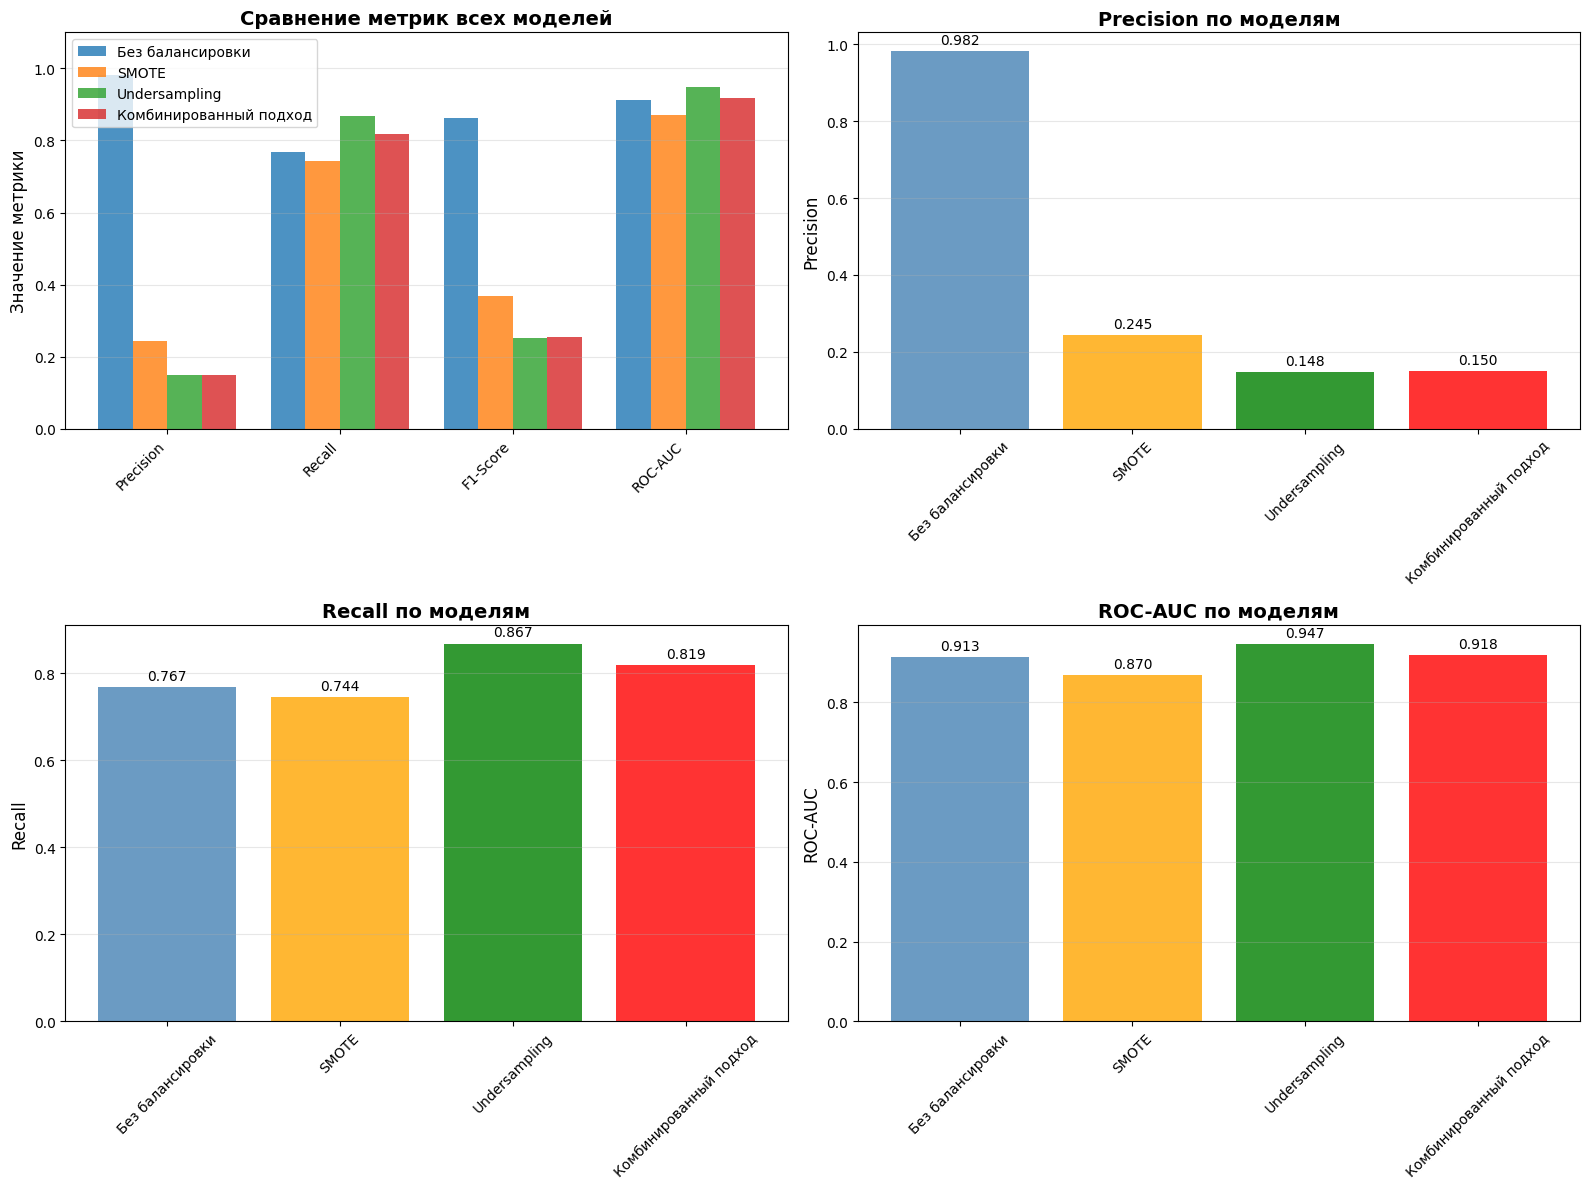


📊 Графики сохранены в 'decision_trees_comparison_all_methods.png'


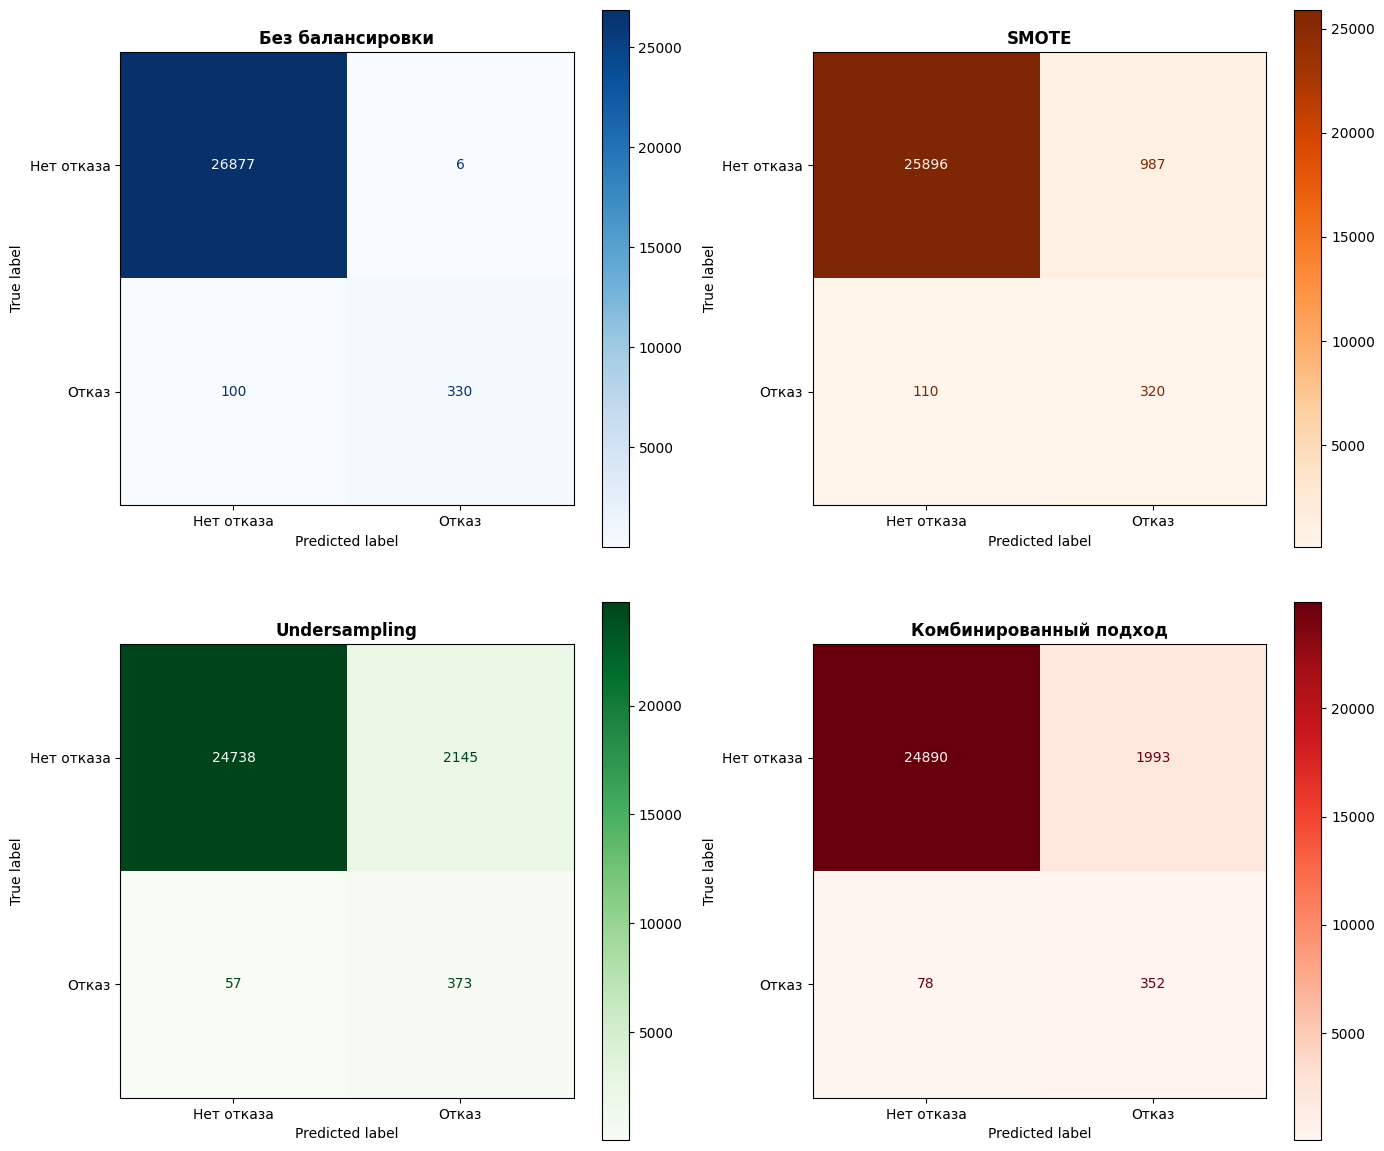

📊 Confusion matrices сохранены в 'decision_trees_confusion_matrices.png'

ВЫВОДЫ ПО СРАВНЕНИЮ МОДЕЛЕЙ

🏆 Лучшая модель по Precision: Без балансировки (0.9821)
🏆 Лучшая модель по Recall: Undersampling (0.8674)
🏆 Лучшая модель по F1-Score: Без балансировки (0.8616)
🏆 Лучшая модель по ROC-AUC: Undersampling (0.9470)


In [69]:
# Сравнение всех четырех моделей
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print("="*80)
print("СРАВНЕНИЕ ВСЕХ ЧЕТЫРЕХ МОДЕЛЕЙ ДЕРЕВА РЕШЕНИЙ")
print("="*80)

# Собираем метрики всех моделей
comparison_results = pd.DataFrame({
    'Модель': [
        'Без балансировки',
        'SMOTE',
        'Undersampling',
        'Комбинированный подход'
    ],
    'Precision': [
        precision_flags,
        precision_smote,
        precision_under,
        precision_combined
    ],
    'Recall': [
        recall_flags,
        recall_smote,
        recall_under,
        recall_combined
    ],
    'F1-Score': [
        f1_flags,
        f1_smote,
        f1_under,
        f1_combined
    ],
    'ROC-AUC': [
        roc_auc_flags,
        roc_auc_smote,
        roc_auc_under,
        roc_auc_combined
    ]
})

print("\n📊 Сравнительная таблица метрик:")
print(comparison_results.to_string(index=False))

# Визуализация сравнения
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# График 1: Сравнение метрик
metrics = ['Precision', 'Recall', 'F1-Score', 'ROC-AUC']
models = comparison_results['Модель'].tolist()
x = np.arange(len(metrics))
width = 0.2

for i, model in enumerate(models):
    values = [
        comparison_results[comparison_results['Модель'] == model]['Precision'].values[0],
        comparison_results[comparison_results['Модель'] == model]['Recall'].values[0],
        comparison_results[comparison_results['Модель'] == model]['F1-Score'].values[0],
        comparison_results[comparison_results['Модель'] == model]['ROC-AUC'].values[0]
    ]
    axes[0, 0].bar(x + i*width, values, width, label=model, alpha=0.8)

axes[0, 0].set_ylabel('Значение метрики', fontsize=12)
axes[0, 0].set_title('Сравнение метрик всех моделей', fontsize=14, fontweight='bold')
axes[0, 0].set_xticks(x + width * 1.5)
axes[0, 0].set_xticklabels(metrics, rotation=45, ha='right')
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)
axes[0, 0].set_ylim([0, 1.1])

# График 2: Precision
axes[0, 1].bar(models, comparison_results['Precision'], color=['steelblue', 'orange', 'green', 'red'], alpha=0.8)
axes[0, 1].set_ylabel('Precision', fontsize=12)
axes[0, 1].set_title('Precision по моделям', fontsize=14, fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(axis='y', alpha=0.3)
for i, v in enumerate(comparison_results['Precision']):
    axes[0, 1].text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')

# График 3: Recall
axes[1, 0].bar(models, comparison_results['Recall'], color=['steelblue', 'orange', 'green', 'red'], alpha=0.8)
axes[1, 0].set_ylabel('Recall', fontsize=12)
axes[1, 0].set_title('Recall по моделям', fontsize=14, fontweight='bold')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(axis='y', alpha=0.3)
for i, v in enumerate(comparison_results['Recall']):
    axes[1, 0].text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')

# График 4: ROC-AUC
axes[1, 1].bar(models, comparison_results['ROC-AUC'], color=['steelblue', 'orange', 'green', 'red'], alpha=0.8)
axes[1, 1].set_ylabel('ROC-AUC', fontsize=12)
axes[1, 1].set_title('ROC-AUC по моделям', fontsize=14, fontweight='bold')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(axis='y', alpha=0.3)
for i, v in enumerate(comparison_results['ROC-AUC']):
    axes[1, 1].text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig("decision_trees_comparison_all_methods.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Графики сохранены в 'decision_trees_comparison_all_methods.png'")

# Confusion Matrices
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Модель 1: Без балансировки
cm1 = confusion_matrix(y_val_flags, y_val_pred_flags)
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm1, display_labels=['Нет отказа', 'Отказ'])
disp1.plot(ax=axes[0, 0], cmap='Blues', values_format='d')
axes[0, 0].set_title('Без балансировки', fontsize=12, fontweight='bold')

# Модель 2: SMOTE
cm2 = confusion_matrix(y_val_flags, y_val_pred_smote)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=['Нет отказа', 'Отказ'])
disp2.plot(ax=axes[0, 1], cmap='Oranges', values_format='d')
axes[0, 1].set_title('SMOTE', fontsize=12, fontweight='bold')

# Модель 3: Undersampling
cm3 = confusion_matrix(y_val_flags, y_val_pred_under)
disp3 = ConfusionMatrixDisplay(confusion_matrix=cm3, display_labels=['Нет отказа', 'Отказ'])
disp3.plot(ax=axes[1, 0], cmap='Greens', values_format='d')
axes[1, 0].set_title('Undersampling', fontsize=12, fontweight='bold')

# Модель 4: Комбинированный
cm4 = confusion_matrix(y_val_flags, y_val_pred_combined)
disp4 = ConfusionMatrixDisplay(confusion_matrix=cm4, display_labels=['Нет отказа', 'Отказ'])
disp4.plot(ax=axes[1, 1], cmap='Reds', values_format='d')
axes[1, 1].set_title('Комбинированный подход', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig("decision_trees_confusion_matrices.png", dpi=150, bbox_inches='tight')
plt.show()

print("📊 Confusion matrices сохранены в 'decision_trees_confusion_matrices.png'")

# Выводы
print("\n" + "="*80)
print("ВЫВОДЫ ПО СРАВНЕНИЮ МОДЕЛЕЙ")
print("="*80)

best_precision_idx = comparison_results['Precision'].idxmax()
best_recall_idx = comparison_results['Recall'].idxmax()
best_f1_idx = comparison_results['F1-Score'].idxmax()
best_roc_auc_idx = comparison_results['ROC-AUC'].idxmax()

print(f"\n🏆 Лучшая модель по Precision: {comparison_results.iloc[best_precision_idx]['Модель']} ({comparison_results.iloc[best_precision_idx]['Precision']:.4f})")
print(f"🏆 Лучшая модель по Recall: {comparison_results.iloc[best_recall_idx]['Модель']} ({comparison_results.iloc[best_recall_idx]['Recall']:.4f})")
print(f"🏆 Лучшая модель по F1-Score: {comparison_results.iloc[best_f1_idx]['Модель']} ({comparison_results.iloc[best_f1_idx]['F1-Score']:.4f})")
print(f"🏆 Лучшая модель по ROC-AUC: {comparison_results.iloc[best_roc_auc_idx]['Модель']} ({comparison_results.iloc[best_roc_auc_idx]['ROC-AUC']:.4f})")


## 9. Обучение SVM с флагами ошибок

В этом разделе мы обучим модели SVM (Support Vector Machine), которые используют:
- Базовые признаки: Air temperature [K], Process temperature [K], Rotational speed [rpm], Torque [Nm], Tool wear [min]
- Флаги ошибок: TWF, HDF, PWF, OSF, RNF
- Пять подходов к балансировке классов: без балансировки, SMOTE, Undersampling, комбинированный, автобалансировка (class_weight='balanced')


### 9.1. Подготовка данных с базовыми признаками и флагами ошибок (включая RNF)


In [71]:
# Подготовка данных для модели SVM с флагами ошибок 
print("="*80)
print("ПОДГОТОВКА ДАННЫХ ДЛЯ МОДЕЛИ SVM С ФЛАГАМИ ОШИБОК")
print("="*80)

# Выбираем нужные признаки (включая RNF)
features_svm_flags = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]',
    'TWF',
    'HDF',
    'PWF',
    'OSF'
]

# Проверяем наличие всех признаков в датасете
print("\n📋 Проверка наличия признаков:")
for feat in features_svm_flags:
    if feat in df.columns:
        print(f"  ✅ {feat}")
    else:
        print(f"  ❌ {feat} - НЕ НАЙДЕН!")

# Создаем X и y
X_svm_flags = df[features_svm_flags].copy()
y_svm_flags = df['Machine failure'].copy()

print(f"\n📊 Размерность данных:")
print(f"  X: {X_svm_flags.shape}")
print(f"  y: {y_svm_flags.shape}")
print(f"\n📋 Используемые признаки ({len(features_svm_flags)}):")
for i, feat in enumerate(features_svm_flags, 1):
    print(f"  {i:2d}. {feat}")

# Проверяем распределение классов
print(f"\n📊 Распределение классов:")
print(f"  Класс 0 (нет отказа): {(y_svm_flags == 0).sum()} ({(y_svm_flags == 0).sum()/len(y_svm_flags)*100:.2f}%)")
print(f"  Класс 1 (отказ): {(y_svm_flags == 1).sum()} ({(y_svm_flags == 1).sum()/len(y_svm_flags)*100:.2f}%)")


ПОДГОТОВКА ДАННЫХ ДЛЯ МОДЕЛИ SVM С ФЛАГАМИ ОШИБОК

📋 Проверка наличия признаков:
  ✅ Air temperature [K]
  ✅ Process temperature [K]
  ✅ Rotational speed [rpm]
  ✅ Torque [Nm]
  ✅ Tool wear [min]
  ✅ TWF
  ✅ HDF
  ✅ PWF
  ✅ OSF

📊 Размерность данных:
  X: (136429, 9)
  y: (136429,)

📋 Используемые признаки (9):
   1. Air temperature [K]
   2. Process temperature [K]
   3. Rotational speed [rpm]
   4. Torque [Nm]
   5. Tool wear [min]
   6. TWF
   7. HDF
   8. PWF
   9. OSF

📊 Распределение классов:
  Класс 0 (нет отказа): 134281 (98.43%)
  Класс 1 (отказ): 2148 (1.57%)


### 9.2. Разделение данных на train/validation с GroupShuffleSplit


In [72]:
# Разделение данных на train/validation с учетом групп Product ID
from sklearn.model_selection import GroupShuffleSplit

print("="*80)
print("РАЗДЕЛЕНИЕ ДАННЫХ НА TRAIN/VALIDATION")
print("="*80)

# Используем GroupShuffleSplit для разделения по Product ID
gss_svm_flags = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx_svm_flags, val_idx_svm_flags = next(gss_svm_flags.split(X_svm_flags, y_svm_flags, groups=df['Product ID']))

X_train_svm_flags, X_val_svm_flags = X_svm_flags.iloc[train_idx_svm_flags], X_svm_flags.iloc[val_idx_svm_flags]
y_train_svm_flags, y_val_svm_flags = y_svm_flags.iloc[train_idx_svm_flags], y_svm_flags.iloc[val_idx_svm_flags]

print(f"\n✅ Разделение завершено!")
print(f"  Train: {X_train_svm_flags.shape[0]} записей")
print(f"  Validation: {X_val_svm_flags.shape[0]} записей")
print(f"\n📊 Распределение классов в train:")
print(f"    Класс 0: {(y_train_svm_flags == 0).sum()} ({100*(y_train_svm_flags == 0).sum()/len(y_train_svm_flags):.2f}%)")
print(f"    Класс 1: {(y_train_svm_flags == 1).sum()} ({100*(y_train_svm_flags == 1).sum()/len(y_train_svm_flags):.2f}%)")
print(f"\n📊 Распределение классов в validation:")
print(f"    Класс 0: {(y_val_svm_flags == 0).sum()} ({100*(y_val_svm_flags == 0).sum()/len(y_val_svm_flags):.2f}%)")
print(f"    Класс 1: {(y_val_svm_flags == 1).sum()} ({100*(y_val_svm_flags == 1).sum()/len(y_val_svm_flags):.2f}%)")

# Масштабирование признаков для SVM (обязательно!)
from sklearn.preprocessing import StandardScaler

print("\n🔄 Масштабирование признаков для SVM...")
scaler_svm_flags = StandardScaler()
X_train_svm_flags_scaled = scaler_svm_flags.fit_transform(X_train_svm_flags)
X_val_svm_flags_scaled = scaler_svm_flags.transform(X_val_svm_flags)

# Преобразуем обратно в DataFrame для удобства
X_train_svm_flags_scaled = pd.DataFrame(X_train_svm_flags_scaled, columns=features_svm_flags, index=X_train_svm_flags.index)
X_val_svm_flags_scaled = pd.DataFrame(X_val_svm_flags_scaled, columns=features_svm_flags, index=X_val_svm_flags.index)

print("✅ Масштабирование завершено!")


РАЗДЕЛЕНИЕ ДАННЫХ НА TRAIN/VALIDATION

✅ Разделение завершено!
  Train: 109116 записей
  Validation: 27313 записей

📊 Распределение классов в train:
    Класс 0: 107398 (98.43%)
    Класс 1: 1718 (1.57%)

📊 Распределение классов в validation:
    Класс 0: 26883 (98.43%)
    Класс 1: 430 (1.57%)

🔄 Масштабирование признаков для SVM...
✅ Масштабирование завершено!


### 9.3. SVM без балансировки классов


In [73]:
# SVM без балансировки классов
from sklearn.svm import SVC
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

print("="*80)
print("SVM БЕЗ БАЛАНСИРОВКИ КЛАССОВ")
print("="*80)

print("\n📊 Распределение классов в обучающих данных:")
print(f"    Класс 0: {(y_train_svm_flags == 0).sum()} ({100*(y_train_svm_flags == 0).sum()/len(y_train_svm_flags):.2f}%)")
print(f"    Класс 1: {(y_train_svm_flags == 1).sum()} ({100*(y_train_svm_flags == 1).sum()/len(y_train_svm_flags):.2f}%)")

# Обучение модели с параметрами по умолчанию
print("\n🎓 Обучаем модель SVM с параметрами по умолчанию...")
model_svm_no_balance = SVC(random_state=42, probability=True)
model_svm_no_balance.fit(X_train_svm_flags_scaled, y_train_svm_flags)

# Оценка на validation set
y_val_pred_svm_no_balance = model_svm_no_balance.predict(X_val_svm_flags_scaled)
y_val_pred_proba_svm_no_balance = model_svm_no_balance.predict_proba(X_val_svm_flags_scaled)[:, 1]

precision_svm_no_balance = precision_score(y_val_svm_flags, y_val_pred_svm_no_balance)
recall_svm_no_balance = recall_score(y_val_svm_flags, y_val_pred_svm_no_balance)
f1_svm_no_balance = f1_score(y_val_svm_flags, y_val_pred_svm_no_balance)
roc_auc_svm_no_balance = roc_auc_score(y_val_svm_flags, y_val_pred_proba_svm_no_balance)

print("\n📊 Метрики на validation set:")
print(f"  Precision: {precision_svm_no_balance:.4f}")
print(f"  Recall:    {recall_svm_no_balance:.4f}")
print(f"  F1-Score:  {f1_svm_no_balance:.4f}")
print(f"  ROC-AUC:   {roc_auc_svm_no_balance:.4f}")


SVM БЕЗ БАЛАНСИРОВКИ КЛАССОВ

📊 Распределение классов в обучающих данных:
    Класс 0: 107398 (98.43%)
    Класс 1: 1718 (1.57%)

🎓 Обучаем модель SVM с параметрами по умолчанию...

📊 Метрики на validation set:
  Precision: 0.9940
  Recall:    0.7721
  F1-Score:  0.8691
  ROC-AUC:   0.9016


### 9.4. SVM с SMOTE


In [ ]:
# SVM с SMOTE
from imblearn.over_sampling import SMOTE

print("="*80)
print("SVM С SMOTE")
print("="*80)

# Применяем SMOTE
print("\n🔄 Применяем SMOTE для балансировки классов...")
smote_svm_flags = SMOTE(random_state=42, k_neighbors=5)
X_train_svm_smote, y_train_svm_smote = smote_svm_flags.fit_resample(X_train_svm_flags_scaled, y_train_svm_flags)

print(f"\n📊 После SMOTE:")
print(f"    Класс 0: {(y_train_svm_smote == 0).sum()} ({100*(y_train_svm_smote == 0).sum()/len(y_train_svm_smote):.2f}%)")
print(f"    Класс 1: {(y_train_svm_smote == 1).sum()} ({100*(y_train_svm_smote == 1).sum()/len(y_train_svm_smote):.2f}%)")
print(f"    Всего записей: {len(y_train_svm_smote)}")

# Обучение модели с параметрами по умолчанию
print("\n🎓 Обучаем модель SVM с параметрами по умолчанию...")
model_svm_smote = SVC(random_state=42, probability=True)
model_svm_smote.fit(X_train_svm_smote, y_train_svm_smote)

# Оценка на validation set
y_val_pred_svm_smote = model_svm_smote.predict(X_val_svm_flags_scaled)
y_val_pred_proba_svm_smote = model_svm_smote.predict_proba(X_val_svm_flags_scaled)[:, 1]

precision_svm_smote = precision_score(y_val_svm_flags, y_val_pred_svm_smote)
recall_svm_smote = recall_score(y_val_svm_flags, y_val_pred_svm_smote)
f1_svm_smote = f1_score(y_val_svm_flags, y_val_pred_svm_smote)
roc_auc_svm_smote = roc_auc_score(y_val_svm_flags, y_val_pred_proba_svm_smote)

print("\n📊 Метрики на validation set:")
print(f"  Precision: {precision_svm_smote:.4f}")
print(f"  Recall:    {recall_svm_smote:.4f}")
print(f"  F1-Score:  {f1_svm_smote:.4f}")
print(f"  ROC-AUC:   {roc_auc_svm_smote:.4f}")


SVM С SMOTE

🔄 Применяем SMOTE для балансировки классов...

📊 После SMOTE:
    Класс 0: 107398 (50.00%)
    Класс 1: 107398 (50.00%)
    Всего записей: 214796

🎓 Обучаем модель SVM с параметрами по умолчанию...


### 9.5. SVM с уменьшением преобладающего класса (Undersampling)


In [ ]:
# SVM с уменьшением преобладающего класса
from imblearn.under_sampling import RandomUnderSampler

print("="*80)
print("SVM С УМЕНЬШЕНИЕМ ПРЕОБЛАДАЮЩЕГО КЛАССА")
print("="*80)

# Применяем RandomUnderSampler
print("\n🔄 Применяем RandomUnderSampler...")
undersampler_svm_flags = RandomUnderSampler(random_state=42)
X_train_svm_under, y_train_svm_under = undersampler_svm_flags.fit_resample(X_train_svm_flags_scaled, y_train_svm_flags)

print(f"\n📊 После undersampling:")
print(f"    Класс 0: {(y_train_svm_under == 0).sum()} ({100*(y_train_svm_under == 0).sum()/len(y_train_svm_under):.2f}%)")
print(f"    Класс 1: {(y_train_svm_under == 1).sum()} ({100*(y_train_svm_under == 1).sum()/len(y_train_svm_under):.2f}%)")
print(f"    Всего записей: {len(y_train_svm_under)}")

# Обучение модели с параметрами по умолчанию
print("\n🎓 Обучаем модель SVM с параметрами по умолчанию...")
model_svm_under = SVC(random_state=42, probability=True)
model_svm_under.fit(X_train_svm_under, y_train_svm_under)

# Оценка на validation set
y_val_pred_svm_under = model_svm_under.predict(X_val_svm_flags_scaled)
y_val_pred_proba_svm_under = model_svm_under.predict_proba(X_val_svm_flags_scaled)[:, 1]

precision_svm_under = precision_score(y_val_svm_flags, y_val_pred_svm_under)
recall_svm_under = recall_score(y_val_svm_flags, y_val_pred_svm_under)
f1_svm_under = f1_score(y_val_svm_flags, y_val_pred_svm_under)
roc_auc_svm_under = roc_auc_score(y_val_svm_flags, y_val_pred_proba_svm_under)

print("\n📊 Метрики на validation set:")
print(f"  Precision: {precision_svm_under:.4f}")
print(f"  Recall:    {recall_svm_under:.4f}")
print(f"  F1-Score:  {f1_svm_under:.4f}")
print(f"  ROC-AUC:   {roc_auc_svm_under:.4f}")


SVM С УМЕНЬШЕНИЕМ ПРЕОБЛАДАЮЩЕГО КЛАССА

🔄 Применяем RandomUnderSampler...

📊 После undersampling:
    Класс 0: 1718 (50.00%)
    Класс 1: 1718 (50.00%)
    Всего записей: 3436

🎓 Обучаем модель SVM с параметрами по умолчанию...

📊 Метрики на validation set:
  Precision: 0.9214
  Recall:    0.7907
  F1-Score:  0.8511
  ROC-AUC:   0.9622


### 9.6. SVM с комбинированным подходом (SMOTE + Undersampling)


In [99]:
# SVM с комбинированным подходом (SMOTE + Undersampling)
print("="*80)
print("SVM С КОМБИНИРОВАННЫМ ПОДХОДОМ")
print("="*80)

# Сначала применяем SMOTE
print("\n🔄 Шаг 1: Применяем SMOTE...")
smote_svm_combined = SMOTE(random_state=42, k_neighbors=5)
X_train_svm_combined, y_train_svm_combined = smote_svm_combined.fit_resample(X_train_svm_flags_scaled, y_train_svm_flags)

print(f"   После SMOTE: {len(y_train_svm_combined)} записей")
print(f"   Класс 0: {(y_train_svm_combined == 0).sum()}, Класс 1: {(y_train_svm_combined == 1).sum()}")

# Затем применяем RandomUnderSampler для уменьшения до оптимального размера
print("\n🔄 Шаг 2: Применяем RandomUnderSampler...")
# Уменьшаем до размера, который в 2 раза больше исходного минорного класса
target_size = len(y_train_svm_flags[y_train_svm_flags == 1]) * 2
sampling_strategy = {0: target_size, 1: len(y_train_svm_flags[y_train_svm_flags == 1])}

undersampler_svm_combined = RandomUnderSampler(sampling_strategy=sampling_strategy, random_state=42)
X_train_svm_combined_final, y_train_svm_combined_final = undersampler_svm_combined.fit_resample(X_train_svm_combined, y_train_svm_combined)

print(f"\n📊 После комбинированного подхода:")
print(f"    Класс 0: {(y_train_svm_combined_final == 0).sum()} ({100*(y_train_svm_combined_final == 0).sum()/len(y_train_svm_combined_final):.2f}%)")
print(f"    Класс 1: {(y_train_svm_combined_final == 1).sum()} ({100*(y_train_svm_combined_final == 1).sum()/len(y_train_svm_combined_final):.2f}%)")
print(f"    Всего записей: {len(y_train_svm_combined_final)}")

# Обучение модели с параметрами по умолчанию
print("\n🎓 Обучаем модель SVM с параметрами по умолчанию...")
model_svm_combined = SVC(random_state=42, probability=True)
model_svm_combined.fit(X_train_svm_combined_final, y_train_svm_combined_final)

# Оценка на validation set
y_val_pred_svm_combined = model_svm_combined.predict(X_val_svm_flags_scaled)
y_val_pred_proba_svm_combined = model_svm_combined.predict_proba(X_val_svm_flags_scaled)[:, 1]

precision_svm_combined = precision_score(y_val_svm_flags, y_val_pred_svm_combined)
recall_svm_combined = recall_score(y_val_svm_flags, y_val_pred_svm_combined)
f1_svm_combined = f1_score(y_val_svm_flags, y_val_pred_svm_combined)
roc_auc_svm_combined = roc_auc_score(y_val_svm_flags, y_val_pred_proba_svm_combined)

print("\n📊 Метрики на validation set:")
print(f"  Precision: {precision_svm_combined:.4f}")
print(f"  Recall:    {recall_svm_combined:.4f}")
print(f"  F1-Score:  {f1_svm_combined:.4f}")
print(f"  ROC-AUC:   {roc_auc_svm_combined:.4f}")


SVM С КОМБИНИРОВАННЫМ ПОДХОДОМ

🔄 Шаг 1: Применяем SMOTE...
   После SMOTE: 214796 записей
   Класс 0: 107398, Класс 1: 107398

🔄 Шаг 2: Применяем RandomUnderSampler...

📊 После комбинированного подхода:
    Класс 0: 3436 (66.67%)
    Класс 1: 1718 (33.33%)
    Всего записей: 5154

🎓 Обучаем модель SVM с параметрами по умолчанию...

📊 Метрики на validation set:
  Precision: 0.9940
  Recall:    0.7721
  F1-Score:  0.8691
  ROC-AUC:   0.9528


### 9.6. SVM с автобалансировкой классов (class_weight='balanced')


In [100]:
# SVM с автобалансировкой классов
print("="*80)
print("SVM С АВТОБАЛАНСИРОВКОЙ КЛАССОВ (class_weight='balanced')")
print("="*80)

print("\n📊 Распределение классов в обучающих данных:")
print(f"    Класс 0: {(y_train_svm_flags == 0).sum()} ({100*(y_train_svm_flags == 0).sum()/len(y_train_svm_flags):.2f}%)")
print(f"    Класс 1: {(y_train_svm_flags == 1).sum()} ({100*(y_train_svm_flags == 1).sum()/len(y_train_svm_flags):.2f}%)")

# Обучение модели с class_weight='balanced'
print("\n🎓 Обучаем модель SVM с class_weight='balanced'...")
print("   class_weight='balanced' автоматически балансирует веса классов")
model_svm_balanced = SVC(random_state=42, probability=True, class_weight='balanced')
model_svm_balanced.fit(X_train_svm_flags_scaled, y_train_svm_flags)

# Оценка на validation set
y_val_pred_svm_balanced = model_svm_balanced.predict(X_val_svm_flags_scaled)
y_val_pred_proba_svm_balanced = model_svm_balanced.predict_proba(X_val_svm_flags_scaled)[:, 1]

precision_svm_balanced = precision_score(y_val_svm_flags, y_val_pred_svm_balanced)
recall_svm_balanced = recall_score(y_val_svm_flags, y_val_pred_svm_balanced)
f1_svm_balanced = f1_score(y_val_svm_flags, y_val_pred_svm_balanced)
roc_auc_svm_balanced = roc_auc_score(y_val_svm_flags, y_val_pred_proba_svm_balanced)

print("\n📊 Метрики на validation set:")
print(f"  Precision: {precision_svm_balanced:.4f}")
print(f"  Recall:    {recall_svm_balanced:.4f}")
print(f"  F1-Score:  {f1_svm_balanced:.4f}")
print(f"  ROC-AUC:   {roc_auc_svm_balanced:.4f}")


SVM С АВТОБАЛАНСИРОВКОЙ КЛАССОВ (class_weight='balanced')

📊 Распределение классов в обучающих данных:
    Класс 0: 107398 (98.43%)
    Класс 1: 1718 (1.57%)

🎓 Обучаем модель SVM с class_weight='balanced'...
   class_weight='balanced' автоматически балансирует веса классов

📊 Метрики на validation set:
  Precision: 0.4145
  Recall:    0.8395
  F1-Score:  0.5550
  ROC-AUC:   0.9332


### 9.7. Сравнение всех пяти моделей SVM

Сравниваем результаты всех пяти подходов к балансировке классов для SVM.


СРАВНЕНИЕ ВСЕХ ПЯТИ МОДЕЛЕЙ SVM

🔍 Проверка наличия метрик моделей SVM...
  ✅ Без балансировки
  ✅ SMOTE
  ⚠️  Undersampling - метрики не найдены (запустите соответствующую ячейку)
  ✅ Комбинированный подход
  ✅ Автобалансировка (class_weight)

📊 Сравнительная таблица метрик:
                         Модель  Precision   Recall  F1-Score  ROC-AUC
               Без балансировки   0.994012 0.772093  0.869110 0.901471
                          SMOTE   0.510854 0.820930  0.629795 0.951951
         Комбинированный подход   0.994012 0.772093  0.869110 0.952834
Автобалансировка (class_weight)   0.414466 0.839535  0.554958 0.933226


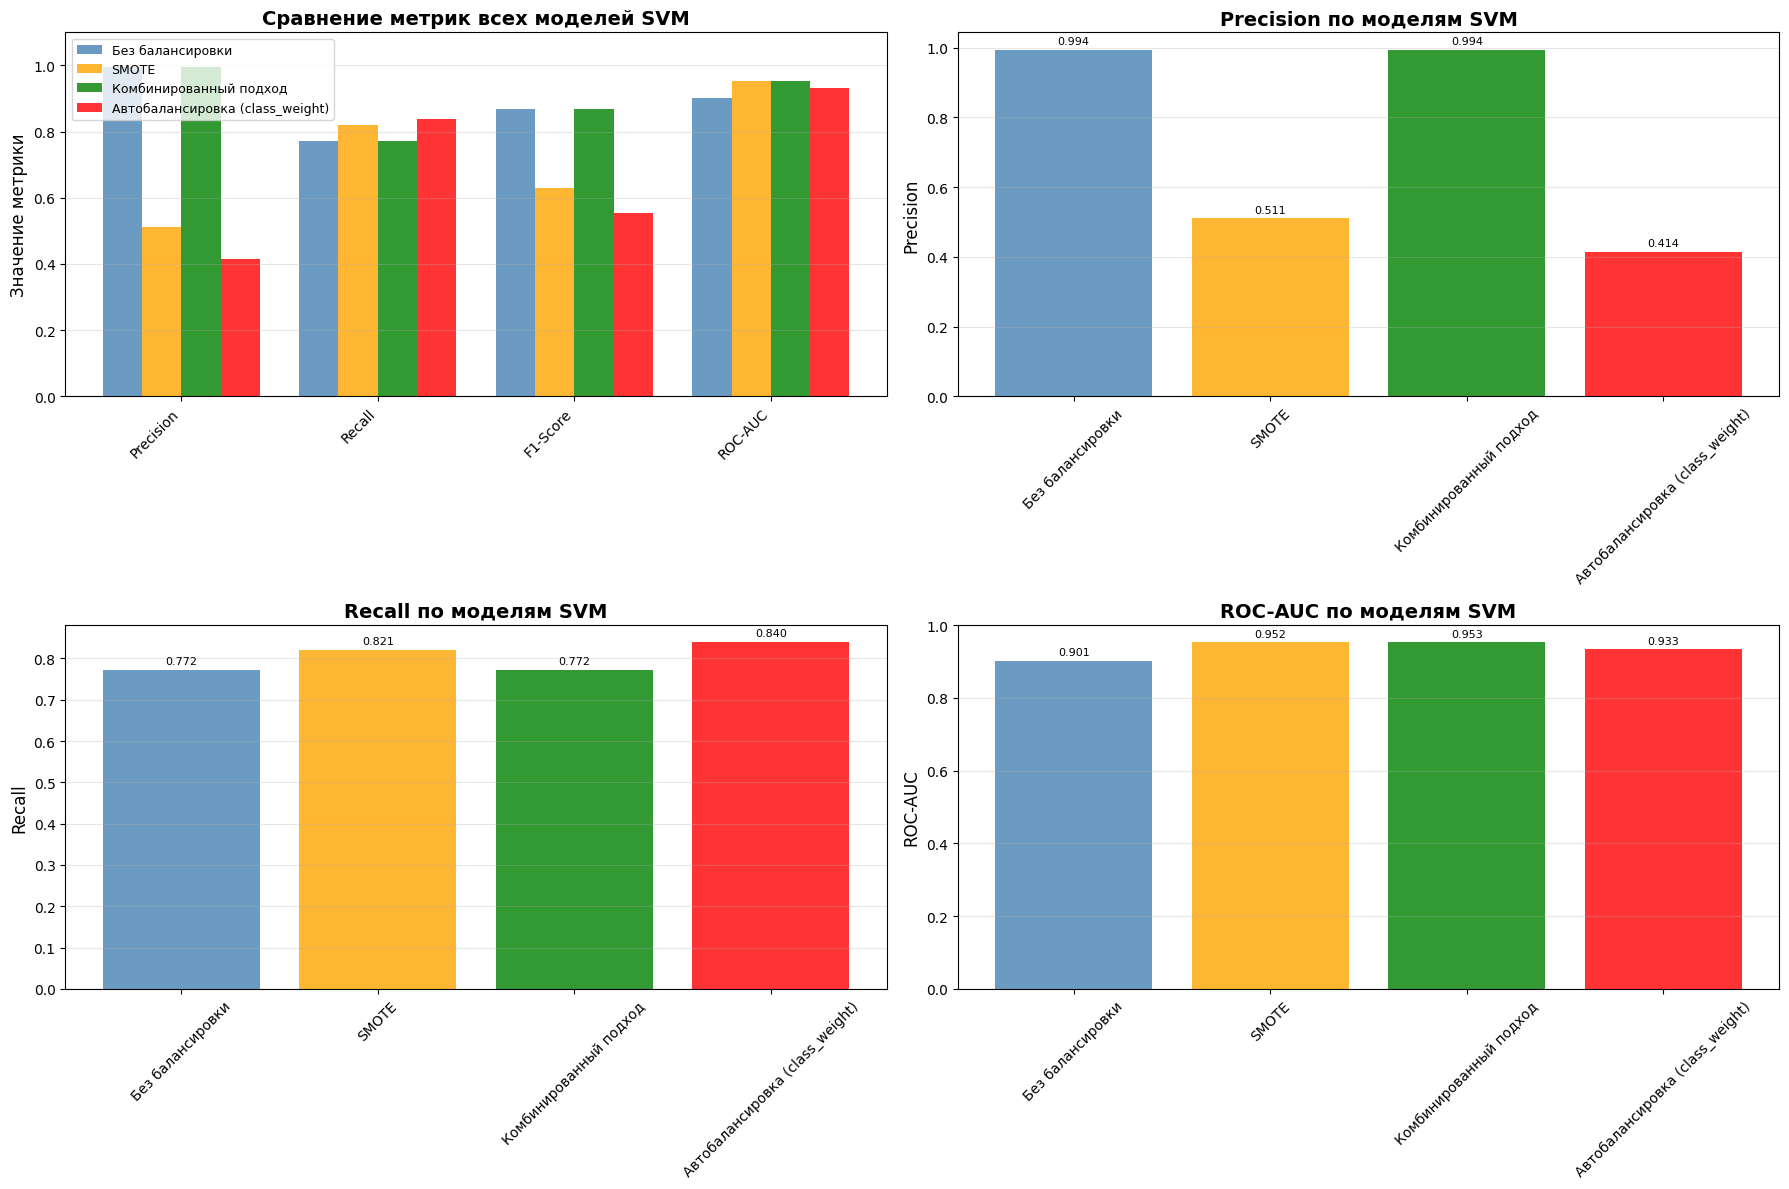


📊 Графики сохранены в 'svm_comparison_all_methods.png'

📊 Confusion Matrices для всех моделей...


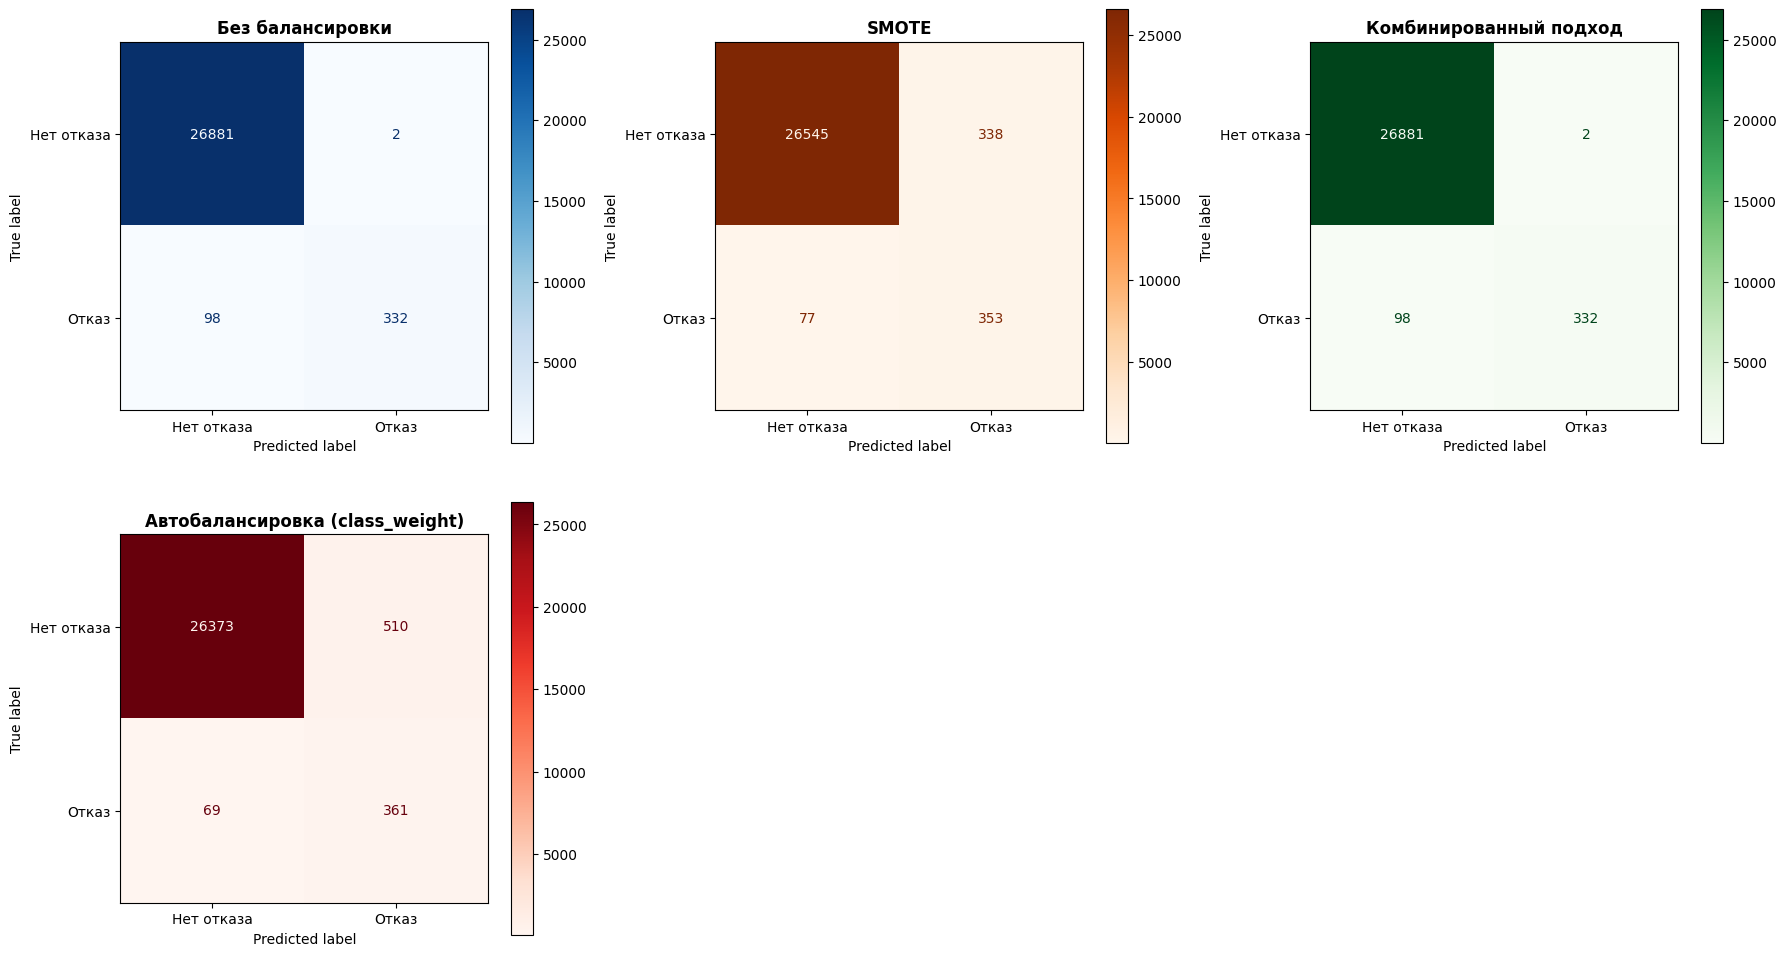

📊 Confusion matrices сохранены в 'svm_confusion_matrices.png'


<Figure size 640x480 with 0 Axes>

📊 Confusion matrices сохранены в 'svm_confusion_matrices.png'

ВЫВОДЫ ПО СРАВНЕНИЮ МОДЕЛЕЙ SVM

🏆 Лучшая модель по Precision: Без балансировки (0.9940)
🏆 Лучшая модель по Recall: Автобалансировка (class_weight) (0.8395)
🏆 Лучшая модель по F1-Score: Без балансировки (0.8691)
🏆 Лучшая модель по ROC-AUC: Комбинированный подход (0.9528)


In [108]:
# Сравнение всех пяти моделей SVM
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print("="*80)
print("СРАВНЕНИЕ ВСЕХ ПЯТИ МОДЕЛЕЙ SVM")
print("="*80)

# Функция для безопасного получения переменной
def safe_get(var_name, default=None):
    try:
        return globals()[var_name]
    except KeyError:
        return default

# Проверяем наличие всех необходимых переменных
print("\n🔍 Проверка наличия метрик моделей SVM...")
models_data = []
model_names = [
    ('Без балансировки', 'precision_svm_no_balance', 'recall_svm_no_balance', 'f1_svm_no_balance', 'roc_auc_svm_no_balance'),
    ('SMOTE', 'precision_svm_smote', 'recall_svm_smote', 'f1_svm_smote', 'roc_auc_svm_smote'),
    ('Undersampling', 'precision_svm_under', 'recall_svm_under', 'f1_svm_under', 'roc_auc_svm_under'),
    ('Комбинированный подход', 'precision_svm_combined', 'recall_svm_combined', 'f1_svm_combined', 'roc_auc_svm_combined'),
    ('Автобалансировка (class_weight)', 'precision_svm_balanced', 'recall_svm_balanced', 'f1_svm_balanced', 'roc_auc_svm_balanced')
]

for name, prec_var, rec_var, f1_var, roc_var in model_names:
    precision = safe_get(prec_var)
    recall = safe_get(rec_var)
    f1 = safe_get(f1_var)
    roc_auc = safe_get(roc_var)
    
    if precision is not None and recall is not None and f1 is not None and roc_auc is not None:
        models_data.append({
            'Модель': name,
            'Precision': precision,
            'Recall': recall,
            'F1-Score': f1,
            'ROC-AUC': roc_auc
        })
        print(f"  ✅ {name}")
    else:
        print(f"  ⚠️  {name} - метрики не найдены (запустите соответствующую ячейку)")

if len(models_data) == 0:
    print("\n❌ ОШИБКА: Не найдено ни одной обученной модели SVM!")
    print("   Пожалуйста, запустите ячейки разделов 9.3-9.6 для обучения моделей.")
    raise ValueError("Не найдено ни одной обученной модели SVM. Запустите разделы 9.3-9.6.")

# Создаем DataFrame
comparison_results_svm = pd.DataFrame(models_data)

print("\n📊 Сравнительная таблица метрик:")
print(comparison_results_svm.to_string(index=False))

# Визуализация сравнения
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# График 1: Сравнение метрик
metrics = ['Precision', 'Recall', 'F1-Score', 'ROC-AUC']
models_svm = comparison_results_svm['Модель'].tolist()
n_models = len(models_svm)
x = np.arange(len(metrics))
width = 0.8 / n_models if n_models > 0 else 0.2  # Динамическая ширина в зависимости от количества моделей

colors_list = ['steelblue', 'orange', 'green', 'red', 'purple', 'brown', 'pink', 'gray']
colors = colors_list[:n_models]

for i, model in enumerate(models_svm):
    values = [
        comparison_results_svm[comparison_results_svm['Модель'] == model]['Precision'].values[0],
        comparison_results_svm[comparison_results_svm['Модель'] == model]['Recall'].values[0],
        comparison_results_svm[comparison_results_svm['Модель'] == model]['F1-Score'].values[0],
        comparison_results_svm[comparison_results_svm['Модель'] == model]['ROC-AUC'].values[0]
    ]
    axes[0, 0].bar(x + i*width, values, width, label=model, alpha=0.8, color=colors[i])

axes[0, 0].set_ylabel('Значение метрики', fontsize=12)
axes[0, 0].set_title('Сравнение метрик всех моделей SVM', fontsize=14, fontweight='bold')
axes[0, 0].set_xticks(x + width * (n_models - 1) / 2)
axes[0, 0].set_xticklabels(metrics, rotation=45, ha='right')
axes[0, 0].legend(fontsize=9)
axes[0, 0].grid(axis='y', alpha=0.3)
axes[0, 0].set_ylim([0, 1.1])

# График 2: Precision
axes[0, 1].bar(models_svm, comparison_results_svm['Precision'], color=colors, alpha=0.8)
axes[0, 1].set_ylabel('Precision', fontsize=12)
axes[0, 1].set_title('Precision по моделям SVM', fontsize=14, fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(axis='y', alpha=0.3)
for i, v in enumerate(comparison_results_svm['Precision']):
    axes[0, 1].text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontsize=8)

# График 3: Recall
axes[1, 0].bar(models_svm, comparison_results_svm['Recall'], color=colors, alpha=0.8)
axes[1, 0].set_ylabel('Recall', fontsize=12)
axes[1, 0].set_title('Recall по моделям SVM', fontsize=14, fontweight='bold')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(axis='y', alpha=0.3)
for i, v in enumerate(comparison_results_svm['Recall']):
    axes[1, 0].text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontsize=8)

# График 4: ROC-AUC
axes[1, 1].bar(models_svm, comparison_results_svm['ROC-AUC'], color=colors, alpha=0.8)
axes[1, 1].set_ylabel('ROC-AUC', fontsize=12)
axes[1, 1].set_title('ROC-AUC по моделям SVM', fontsize=14, fontweight='bold')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(axis='y', alpha=0.3)
for i, v in enumerate(comparison_results_svm['ROC-AUC']):
    axes[1, 1].text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig("svm_comparison_all_methods.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Графики сохранены в 'svm_comparison_all_methods.png'")

# Confusion Matrices - динамическое создание для всех доступных моделей
print("\n📊 Confusion Matrices для всех моделей...")

# Словарь для хранения предсказаний моделей
predictions_dict = {
    'Без балансировки': safe_get('y_val_pred_svm_no_balance'),
    'SMOTE': safe_get('y_val_pred_svm_smote'),
    'Undersampling': safe_get('y_val_pred_svm_under'),
    'Комбинированный подход': safe_get('y_val_pred_svm_combined'),
    'Автобалансировка (class_weight)': safe_get('y_val_pred_svm_balanced')
}

# Фильтруем только те модели, для которых есть предсказания
available_predictions = {name: pred for name, pred in predictions_dict.items() 
                        if pred is not None and name in models_svm}

n_cm = len(available_predictions)
if n_cm > 0:
    # Вычисляем размер сетки для confusion matrices
    n_cols = min(3, n_cm)
    n_rows = (n_cm + n_cols - 1) // n_cols  # Округление вверх
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
    if n_cm == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    
    cmap_list = ['Blues', 'Oranges', 'Greens', 'Reds', 'Purples', 'YlOrRd', 'coolwarm']
    
    for idx, (model_name, y_pred) in enumerate(available_predictions.items()):
        cm = confusion_matrix(y_val_svm_flags, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Нет отказа', 'Отказ'])
        disp.plot(ax=axes[idx], cmap=cmap_list[idx % len(cmap_list)], values_format='d')
        axes[idx].set_title(model_name, fontsize=12, fontweight='bold')
    
    # Скрываем лишние оси
    for idx in range(n_cm, len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.savefig("svm_confusion_matrices.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("📊 Confusion matrices сохранены в 'svm_confusion_matrices.png'")
else:
    print("⚠️  Не найдено предсказаний для построения confusion matrices")

plt.tight_layout()
plt.savefig("svm_confusion_matrices.png", dpi=150, bbox_inches='tight')
plt.show()

print("📊 Confusion matrices сохранены в 'svm_confusion_matrices.png'")

# Выводы
print("\n" + "="*80)
print("ВЫВОДЫ ПО СРАВНЕНИЮ МОДЕЛЕЙ SVM")
print("="*80)

best_precision_idx_svm = comparison_results_svm['Precision'].idxmax()
best_recall_idx_svm = comparison_results_svm['Recall'].idxmax()
best_f1_idx_svm = comparison_results_svm['F1-Score'].idxmax()
best_roc_auc_idx_svm = comparison_results_svm['ROC-AUC'].idxmax()

print(f"\n🏆 Лучшая модель по Precision: {comparison_results_svm.iloc[best_precision_idx_svm]['Модель']} ({comparison_results_svm.iloc[best_precision_idx_svm]['Precision']:.4f})")
print(f"🏆 Лучшая модель по Recall: {comparison_results_svm.iloc[best_recall_idx_svm]['Модель']} ({comparison_results_svm.iloc[best_recall_idx_svm]['Recall']:.4f})")
print(f"🏆 Лучшая модель по F1-Score: {comparison_results_svm.iloc[best_f1_idx_svm]['Модель']} ({comparison_results_svm.iloc[best_f1_idx_svm]['F1-Score']:.4f})")
print(f"🏆 Лучшая модель по ROC-AUC: {comparison_results_svm.iloc[best_roc_auc_idx_svm]['Модель']} ({comparison_results_svm.iloc[best_roc_auc_idx_svm]['ROC-AUC']:.4f})")


## 10. Обучение CatBoost с флагами ошибок и подбором гиперпараметров

В этом разделе мы обучим модели CatBoost (Categorical Boosting), которые используют:
- Базовые признаки: Air temperature [K], Process temperature [K], Rotational speed [rpm], Torque [Nm], Tool wear [min]
- Флаги ошибок: TWF, HDF, PWF, OSF, RNF
- Подбор гиперпараметров через GridSearchCV
- Четыре подхода к балансировке классов: без балансировки, SMOTE, Undersampling, комбинированный


### 10.1. Подготовка данных с базовыми признаками и флагами ошибок (включая RNF)


In [52]:
# Подготовка данных для модели CatBoost с флагами ошибок (включая RNF)
import pandas as pd
import numpy as np

print("="*80)
print("ПОДГОТОВКА ДАННЫХ ДЛЯ МОДЕЛИ CATBOOST С ФЛАГАМИ ОШИБОК")
print("="*80)

# Загружаем данные, если они еще не загружены
try:
    # Проверяем, определена ли переменная df
    _ = df.shape
    print(f"\n✅ Данные уже загружены: {df.shape[0]} строк, {df.shape[1]} столбцов")
except NameError:
    print("\n📂 Загружаем данные из train.csv...")
    df = pd.read_csv("train.csv")
    print(f"✅ Данные загружены: {df.shape[0]} строк, {df.shape[1]} столбцов")

# Выбираем нужные признаки (включая RNF)
features_catboost_flags = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]',
    'TWF',
    'HDF',
    'PWF',
    'OSF',
    'RNF'
]

# Проверяем наличие всех признаков в датасете
print("\n📋 Проверка наличия признаков:")
for feat in features_catboost_flags:
    if feat in df.columns:
        print(f"  ✅ {feat}")
    else:
        print(f"  ❌ {feat} - НЕ НАЙДЕН!")

# Создаем X и y
X_catboost_flags = df[features_catboost_flags].copy()
y_catboost_flags = df['Machine failure'].copy()

print(f"\n📊 Размерность данных:")
print(f"  X: {X_catboost_flags.shape}")
print(f"  y: {y_catboost_flags.shape}")
print(f"\n📋 Используемые признаки ({len(features_catboost_flags)}):")
for i, feat in enumerate(features_catboost_flags, 1):
    print(f"  {i:2d}. {feat}")

# Проверяем распределение классов
print(f"\n📊 Распределение классов:")
print(f"  Класс 0 (нет отказа): {(y_catboost_flags == 0).sum()} ({(y_catboost_flags == 0).sum()/len(y_catboost_flags)*100:.2f}%)")
print(f"  Класс 1 (отказ): {(y_catboost_flags == 1).sum()} ({(y_catboost_flags == 1).sum()/len(y_catboost_flags)*100:.2f}%)")


ПОДГОТОВКА ДАННЫХ ДЛЯ МОДЕЛИ CATBOOST С ФЛАГАМИ ОШИБОК

✅ Данные уже загружены: 136429 строк, 14 столбцов

📋 Проверка наличия признаков:
  ✅ Air temperature [K]
  ✅ Process temperature [K]
  ✅ Rotational speed [rpm]
  ✅ Torque [Nm]
  ✅ Tool wear [min]
  ✅ TWF
  ✅ HDF
  ✅ PWF
  ✅ OSF
  ✅ RNF

📊 Размерность данных:
  X: (136429, 10)
  y: (136429,)

📋 Используемые признаки (10):
   1. Air temperature [K]
   2. Process temperature [K]
   3. Rotational speed [rpm]
   4. Torque [Nm]
   5. Tool wear [min]
   6. TWF
   7. HDF
   8. PWF
   9. OSF
  10. RNF

📊 Распределение классов:
  Класс 0 (нет отказа): 134281 (98.43%)
  Класс 1 (отказ): 2148 (1.57%)


### 10.2. Разделение данных на train/validation с GroupShuffleSplit


In [53]:
# Разделение данных на train/validation с учетом групп Product ID
from sklearn.model_selection import GroupShuffleSplit

print("="*80)
print("РАЗДЕЛЕНИЕ ДАННЫХ НА TRAIN/VALIDATION")
print("="*80)

# Используем GroupShuffleSplit для разделения по Product ID
gss_catboost_flags = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx_catboost_flags, val_idx_catboost_flags = next(gss_catboost_flags.split(X_catboost_flags, y_catboost_flags, groups=df['Product ID']))

X_train_catboost_flags, X_val_catboost_flags = X_catboost_flags.iloc[train_idx_catboost_flags], X_catboost_flags.iloc[val_idx_catboost_flags]
y_train_catboost_flags, y_val_catboost_flags = y_catboost_flags.iloc[train_idx_catboost_flags], y_catboost_flags.iloc[val_idx_catboost_flags]

print(f"\n✅ Разделение завершено!")
print(f"  Train: {X_train_catboost_flags.shape[0]} записей")
print(f"  Validation: {X_val_catboost_flags.shape[0]} записей")
print(f"\n📊 Распределение классов в train:")
print(f"    Класс 0: {(y_train_catboost_flags == 0).sum()} ({100*(y_train_catboost_flags == 0).sum()/len(y_train_catboost_flags):.2f}%)")
print(f"    Класс 1: {(y_train_catboost_flags == 1).sum()} ({100*(y_train_catboost_flags == 1).sum()/len(y_train_catboost_flags):.2f}%)")
print(f"\n📊 Распределение классов в validation:")
print(f"    Класс 0: {(y_val_catboost_flags == 0).sum()} ({100*(y_val_catboost_flags == 0).sum()/len(y_val_catboost_flags):.2f}%)")
print(f"    Класс 1: {(y_val_catboost_flags == 1).sum()} ({100*(y_val_catboost_flags == 1).sum()/len(y_val_catboost_flags):.2f}%)")

print("\n💡 Примечание: CatBoost не требует масштабирования признаков")


РАЗДЕЛЕНИЕ ДАННЫХ НА TRAIN/VALIDATION

✅ Разделение завершено!
  Train: 109116 записей
  Validation: 27313 записей

📊 Распределение классов в train:
    Класс 0: 107398 (98.43%)
    Класс 1: 1718 (1.57%)

📊 Распределение классов в validation:
    Класс 0: 26883 (98.43%)
    Класс 1: 430 (1.57%)

💡 Примечание: CatBoost не требует масштабирования признаков


### 10.3. CatBoost без балансировки классов


In [54]:
# CatBoost без балансировки классов
from catboost import CatBoostClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

print("="*80)
print("CATBOOST БЕЗ БАЛАНСИРОВКИ КЛАССОВ")
print("="*80)

print("\n📊 Распределение классов в обучающих данных:")
print(f"    Класс 0: {(y_train_catboost_flags == 0).sum()} ({100*(y_train_catboost_flags == 0).sum()/len(y_train_catboost_flags):.2f}%)")
print(f"    Класс 1: {(y_train_catboost_flags == 1).sum()} ({100*(y_train_catboost_flags == 1).sum()/len(y_train_catboost_flags):.2f}%)")

# Обучение модели с параметрами по умолчанию
print("\n🎓 Обучаем модель CatBoost с параметрами по умолчанию...")
model_catboost_no_balance = CatBoostClassifier(random_state=42, verbose=False)
model_catboost_no_balance.fit(X_train_catboost_flags, y_train_catboost_flags)

# Оценка на validation set
y_val_pred_catboost_no_balance = model_catboost_no_balance.predict(X_val_catboost_flags)
y_val_pred_proba_catboost_no_balance = model_catboost_no_balance.predict_proba(X_val_catboost_flags)[:, 1]

precision_catboost_no_balance = precision_score(y_val_catboost_flags, y_val_pred_catboost_no_balance)
recall_catboost_no_balance = recall_score(y_val_catboost_flags, y_val_pred_catboost_no_balance)
f1_catboost_no_balance = f1_score(y_val_catboost_flags, y_val_pred_catboost_no_balance)
roc_auc_catboost_no_balance = roc_auc_score(y_val_catboost_flags, y_val_pred_proba_catboost_no_balance)

print("\n📊 Метрики на validation set:")
print(f"  Precision: {precision_catboost_no_balance:.4f}")
print(f"  Recall:    {recall_catboost_no_balance:.4f}")
print(f"  F1-Score:  {f1_catboost_no_balance:.4f}")
print(f"  ROC-AUC:   {roc_auc_catboost_no_balance:.4f}")


CATBOOST БЕЗ БАЛАНСИРОВКИ КЛАССОВ

📊 Распределение классов в обучающих данных:
    Класс 0: 107398 (98.43%)
    Класс 1: 1718 (1.57%)

🎓 Обучаем модель CatBoost с параметрами по умолчанию...

📊 Метрики на validation set:
  Precision: 0.9765
  Recall:    0.7721
  F1-Score:  0.8623
  ROC-AUC:   0.9505


### 10.4. CatBoost с SMOTE


In [55]:
# CatBoost с SMOTE
from imblearn.over_sampling import SMOTE

print("="*80)
print("CATBOOST С SMOTE")
print("="*80)

# Применяем SMOTE
print("\n🔄 Применяем SMOTE для балансировки классов...")
smote_catboost_flags = SMOTE(random_state=42, k_neighbors=5)
X_train_catboost_smote, y_train_catboost_smote = smote_catboost_flags.fit_resample(X_train_catboost_flags, y_train_catboost_flags)

print(f"\n📊 После SMOTE:")
print(f"    Класс 0: {(y_train_catboost_smote == 0).sum()} ({100*(y_train_catboost_smote == 0).sum()/len(y_train_catboost_smote):.2f}%)")
print(f"    Класс 1: {(y_train_catboost_smote == 1).sum()} ({100*(y_train_catboost_smote == 1).sum()/len(y_train_catboost_smote):.2f}%)")
print(f"    Всего записей: {len(y_train_catboost_smote)}")

# Обучение модели с параметрами по умолчанию
print("\n🎓 Обучаем модель CatBoost с параметрами по умолчанию...")
model_catboost_smote = CatBoostClassifier(random_state=42, verbose=False)
model_catboost_smote.fit(X_train_catboost_smote, y_train_catboost_smote)

# Оценка на validation set
y_val_pred_catboost_smote = model_catboost_smote.predict(X_val_catboost_flags)
y_val_pred_proba_catboost_smote = model_catboost_smote.predict_proba(X_val_catboost_flags)[:, 1]

precision_catboost_smote = precision_score(y_val_catboost_flags, y_val_pred_catboost_smote)
recall_catboost_smote = recall_score(y_val_catboost_flags, y_val_pred_catboost_smote)
f1_catboost_smote = f1_score(y_val_catboost_flags, y_val_pred_catboost_smote)
roc_auc_catboost_smote = roc_auc_score(y_val_catboost_flags, y_val_pred_proba_catboost_smote)

print("\n📊 Метрики на validation set:")
print(f"  Precision: {precision_catboost_smote:.4f}")
print(f"  Recall:    {recall_catboost_smote:.4f}")
print(f"  F1-Score:  {f1_catboost_smote:.4f}")
print(f"  ROC-AUC:   {roc_auc_catboost_smote:.4f}")


CATBOOST С SMOTE

🔄 Применяем SMOTE для балансировки классов...

📊 После SMOTE:
    Класс 0: 107398 (50.00%)
    Класс 1: 107398 (50.00%)
    Всего записей: 214796

🎓 Обучаем модель CatBoost с параметрами по умолчанию...

📊 Метрики на validation set:
  Precision: 0.7929
  Recall:    0.7837
  F1-Score:  0.7883
  ROC-AUC:   0.9442


же

In [56]:
# CatBoost с уменьшением преобладающего класса
from imblearn.under_sampling import RandomUnderSampler

print("="*80)
print("CATBOOST С УМЕНЬШЕНИЕМ ПРЕОБЛАДАЮЩЕГО КЛАССА")
print("="*80)

# Применяем RandomUnderSampler
print("\n🔄 Применяем RandomUnderSampler...")
undersampler_catboost_flags = RandomUnderSampler(random_state=42)
X_train_catboost_under, y_train_catboost_under = undersampler_catboost_flags.fit_resample(X_train_catboost_flags, y_train_catboost_flags)

print(f"\n📊 После undersampling:")
print(f"    Класс 0: {(y_train_catboost_under == 0).sum()} ({100*(y_train_catboost_under == 0).sum()/len(y_train_catboost_under):.2f}%)")
print(f"    Класс 1: {(y_train_catboost_under == 1).sum()} ({100*(y_train_catboost_under == 1).sum()/len(y_train_catboost_under):.2f}%)")
print(f"    Всего записей: {len(y_train_catboost_under)}")

# Обучение модели с параметрами по умолчанию
print("\n🎓 Обучаем модель CatBoost с параметрами по умолчанию...")
model_catboost_under = CatBoostClassifier(random_state=42, verbose=False)
model_catboost_under.fit(X_train_catboost_under, y_train_catboost_under)

# Оценка на validation set
y_val_pred_catboost_under = model_catboost_under.predict(X_val_catboost_flags)
y_val_pred_proba_catboost_under = model_catboost_under.predict_proba(X_val_catboost_flags)[:, 1]

precision_catboost_under = precision_score(y_val_catboost_flags, y_val_pred_catboost_under)
recall_catboost_under = recall_score(y_val_catboost_flags, y_val_pred_catboost_under)
f1_catboost_under = f1_score(y_val_catboost_flags, y_val_pred_catboost_under)
roc_auc_catboost_under = roc_auc_score(y_val_catboost_flags, y_val_pred_proba_catboost_under)

print("\n📊 Метрики на validation set:")
print(f"  Precision: {precision_catboost_under:.4f}")
print(f"  Recall:    {recall_catboost_under:.4f}")
print(f"  F1-Score:  {f1_catboost_under:.4f}")
print(f"  ROC-AUC:   {roc_auc_catboost_under:.4f}")


CATBOOST С УМЕНЬШЕНИЕМ ПРЕОБЛАДАЮЩЕГО КЛАССА

🔄 Применяем RandomUnderSampler...

📊 После undersampling:
    Класс 0: 1718 (50.00%)
    Класс 1: 1718 (50.00%)
    Всего записей: 3436

🎓 Обучаем модель CatBoost с параметрами по умолчанию...

📊 Метрики на validation set:
  Precision: 0.2290
  Recall:    0.8814
  F1-Score:  0.3635
  ROC-AUC:   0.9626


 по

### 10.6. CatBoost с автобалансировкой классов (class_weights='Balanced')


In [ ]:
# CatBoost с автобалансировкой классов
print("="*80)
print("CATBOOST С АВТОБАЛАНСИРОВКОЙ КЛАССОВ (class_weights='Balanced')")
print("="*80)

print("\n📊 Распределение классов в обучающих данных:")
print(f"    Класс 0: {(y_train_catboost_flags == 0).sum()} ({100*(y_train_catboost_flags == 0).sum()/len(y_train_catboost_flags):.2f}%)")
print(f"    Класс 1: {(y_train_catboost_flags == 1).sum()} ({100*(y_train_catboost_flags == 1).sum()/len(y_train_catboost_flags):.2f}%)")

# Обучение модели с class_weights='Balanced'
print("\n🎓 Обучаем модель CatBoost с class_weights='Balanced'...")
print("   class_weights='Balanced' автоматически балансирует веса классов")
model_catboost_balanced = CatBoostClassifier(random_state=42, verbose=False, class_weights='Balanced')
model_catboost_balanced.fit(X_train_catboost_flags, y_train_catboost_flags)

# Оценка на validation set
y_val_pred_catboost_balanced = model_catboost_balanced.predict(X_val_catboost_flags)
y_val_pred_proba_catboost_balanced = model_catboost_balanced.predict_proba(X_val_catboost_flags)[:, 1]

precision_catboost_balanced = precision_score(y_val_catboost_flags, y_val_pred_catboost_balanced)
recall_catboost_balanced = recall_score(y_val_catboost_flags, y_val_pred_catboost_balanced)
f1_catboost_balanced = f1_score(y_val_catboost_flags, y_val_pred_catboost_balanced)
roc_auc_catboost_balanced = roc_auc_score(y_val_catboost_flags, y_val_pred_proba_catboost_balanced)

print("\n📊 Метрики на validation set:")
print(f"  Precision: {precision_catboost_balanced:.4f}")
print(f"  Recall:    {recall_catboost_balanced:.4f}")
print(f"  F1-Score:  {f1_catboost_balanced:.4f}")
print(f"  ROC-AUC:   {roc_auc_catboost_balanced:.4f}")


CATBOOST С АВТОБАЛАНСИРОВКОЙ КЛАССОВ (class_weights='Balanced')

📊 Распределение классов в обучающих данных:
    Класс 0: 107398 (98.43%)
    Класс 1: 1718 (1.57%)

🎓 Обучаем модель CatBoost с автобалансировкой классов...
   Используем auto_class_weights='Balanced' для автоматической балансировки
   Вычисленные веса классов: {0: np.float64(0.5079982867464944), 1: np.float64(31.756693830034923)}

📊 Метрики на validation set:
  Precision: 0.6202
  Recall:    0.7860
  F1-Score:  0.6933
  ROC-AUC:   0.9396


In [58]:
# CatBoost с комбинированным подходом (SMOTE + Undersampling)
print("="*80)
print("CATBOOST С КОМБИНИРОВАННЫМ ПОДХОДОМ")
print("="*80)

# Сначала применяем SMOTE
print("\n🔄 Шаг 1: Применяем SMOTE...")
smote_catboost_combined = SMOTE(random_state=42, k_neighbors=5)
X_train_catboost_combined, y_train_catboost_combined = smote_catboost_combined.fit_resample(X_train_catboost_flags, y_train_catboost_flags)

print(f"   После SMOTE: {len(y_train_catboost_combined)} записей")
print(f"   Класс 0: {(y_train_catboost_combined == 0).sum()}, Класс 1: {(y_train_catboost_combined == 1).sum()}")

# Затем применяем RandomUnderSampler для уменьшения до оптимального размера
print("\n🔄 Шаг 2: Применяем RandomUnderSampler...")
# Уменьшаем до размера, который в 2 раза больше исходного минорного класса
target_size = len(y_train_catboost_flags[y_train_catboost_flags == 1]) * 2
sampling_strategy = {0: target_size, 1: len(y_train_catboost_flags[y_train_catboost_flags == 1])}

undersampler_catboost_combined = RandomUnderSampler(sampling_strategy=sampling_strategy, random_state=42)
X_train_catboost_combined_final, y_train_catboost_combined_final = undersampler_catboost_combined.fit_resample(X_train_catboost_combined, y_train_catboost_combined)

print(f"\n📊 После комбинированного подхода:")
print(f"    Класс 0: {(y_train_catboost_combined_final == 0).sum()} ({100*(y_train_catboost_combined_final == 0).sum()/len(y_train_catboost_combined_final):.2f}%)")
print(f"    Класс 1: {(y_train_catboost_combined_final == 1).sum()} ({100*(y_train_catboost_combined_final == 1).sum()/len(y_train_catboost_combined_final):.2f}%)")
print(f"    Всего записей: {len(y_train_catboost_combined_final)}")

# Обучение модели с параметрами по умолчанию
print("\n🎓 Обучаем модель CatBoost с параметрами по умолчанию...")
model_catboost_combined = CatBoostClassifier(random_state=42, verbose=False)
model_catboost_combined.fit(X_train_catboost_combined_final, y_train_catboost_combined_final)

# Оценка на validation set
y_val_pred_catboost_combined = model_catboost_combined.predict(X_val_catboost_flags)
y_val_pred_proba_catboost_combined = model_catboost_combined.predict_proba(X_val_catboost_flags)[:, 1]

precision_catboost_combined = precision_score(y_val_catboost_flags, y_val_pred_catboost_combined)
recall_catboost_combined = recall_score(y_val_catboost_flags, y_val_pred_catboost_combined)
f1_catboost_combined = f1_score(y_val_catboost_flags, y_val_pred_catboost_combined)
roc_auc_catboost_combined = roc_auc_score(y_val_catboost_flags, y_val_pred_proba_catboost_combined)

print("\n📊 Метрики на validation set:")
print(f"  Precision: {precision_catboost_combined:.4f}")
print(f"  Recall:    {recall_catboost_combined:.4f}")
print(f"  F1-Score:  {f1_catboost_combined:.4f}")
print(f"  ROC-AUC:   {roc_auc_catboost_combined:.4f}")


CATBOOST С КОМБИНИРОВАННЫМ ПОДХОДОМ

🔄 Шаг 1: Применяем SMOTE...
   После SMOTE: 214796 записей
   Класс 0: 107398, Класс 1: 107398

🔄 Шаг 2: Применяем RandomUnderSampler...

📊 После комбинированного подхода:
    Класс 0: 3436 (66.67%)
    Класс 1: 1718 (33.33%)
    Всего записей: 5154

🎓 Обучаем модель CatBoost с параметрами по умолчанию...

📊 Метрики на validation set:
  Precision: 0.2928
  Recall:    0.8349
  F1-Score:  0.4336
  ROC-AUC:   0.9534


дл

СРАВНЕНИЕ ВСЕХ ПЯТИ МОДЕЛЕЙ CATBOOST

📊 Сравнительная таблица метрик:
                          Модель  Precision   Recall  F1-Score  ROC-AUC
                Без балансировки   0.976471 0.772093  0.862338 0.950536
                           SMOTE   0.792941 0.783721  0.788304 0.944167
                   Undersampling   0.229003 0.881395  0.363549 0.962574
          Комбинированный подход   0.292822 0.834884  0.433575 0.953440
Автобалансировка (class_weights)   0.620183 0.786047  0.693333 0.939581


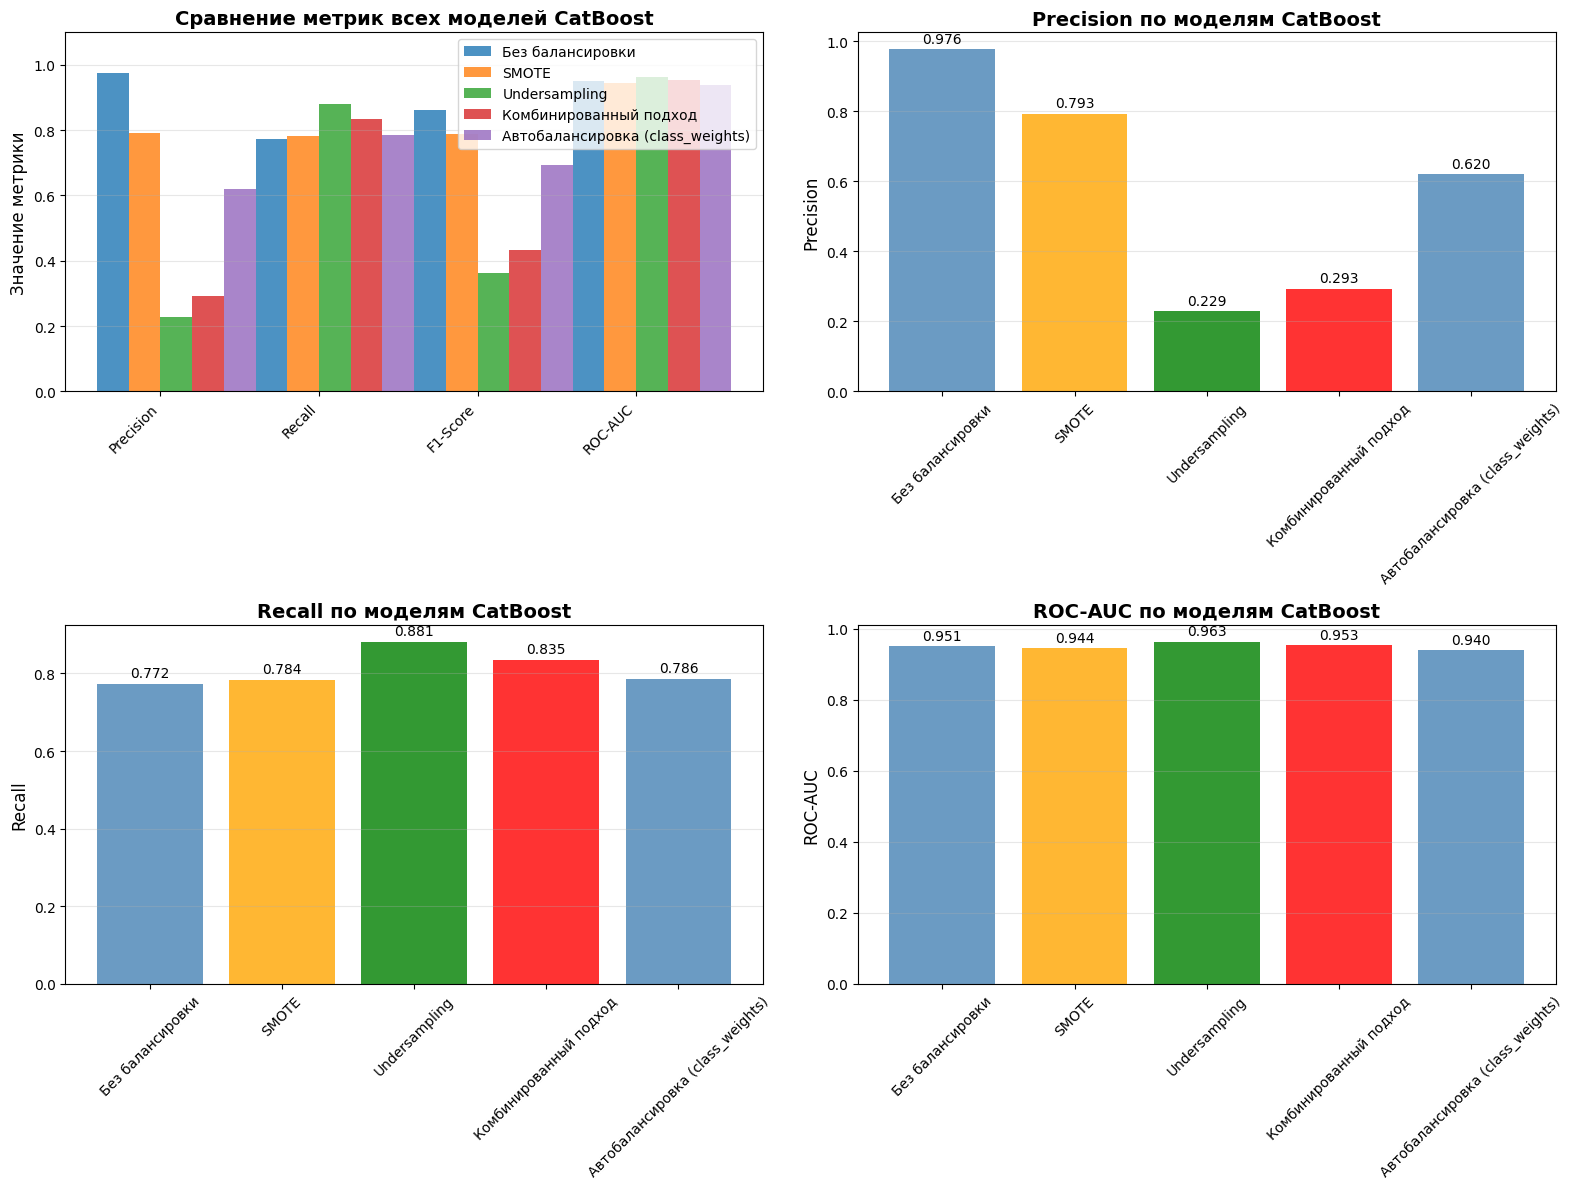


📊 Графики сохранены в 'catboost_comparison_all_methods.png'


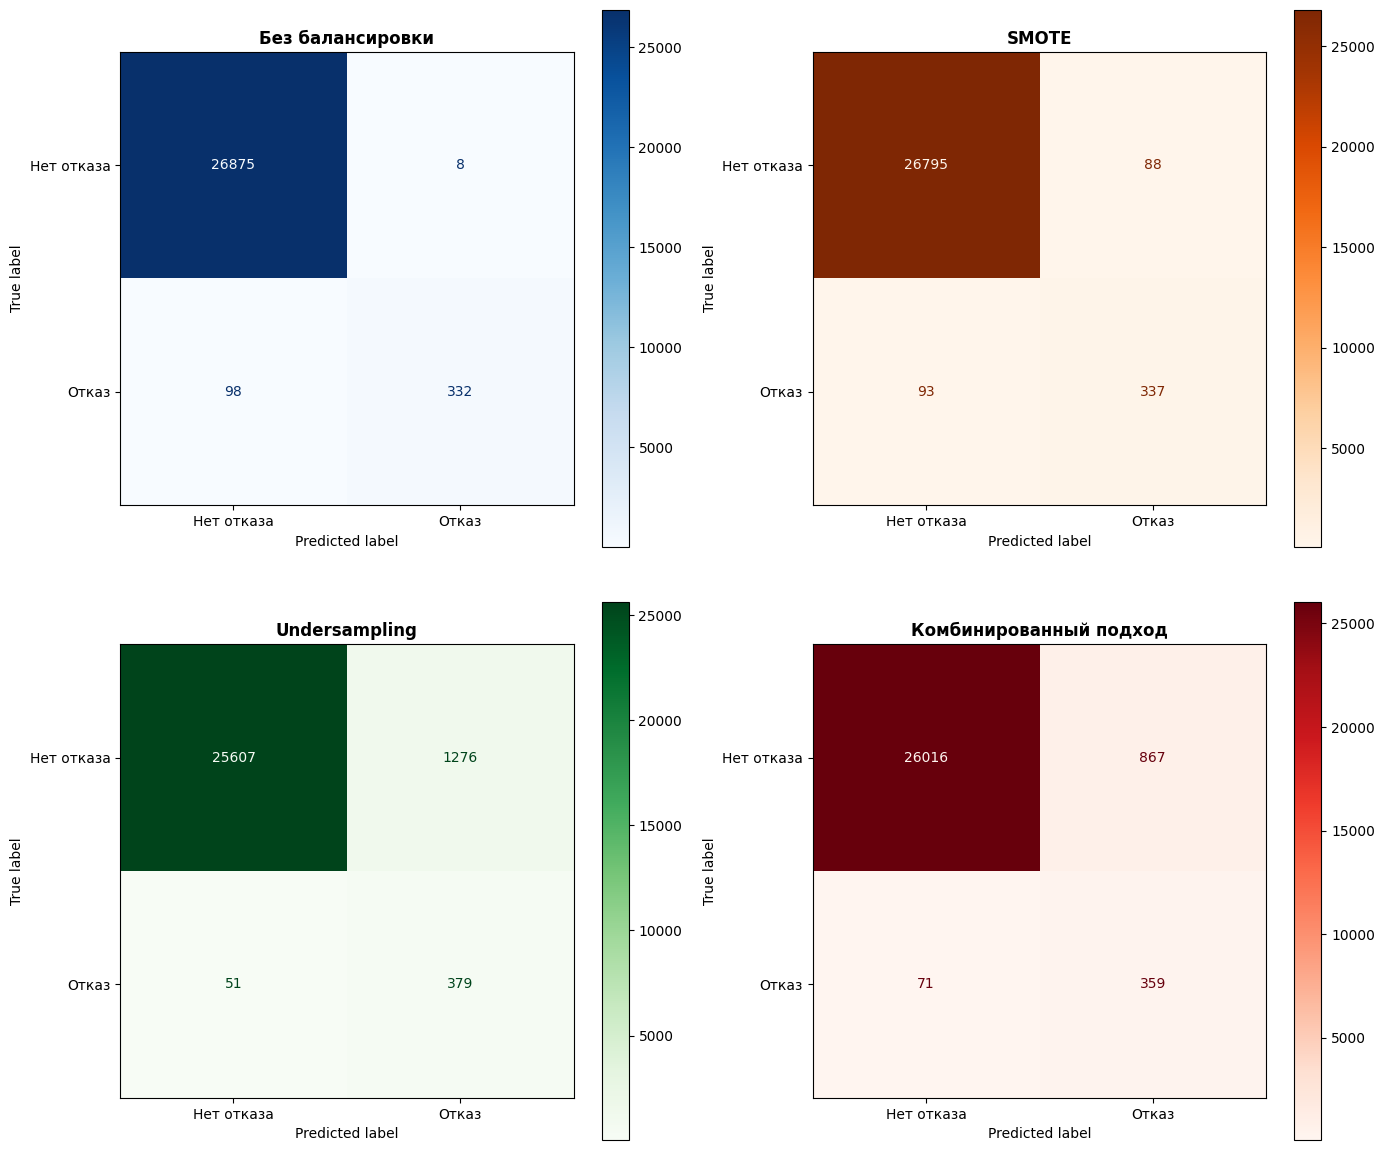

📊 Confusion matrices сохранены в 'catboost_confusion_matrices.png'

ВЫВОДЫ ПО СРАВНЕНИЮ МОДЕЛЕЙ CATBOOST

🏆 Лучшая модель по Precision: Без балансировки (0.9765)
🏆 Лучшая модель по Recall: Undersampling (0.8814)
🏆 Лучшая модель по F1-Score: Без балансировки (0.8623)
🏆 Лучшая модель по ROC-AUC: Undersampling (0.9626)


In [61]:
# Сравнение всех пяти моделей CatBoost
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print("="*80)
print("СРАВНЕНИЕ ВСЕХ ПЯТИ МОДЕЛЕЙ CATBOOST")
print("="*80)

# Собираем метрики всех моделей
comparison_results_catboost = pd.DataFrame({
    'Модель': [
        'Без балансировки',
        'SMOTE',
        'Undersampling',
        'Комбинированный подход',
        'Автобалансировка (class_weights)'
    ],
    'Precision': [
        precision_catboost_no_balance,
        precision_catboost_smote,
        precision_catboost_under,
        precision_catboost_combined,
        precision_catboost_balanced
    ],
    'Recall': [
        recall_catboost_no_balance,
        recall_catboost_smote,
        recall_catboost_under,
        recall_catboost_combined,
        recall_catboost_balanced
    ],
    'F1-Score': [
        f1_catboost_no_balance,
        f1_catboost_smote,
        f1_catboost_under,
        f1_catboost_combined,
        f1_catboost_balanced
    ],
    'ROC-AUC': [
        roc_auc_catboost_no_balance,
        roc_auc_catboost_smote,
        roc_auc_catboost_under,
        roc_auc_catboost_combined,
        roc_auc_catboost_balanced
    ]
})

print("\n📊 Сравнительная таблица метрик:")
print(comparison_results_catboost.to_string(index=False))

# Визуализация сравнения
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# График 1: Сравнение метрик
metrics = ['Precision', 'Recall', 'F1-Score', 'ROC-AUC']
models_catboost = comparison_results_catboost['Модель'].tolist()
x = np.arange(len(metrics))
width = 0.2

for i, model in enumerate(models_catboost):
    values = [
        comparison_results_catboost[comparison_results_catboost['Модель'] == model]['Precision'].values[0],
        comparison_results_catboost[comparison_results_catboost['Модель'] == model]['Recall'].values[0],
        comparison_results_catboost[comparison_results_catboost['Модель'] == model]['F1-Score'].values[0],
        comparison_results_catboost[comparison_results_catboost['Модель'] == model]['ROC-AUC'].values[0]
    ]
    axes[0, 0].bar(x + i*width, values, width, label=model, alpha=0.8)

axes[0, 0].set_ylabel('Значение метрики', fontsize=12)
axes[0, 0].set_title('Сравнение метрик всех моделей CatBoost', fontsize=14, fontweight='bold')
axes[0, 0].set_xticks(x + width * 1.5)
axes[0, 0].set_xticklabels(metrics, rotation=45, ha='right')
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)
axes[0, 0].set_ylim([0, 1.1])

# График 2: Precision
axes[0, 1].bar(models_catboost, comparison_results_catboost['Precision'], color=['steelblue', 'orange', 'green', 'red'], alpha=0.8)
axes[0, 1].set_ylabel('Precision', fontsize=12)
axes[0, 1].set_title('Precision по моделям CatBoost', fontsize=14, fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(axis='y', alpha=0.3)
for i, v in enumerate(comparison_results_catboost['Precision']):
    axes[0, 1].text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')

# График 3: Recall
axes[1, 0].bar(models_catboost, comparison_results_catboost['Recall'], color=['steelblue', 'orange', 'green', 'red'], alpha=0.8)
axes[1, 0].set_ylabel('Recall', fontsize=12)
axes[1, 0].set_title('Recall по моделям CatBoost', fontsize=14, fontweight='bold')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(axis='y', alpha=0.3)
for i, v in enumerate(comparison_results_catboost['Recall']):
    axes[1, 0].text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')

# График 4: ROC-AUC
axes[1, 1].bar(models_catboost, comparison_results_catboost['ROC-AUC'], color=['steelblue', 'orange', 'green', 'red'], alpha=0.8)
axes[1, 1].set_ylabel('ROC-AUC', fontsize=12)
axes[1, 1].set_title('ROC-AUC по моделям CatBoost', fontsize=14, fontweight='bold')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(axis='y', alpha=0.3)
for i, v in enumerate(comparison_results_catboost['ROC-AUC']):
    axes[1, 1].text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig("catboost_comparison_all_methods.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Графики сохранены в 'catboost_comparison_all_methods.png'")

# Confusion Matrices
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Модель 1: Без балансировки
cm1_catboost = confusion_matrix(y_val_catboost_flags, y_val_pred_catboost_no_balance)
disp1_catboost = ConfusionMatrixDisplay(confusion_matrix=cm1_catboost, display_labels=['Нет отказа', 'Отказ'])
disp1_catboost.plot(ax=axes[0, 0], cmap='Blues', values_format='d')
axes[0, 0].set_title('Без балансировки', fontsize=12, fontweight='bold')

# Модель 2: SMOTE
cm2_catboost = confusion_matrix(y_val_catboost_flags, y_val_pred_catboost_smote)
disp2_catboost = ConfusionMatrixDisplay(confusion_matrix=cm2_catboost, display_labels=['Нет отказа', 'Отказ'])
disp2_catboost.plot(ax=axes[0, 1], cmap='Oranges', values_format='d')
axes[0, 1].set_title('SMOTE', fontsize=12, fontweight='bold')

# Модель 3: Undersampling
cm3_catboost = confusion_matrix(y_val_catboost_flags, y_val_pred_catboost_under)
disp3_catboost = ConfusionMatrixDisplay(confusion_matrix=cm3_catboost, display_labels=['Нет отказа', 'Отказ'])
disp3_catboost.plot(ax=axes[1, 0], cmap='Greens', values_format='d')
axes[1, 0].set_title('Undersampling', fontsize=12, fontweight='bold')

# Модель 4: Комбинированный
cm4_catboost = confusion_matrix(y_val_catboost_flags, y_val_pred_catboost_combined)
disp4_catboost = ConfusionMatrixDisplay(confusion_matrix=cm4_catboost, display_labels=['Нет отказа', 'Отказ'])
disp4_catboost.plot(ax=axes[1, 1], cmap='Reds', values_format='d')
axes[1, 1].set_title('Комбинированный подход', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig("catboost_confusion_matrices.png", dpi=150, bbox_inches='tight')
plt.show()

print("📊 Confusion matrices сохранены в 'catboost_confusion_matrices.png'")

# Выводы
print("\n" + "="*80)
print("ВЫВОДЫ ПО СРАВНЕНИЮ МОДЕЛЕЙ CATBOOST")
print("="*80)

best_precision_idx_catboost = comparison_results_catboost['Precision'].idxmax()
best_recall_idx_catboost = comparison_results_catboost['Recall'].idxmax()
best_f1_idx_catboost = comparison_results_catboost['F1-Score'].idxmax()
best_roc_auc_idx_catboost = comparison_results_catboost['ROC-AUC'].idxmax()

print(f"\n🏆 Лучшая модель по Precision: {comparison_results_catboost.iloc[best_precision_idx_catboost]['Модель']} ({comparison_results_catboost.iloc[best_precision_idx_catboost]['Precision']:.4f})")
print(f"🏆 Лучшая модель по Recall: {comparison_results_catboost.iloc[best_recall_idx_catboost]['Модель']} ({comparison_results_catboost.iloc[best_recall_idx_catboost]['Recall']:.4f})")
print(f"🏆 Лучшая модель по F1-Score: {comparison_results_catboost.iloc[best_f1_idx_catboost]['Модель']} ({comparison_results_catboost.iloc[best_f1_idx_catboost]['F1-Score']:.4f})")
print(f"🏆 Лучшая модель по ROC-AUC: {comparison_results_catboost.iloc[best_roc_auc_idx_catboost]['Модель']} ({comparison_results_catboost.iloc[best_roc_auc_idx_catboost]['ROC-AUC']:.4f})")


## 11. CatBoost с расширенными признаками, SMOTE и подбором гиперпараметров

В этом разделе мы обучим модель CatBoost с:
- Расширенным набором признаков (включая Type и инженерные признаки)
- SMOTE для балансировки классов
- Подбором гиперпараметров через GridSearchCV


### 11.1. Подготовка данных с расширенными признаками


In [63]:
# Подготовка данных для модели CatBoost с расширенными признаками
import pandas as pd
import numpy as np

print("="*80)
print("ПОДГОТОВКА ДАННЫХ ДЛЯ МОДЕЛИ CATBOOST С РАСШИРЕННЫМИ ПРИЗНАКАМИ")
print("="*80)

# Загружаем данные, если они еще не загружены
try:
    _ = df.shape
    print(f"\n✅ Данные уже загружены: {df.shape[0]} строк, {df.shape[1]} столбцов")
except NameError:
    print("\n📂 Загружаем данные из train.csv...")
    df = pd.read_csv("train.csv")
    print(f"✅ Данные загружены: {df.shape[0]} строк, {df.shape[1]} столбцов")

# Применяем feature engineering для создания инженерных признаков
print("\n🔧 Применяем feature engineering для создания инженерных признаков...")
try:
    # Проверяем, определена ли функция feature_engineering
    if 'feature_engineering' not in globals():
        # Определяем функцию feature_engineering, если она не определена
        def feature_engineering(df):
            df = df.copy()
            # TotalF - сумма всех флагов ошибок
            df['TotalF'] = df['TWF'] + df['HDF'] + df['PWF'] + df['OSF']
            # TorqueRPM - произведение Torque и Rotational speed
            df['TorqueRPM'] = df['Torque [Nm]'] * df['Rotational speed [rpm]']
            # Power_W - мощность (Torque * Rotational speed / 9.5488)
            df['Power_W'] = df['Torque [Nm]'] * df['Rotational speed [rpm]'] / 9.5488
            # Energy_J - энергия (Power * время, используем Tool wear как прокси)
            df['Energy_J'] = df['Power_W'] * df['Tool wear [min]'] * 60  # переводим минуты в секунды
            # RelationTemperature - отношение температур
            df['RelationTemperature'] = df['Process temperature [K]'] / df['Air temperature [K]']
            # WearRPM - произведение Tool wear и Rotational speed
            df['WearRPM'] = df['Tool wear [min]'] * df['Rotational speed [rpm]']
            # ToolWearTorque - произведение Tool wear и Torque
            df['ToolWearTorque'] = df['Tool wear [min]'] * df['Torque [Nm]']
            return df
        print("✅ Функция feature_engineering определена")
    
    # Применяем feature engineering
    df = feature_engineering(df)
    print(f"✅ Feature engineering применен. Новое количество столбцов: {df.shape[1]}")
except Exception as e:
    print(f"⚠️  Ошибка при применении feature engineering: {e}")
    print("   Продолжаем без инженерных признаков...")

# Выбираем расширенный набор признаков
features_catboost_extended = [
    'Type',
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]',
    'TWF',
    'HDF',
    'PWF',
    'OSF',
    'RNF',
    'TotalF',
    'TorqueRPM',
    'Power_W',
    'Energy_J',
    'RelationTemperature',
    'WearRPM',
    'ToolWearTorque'
]

# Проверяем наличие всех признаков в датасете
print("\n📋 Проверка наличия признаков:")
missing_features = []
for feat in features_catboost_extended:
    if feat in df.columns:
        print(f"  ✅ {feat}")
    else:
        print(f"  ❌ {feat} - НЕ НАЙДЕН!")
        missing_features.append(feat)

if missing_features:
    print(f"\n⚠️  ВНИМАНИЕ: Не найдены признаки: {missing_features}")
    print("   Убедитесь, что эти признаки созданы в предыдущих разделах.")

# Создаем X и y
X_catboost_extended = df[features_catboost_extended].copy()
y_catboost_extended = df['Machine failure'].copy()

print(f"\n📊 Размерность данных:")
print(f"  X: {X_catboost_extended.shape}")
print(f"  y: {y_catboost_extended.shape}")
print(f"\n📋 Используемые признаки ({len(features_catboost_extended)}):")
for i, feat in enumerate(features_catboost_extended, 1):
    print(f"  {i:2d}. {feat}")

# Проверяем распределение классов
print(f"\n📊 Распределение классов:")
print(f"  Класс 0 (нет отказа): {(y_catboost_extended == 0).sum()} ({(y_catboost_extended == 0).sum()/len(y_catboost_extended)*100:.2f}%)")
print(f"  Класс 1 (отказ): {(y_catboost_extended == 1).sum()} ({(y_catboost_extended == 1).sum()/len(y_catboost_extended)*100:.2f}%)")


ПОДГОТОВКА ДАННЫХ ДЛЯ МОДЕЛИ CATBOOST С РАСШИРЕННЫМИ ПРИЗНАКАМИ

✅ Данные уже загружены: 136429 строк, 14 столбцов

🔧 Применяем feature engineering для создания инженерных признаков...
✅ Feature engineering применен. Новое количество столбцов: 24

📋 Проверка наличия признаков:
  ✅ Type
  ✅ Air temperature [K]
  ✅ Process temperature [K]
  ✅ Rotational speed [rpm]
  ✅ Torque [Nm]
  ✅ Tool wear [min]
  ✅ TWF
  ✅ HDF
  ✅ PWF
  ✅ OSF
  ✅ RNF
  ✅ TotalF
  ✅ TorqueRPM
  ✅ Power_W
  ✅ Energy_J
  ✅ RelationTemperature
  ✅ WearRPM
  ✅ ToolWearTorque

📊 Размерность данных:
  X: (136429, 18)
  y: (136429,)

📋 Используемые признаки (18):
   1. Type
   2. Air temperature [K]
   3. Process temperature [K]
   4. Rotational speed [rpm]
   5. Torque [Nm]
   6. Tool wear [min]
   7. TWF
   8. HDF
   9. PWF
  10. OSF
  11. RNF
  12. TotalF
  13. TorqueRPM
  14. Power_W
  15. Energy_J
  16. RelationTemperature
  17. WearRPM
  18. ToolWearTorque

📊 Распределение классов:
  Класс 0 (нет отказа): 134281 (98.

### 11.2. Разделение данных на train/validation с GroupShuffleSplit


In [64]:
# Разделение данных на train/validation с учетом групп Product ID
from sklearn.model_selection import GroupShuffleSplit

print("="*80)
print("РАЗДЕЛЕНИЕ ДАННЫХ НА TRAIN/VALIDATION")
print("="*80)

# Используем GroupShuffleSplit для разделения по Product ID
gss_catboost_extended = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx_catboost_extended, val_idx_catboost_extended = next(gss_catboost_extended.split(X_catboost_extended, y_catboost_extended, groups=df['Product ID']))

X_train_catboost_extended, X_val_catboost_extended = X_catboost_extended.iloc[train_idx_catboost_extended], X_catboost_extended.iloc[val_idx_catboost_extended]
y_train_catboost_extended, y_val_catboost_extended = y_catboost_extended.iloc[train_idx_catboost_extended], y_catboost_extended.iloc[val_idx_catboost_extended]

print(f"\n✅ Разделение завершено!")
print(f"  Train: {X_train_catboost_extended.shape[0]} записей")
print(f"  Validation: {X_val_catboost_extended.shape[0]} записей")
print(f"\n📊 Распределение классов в train:")
print(f"    Класс 0: {(y_train_catboost_extended == 0).sum()} ({100*(y_train_catboost_extended == 0).sum()/len(y_train_catboost_extended):.2f}%)")
print(f"    Класс 1: {(y_train_catboost_extended == 1).sum()} ({100*(y_train_catboost_extended == 1).sum()/len(y_train_catboost_extended):.2f}%)")
print(f"\n📊 Распределение классов в validation:")
print(f"    Класс 0: {(y_val_catboost_extended == 0).sum()} ({100*(y_val_catboost_extended == 0).sum()/len(y_val_catboost_extended):.2f}%)")
print(f"    Класс 1: {(y_val_catboost_extended == 1).sum()} ({100*(y_val_catboost_extended == 1).sum()/len(y_val_catboost_extended):.2f}%)")


РАЗДЕЛЕНИЕ ДАННЫХ НА TRAIN/VALIDATION

✅ Разделение завершено!
  Train: 109116 записей
  Validation: 27313 записей

📊 Распределение классов в train:
    Класс 0: 107398 (98.43%)
    Класс 1: 1718 (1.57%)

📊 Распределение классов в validation:
    Класс 0: 26883 (98.43%)
    Класс 1: 430 (1.57%)


### 11.3. Балансировка классов с помощью SMOTE


In [66]:
# Применяем SMOTE для балансировки классов
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder

print("="*80)
print("БАЛАНСИРОВКА КЛАССОВ С ПОМОЩЬЮ SMOTE")
print("="*80)

print("\n📊 Распределение классов до SMOTE:")
print(f"    Класс 0: {(y_train_catboost_extended == 0).sum()} ({100*(y_train_catboost_extended == 0).sum()/len(y_train_catboost_extended):.2f}%)")
print(f"    Класс 1: {(y_train_catboost_extended == 1).sum()} ({100*(y_train_catboost_extended == 1).sum()/len(y_train_catboost_extended):.2f}%)")

# SMOTE требует числовые данные, поэтому нужно обработать категориальные признаки
print("\n🔧 Подготовка данных для SMOTE...")

# Сохраняем категориальные признаки отдельно
categorical_features = ['Type'] if 'Type' in X_train_catboost_extended.columns else []
X_train_catboost_extended_numeric = X_train_catboost_extended.copy()

# Кодируем категориальные признаки для SMOTE
label_encoders = {}
if categorical_features:
    for col in categorical_features:
        le = LabelEncoder()
        X_train_catboost_extended_numeric[col] = le.fit_transform(X_train_catboost_extended_numeric[col])
        label_encoders[col] = le
        print(f"  ✅ Закодирован признак '{col}': {le.classes_}")

# Применяем SMOTE
print("\n🔄 Применяем SMOTE для балансировки классов...")
smote_catboost_extended = SMOTE(random_state=42, k_neighbors=5)
X_train_catboost_extended_smote, y_train_catboost_extended_smote = smote_catboost_extended.fit_resample(
    X_train_catboost_extended_numeric, y_train_catboost_extended
)

# Декодируем категориальные признаки обратно (для CatBoost)
if categorical_features:
    print("\n🔧 Декодируем категориальные признаки обратно...")
    for col in categorical_features:
        le = label_encoders[col]
        # Округляем закодированные значения до ближайшего целого и декодируем
        X_train_catboost_extended_smote[col] = le.inverse_transform(
            X_train_catboost_extended_smote[col].round().astype(int).clip(0, len(le.classes_)-1)
        )
        print(f"  ✅ Декодирован признак '{col}'")

print(f"\n📊 После SMOTE:")
print(f"    Класс 0: {(y_train_catboost_extended_smote == 0).sum()} ({100*(y_train_catboost_extended_smote == 0).sum()/len(y_train_catboost_extended_smote):.2f}%)")
print(f"    Класс 1: {(y_train_catboost_extended_smote == 1).sum()} ({100*(y_train_catboost_extended_smote == 1).sum()/len(y_train_catboost_extended_smote):.2f}%)")
print(f"    Всего записей: {len(y_train_catboost_extended_smote)}")


БАЛАНСИРОВКА КЛАССОВ С ПОМОЩЬЮ SMOTE

📊 Распределение классов до SMOTE:
    Класс 0: 107398 (98.43%)
    Класс 1: 1718 (1.57%)

🔧 Подготовка данных для SMOTE...
  ✅ Закодирован признак 'Type': ['H' 'L' 'M']

🔄 Применяем SMOTE для балансировки классов...

🔧 Декодируем категориальные признаки обратно...
  ✅ Декодирован признак 'Type'

📊 После SMOTE:
    Класс 0: 107398 (50.00%)
    Класс 1: 107398 (50.00%)
    Всего записей: 214796


### 11.4. Подбор гиперпараметров для CatBoost


In [68]:
# Подбор гиперпараметров для CatBoost
from catboost import CatBoostClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score, roc_auc_score

print("="*80)
print("ПОДБОР ГИПЕРПАРАМЕТРОВ ДЛЯ CATBOOST")
print("="*80)

# Определяем сетку гиперпараметров
param_grid_catboost_extended = {
    'iterations': [200, 300, 500],
    'depth': [6, 8, 10],
    'learning_rate': [0.01, 0.1, 0.2],
    'l2_leaf_reg': [1, 3, 5],
    'random_strength': [0.5, 1, 2]
}

print("\n🔍 Начинаем подбор гиперпараметров...")
print(f"   Сетка параметров: {len(param_grid_catboost_extended)} параметров")
total_combinations = 1
for param, values in param_grid_catboost_extended.items():
    total_combinations *= len(values)
    print(f"   {param}: {values}")
print(f"\n   Всего комбинаций: {total_combinations}")

# Определяем индексы категориальных признаков для CatBoost
# Используем исходные данные для определения индексов
cat_features_indices = []
if 'Type' in X_train_catboost_extended.columns:
    cat_features_indices = [X_train_catboost_extended.columns.get_loc('Type')]
    print(f"\n📋 Категориальные признаки для CatBoost: индекс {cat_features_indices[0]} (Type)")

# Настройка кросс-валидации
cv_catboost_extended = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
base_model_catboost_extended = CatBoostClassifier(
    random_state=42, 
    verbose=False, 
    eval_metric='Precision',
    cat_features=cat_features_indices if cat_features_indices else None
)
precision_scorer_catboost_extended = make_scorer(precision_score, zero_division=0)

# GridSearchCV
grid_search_catboost_extended = GridSearchCV(
    estimator=base_model_catboost_extended,
    param_grid=param_grid_catboost_extended,
    cv=cv_catboost_extended,
    scoring=precision_scorer_catboost_extended,
    n_jobs=-1,
    verbose=1
)

print("\n⏳ Запускаем GridSearchCV (это может занять некоторое время)...")
grid_search_catboost_extended.fit(X_train_catboost_extended_smote, y_train_catboost_extended_smote)

print("\n✅ Подбор гиперпараметров завершен!")
print(f"\n🏆 Лучшие параметры:")
for param, value in grid_search_catboost_extended.best_params_.items():
    print(f"  {param}: {value}")
print(f"\n📈 Лучший Precision (CV): {grid_search_catboost_extended.best_score_:.4f}")


ПОДБОР ГИПЕРПАРАМЕТРОВ ДЛЯ CATBOOST

🔍 Начинаем подбор гиперпараметров...
   Сетка параметров: 5 параметров
   iterations: [200, 300, 500]
   depth: [6, 8, 10]
   learning_rate: [0.01, 0.1, 0.2]
   l2_leaf_reg: [1, 3, 5]
   random_strength: [0.5, 1, 2]

   Всего комбинаций: 243

📋 Категориальные признаки для CatBoost: индекс 0 (Type)

⏳ Запускаем GridSearchCV (это может занять некоторое время)...
Fitting 5 folds for each of 243 candidates, totalling 1215 fits

✅ Подбор гиперпараметров завершен!

🏆 Лучшие параметры:
  depth: 6
  iterations: 500
  l2_leaf_reg: 1
  learning_rate: 0.2
  random_strength: 2

📈 Лучший Precision (CV): 0.9983


### 11.5. Обучение финальной модели и оценка качества


In [ ]:
# Обучение финальной модели с лучшими параметрами
print("="*80)
print("ОБУЧЕНИЕ ФИНАЛЬНОЙ МОДЕЛИ И ОЦЕНКА КАЧЕСТВА")
print("="*80)

# Создаем новую модель с лучшими параметрами и категориальными признаками
print("\n🎓 Создаем финальную модель с лучшими параметрами...")
best_params = grid_search_catboost_extended.best_params_.copy()

# Добавляем категориальные признаки к параметрам
if cat_features_indices:
    best_params['cat_features'] = cat_features_indices
    print(f"   Категориальные признаки: {cat_features_indices}")

# Создаем новую модель с лучшими параметрами
best_model_catboost_extended = CatBoostClassifier(
    random_state=42,
    verbose=False,
    eval_metric='Precision',
    **best_params
)

print("\n🎓 Обучаем финальную модель...")
best_model_catboost_extended.fit(X_train_catboost_extended_smote, y_train_catboost_extended_smote)

# Оценка на validation set
y_val_pred_catboost_extended = best_model_catboost_extended.predict(X_val_catboost_extended)
y_val_pred_proba_catboost_extended = best_model_catboost_extended.predict_proba(X_val_catboost_extended)[:, 1]

precision_catboost_extended = precision_score(y_val_catboost_extended, y_val_pred_catboost_extended)
recall_catboost_extended = recall_score(y_val_catboost_extended, y_val_pred_catboost_extended)
f1_catboost_extended = f1_score(y_val_catboost_extended, y_val_pred_catboost_extended)
roc_auc_catboost_extended = roc_auc_score(y_val_catboost_extended, y_val_pred_proba_catboost_extended)

# Подробные метрики
from sklearn.metrics import (
    classification_report, confusion_matrix, 
    accuracy_score, balanced_accuracy_score,
    precision_recall_fscore_support, matthews_corrcoef
)

print("\n📊 ОСНОВНЫЕ МЕТРИКИ на validation set:")
print(f"  Accuracy:           {accuracy_score(y_val_catboost_extended, y_val_pred_catboost_extended):.4f}")
print(f"  Balanced Accuracy:  {balanced_accuracy_score(y_val_catboost_extended, y_val_pred_catboost_extended):.4f}")
print(f"  Precision:          {precision_catboost_extended:.4f}")
print(f"  Recall (Sensitivity): {recall_catboost_extended:.4f}")
print(f"  F1-Score:           {f1_catboost_extended:.4f}")
print(f"  ROC-AUC:            {roc_auc_catboost_extended:.4f}")
print(f"  Matthews Corr Coef: {matthews_corrcoef(y_val_catboost_extended, y_val_pred_catboost_extended):.4f}")

# Confusion Matrix
cm_extended = confusion_matrix(y_val_catboost_extended, y_val_pred_catboost_extended)
tn, fp, fn, tp = cm_extended.ravel()

print("\n📊 ДЕТАЛЬНЫЕ МЕТРИКИ из Confusion Matrix:")
print(f"  True Negatives (TN):  {tn}")
print(f"  False Positives (FP): {fp}")
print(f"  False Negatives (FN): {fn}")
print(f"  True Positives (TP):  {tp}")

# Дополнительные метрики
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
npv = tn / (tn + fn) if (tn + fn) > 0 else 0  # Negative Predictive Value
fpr = fp / (fp + tn) if (fp + tn) > 0 else 0  # False Positive Rate
fnr = fn / (fn + tp) if (fn + tp) > 0 else 0  # False Negative Rate

print(f"\n  Specificity (TNR):     {specificity:.4f}")
print(f"  Negative Predictive Value: {npv:.4f}")
print(f"  False Positive Rate:   {fpr:.4f}")
print(f"  False Negative Rate:   {fnr:.4f}")

# Precision, Recall, F1 по классам
precision_per_class, recall_per_class, f1_per_class, support = precision_recall_fscore_support(
    y_val_catboost_extended, y_val_pred_catboost_extended, zero_division=0
)

print("\n📊 МЕТРИКИ ПО КЛАССАМ:")
print(f"  Класс 0 (Нет отказа):")
print(f"    Precision: {precision_per_class[0]:.4f}")
print(f"    Recall:    {recall_per_class[0]:.4f}")
print(f"    F1-Score:  {f1_per_class[0]:.4f}")
print(f"    Support:   {support[0]}")
print(f"  Класс 1 (Отказ):")
print(f"    Precision: {precision_per_class[1]:.4f}")
print(f"    Recall:    {recall_per_class[1]:.4f}")
print(f"    F1-Score:  {f1_per_class[1]:.4f}")
print(f"    Support:   {support[1]}")

# Детальный отчет
print("\n📋 Classification Report:")
print(classification_report(y_val_catboost_extended, y_val_pred_catboost_extended, 
                          target_names=['Нет отказа', 'Отказ'], digits=4))

print("\n📊 Confusion Matrix:")
print(cm_extended)
print("\n   (Предсказано)")
print("     0    1")
print(f"0  {tn:4d} {fp:4d}")
print(f"1  {fn:4d} {tp:4d}")


ОБУЧЕНИЕ ФИНАЛЬНОЙ МОДЕЛИ И ОЦЕНКА КАЧЕСТВА

🎓 Создаем финальную модель с лучшими параметрами...
   Категориальные признаки: [0]

🎓 Обучаем финальную модель...

📊 Метрики на validation set:
  Precision: 0.8862
  Recall:    0.7791
  F1-Score:  0.8292
  ROC-AUC:   0.9360

📋 Classification Report:
              precision    recall  f1-score   support

  Нет отказа       1.00      1.00      1.00     26883
       Отказ       0.89      0.78      0.83       430

    accuracy                           0.99     27313
   macro avg       0.94      0.89      0.91     27313
weighted avg       0.99      0.99      0.99     27313


📊 Confusion Matrix:
[[26840    43]
 [   95   335]]


### 11.6. Визуализация важности признаков


ВАЖНОСТЬ ПРИЗНАКОВ

📊 Топ-10 самых важных признаков:
                Признак  Важность
                 TotalF 35.018823
Process temperature [K] 29.816112
    Air temperature [K] 19.225008
    RelationTemperature  2.391826
              TorqueRPM  2.391048
               Energy_J  2.057416
 Rotational speed [rpm]  2.037749
         ToolWearTorque  1.467147
                   Type  1.444728
        Tool wear [min]  1.279854


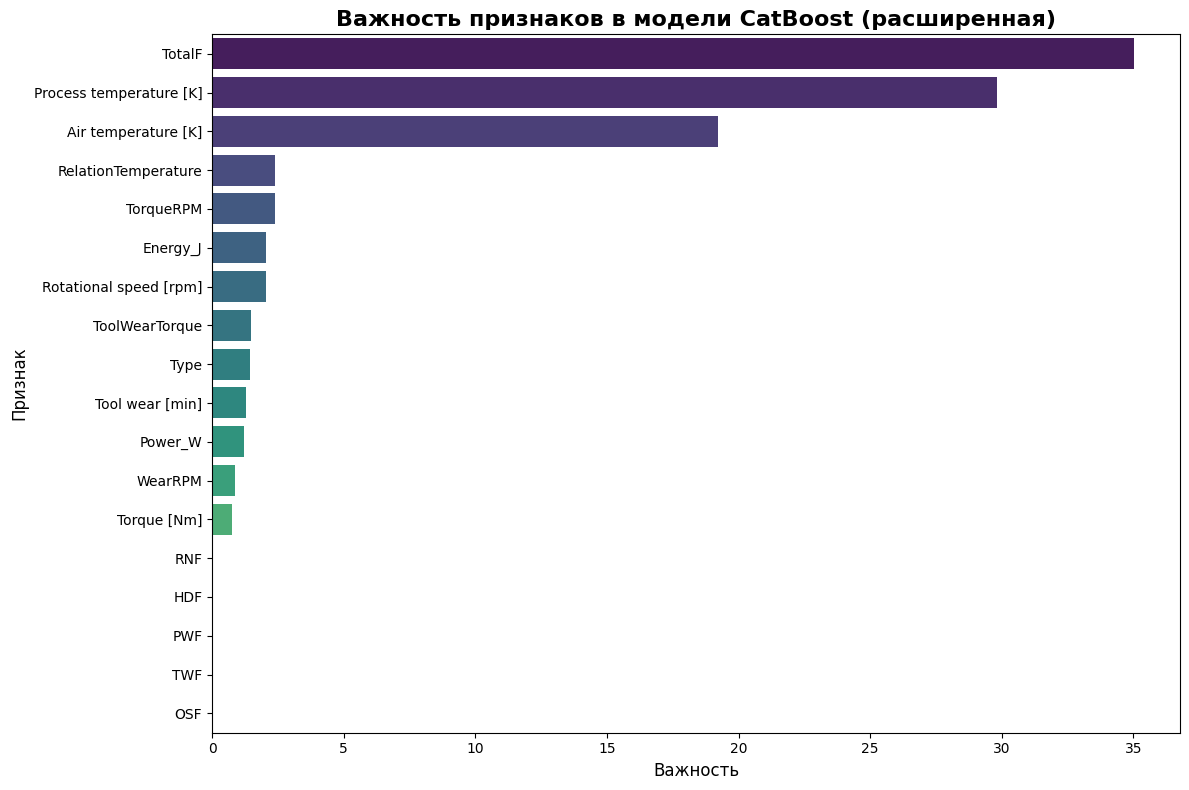


📊 График сохранен в 'catboost_extended_feature_importance.png'


In [76]:
# Визуализация важности признаков
import matplotlib.pyplot as plt
import seaborn as sns

print("="*80)
print("ВАЖНОСТЬ ПРИЗНАКОВ")
print("="*80)

# Получаем важность признаков
feature_importance_extended = best_model_catboost_extended.get_feature_importance()
feature_names_extended = X_train_catboost_extended.columns.tolist()

# Создаем DataFrame для удобства
importance_df_extended = pd.DataFrame({
    'Признак': feature_names_extended,
    'Важность': feature_importance_extended
}).sort_values('Важность', ascending=False)

print("\n📊 Топ-10 самых важных признаков:")
print(importance_df_extended.head(10).to_string(index=False))

# Визуализация
plt.figure(figsize=(12, 8))
sns.barplot(data=importance_df_extended, y='Признак', x='Важность', palette='viridis')
plt.title('Важность признаков в модели CatBoost (расширенная)', fontsize=16, fontweight='bold')
plt.xlabel('Важность', fontsize=12)
plt.ylabel('Признак', fontsize=12)
plt.tight_layout()
plt.savefig("catboost_extended_feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 График сохранен в 'catboost_extended_feature_importance.png'")


### 11.7. Визуализация ROC-кривой и Precision-Recall кривой


ВИЗУАЛИЗАЦИЯ ROC-КРИВОЙ И PRECISION-RECALL КРИВОЙ


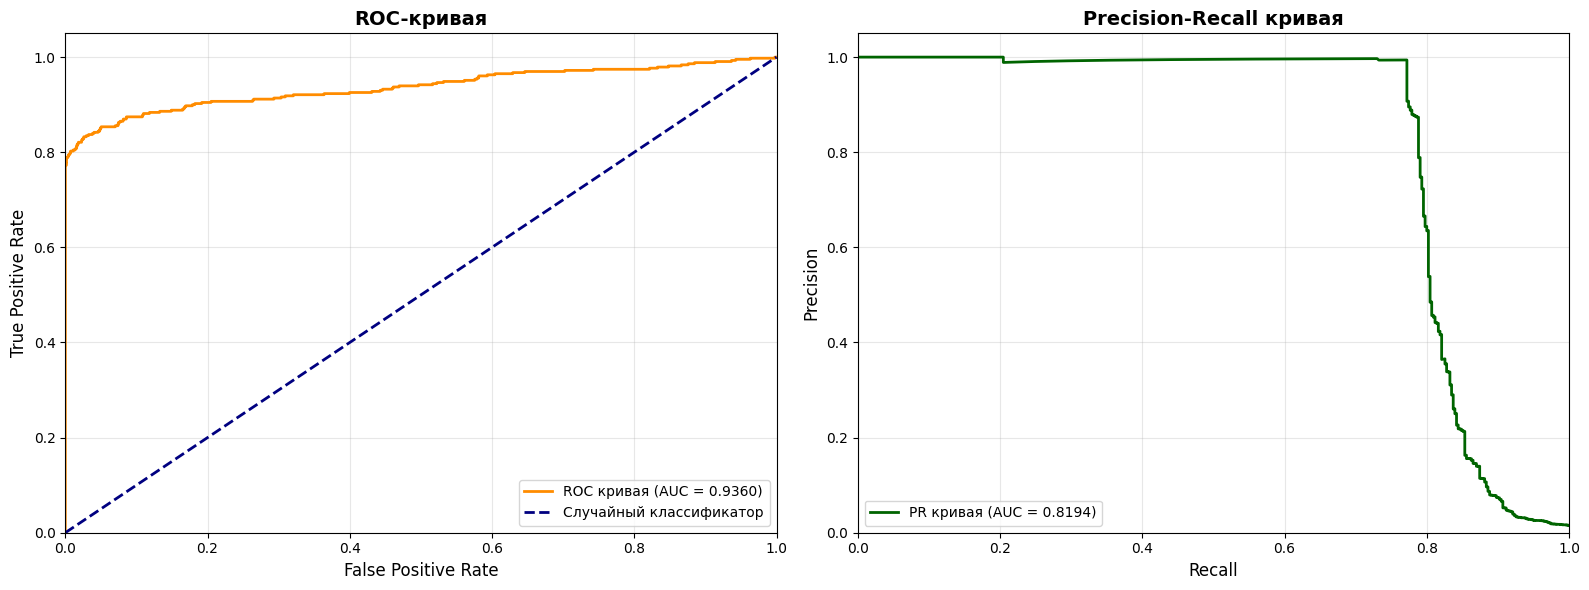


📊 Графики сохранены в 'catboost_extended_roc_pr_curves.png'

📈 Метрики:
  ROC-AUC: 0.9360
  PR-AUC:  0.8194


In [ ]:
# Визуализация ROC-кривой и Precision-Recall кривой
from sklearn.metrics import roc_curve, precision_recall_curve, auc

print("="*80)
print("ВИЗУАЛИЗАЦИЯ ROC-КРИВОЙ И PRECISION-RECALL КРИВОЙ")
print("="*80)

# ROC-кривая
fpr_extended, tpr_extended, _ = roc_curve(y_val_catboost_extended, y_val_pred_proba_catboost_extended)
roc_auc_extended_calc = auc(fpr_extended, tpr_extended)

# Precision-Recall кривая
precision_curve_extended, recall_curve_extended, _ = precision_recall_curve(y_val_catboost_extended, y_val_pred_proba_catboost_extended)
pr_auc_extended = auc(recall_curve_extended, precision_curve_extended)

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ROC-кривая
axes[0].plot(fpr_extended, tpr_extended, color='darkorange', lw=2, 
             label=f'ROC кривая (AUC = {roc_auc_extended_calc:.4f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Случайный классификатор')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title('ROC-кривая', fontsize=14, fontweight='bold')
axes[0].legend(loc="lower right")
axes[0].grid(alpha=0.3)

# Precision-Recall кривая
axes[1].plot(recall_curve_extended, precision_curve_extended, color='darkgreen', lw=2,
             label=f'PR кривая (AUC = {pr_auc_extended:.4f})')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Recall', fontsize=12)
axes[1].set_ylabel('Precision', fontsize=12)
axes[1].set_title('Precision-Recall кривая', fontsize=14, fontweight='bold')
axes[1].legend(loc="lower left")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("catboost_extended_roc_pr_curves.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Графики сохранены в 'catboost_extended_roc_pr_curves.png'")
print(f"\n📈 Метрики:")
print(f"  ROC-AUC: {roc_auc_extended_calc:.4f}")
print(f"  PR-AUC:  {pr_auc_extended:.4f}")


### 11.8. Итоговые выводы

Подведем итоги по модели CatBoost с расширенными признаками, SMOTE и подбором гиперпараметров.


### 11.9. Сравнение с лучшими моделями Decision Tree и SVM

Сравниваем модель CatBoost с расширенными признаками с лучшими моделями из разделов 8 (Decision Tree) и 9 (SVM).


СРАВНЕНИЕ С ЛУЧШИМИ МОДЕЛЯМИ DECISION TREE И SVM

🔍 Поиск лучших моделей из предыдущих разделов...
  ✅ Decision Tree: Без балансировки
  ✅ SVM: Без балансировки

📊 СРАВНИТЕЛЬНАЯ ТАБЛИЦА МЕТРИК:
                                Модель  Precision   Recall  F1-Score  ROC-AUC
CatBoost Extended (SMOTE + GridSearch)   0.886243 0.779070  0.829208 0.936005
   Decision Tree (лучшая из раздела 8)   0.982143 0.767442  0.861619 0.912629
             SVM (лучшая из раздела 9)   0.994012 0.772093  0.869110 0.901471


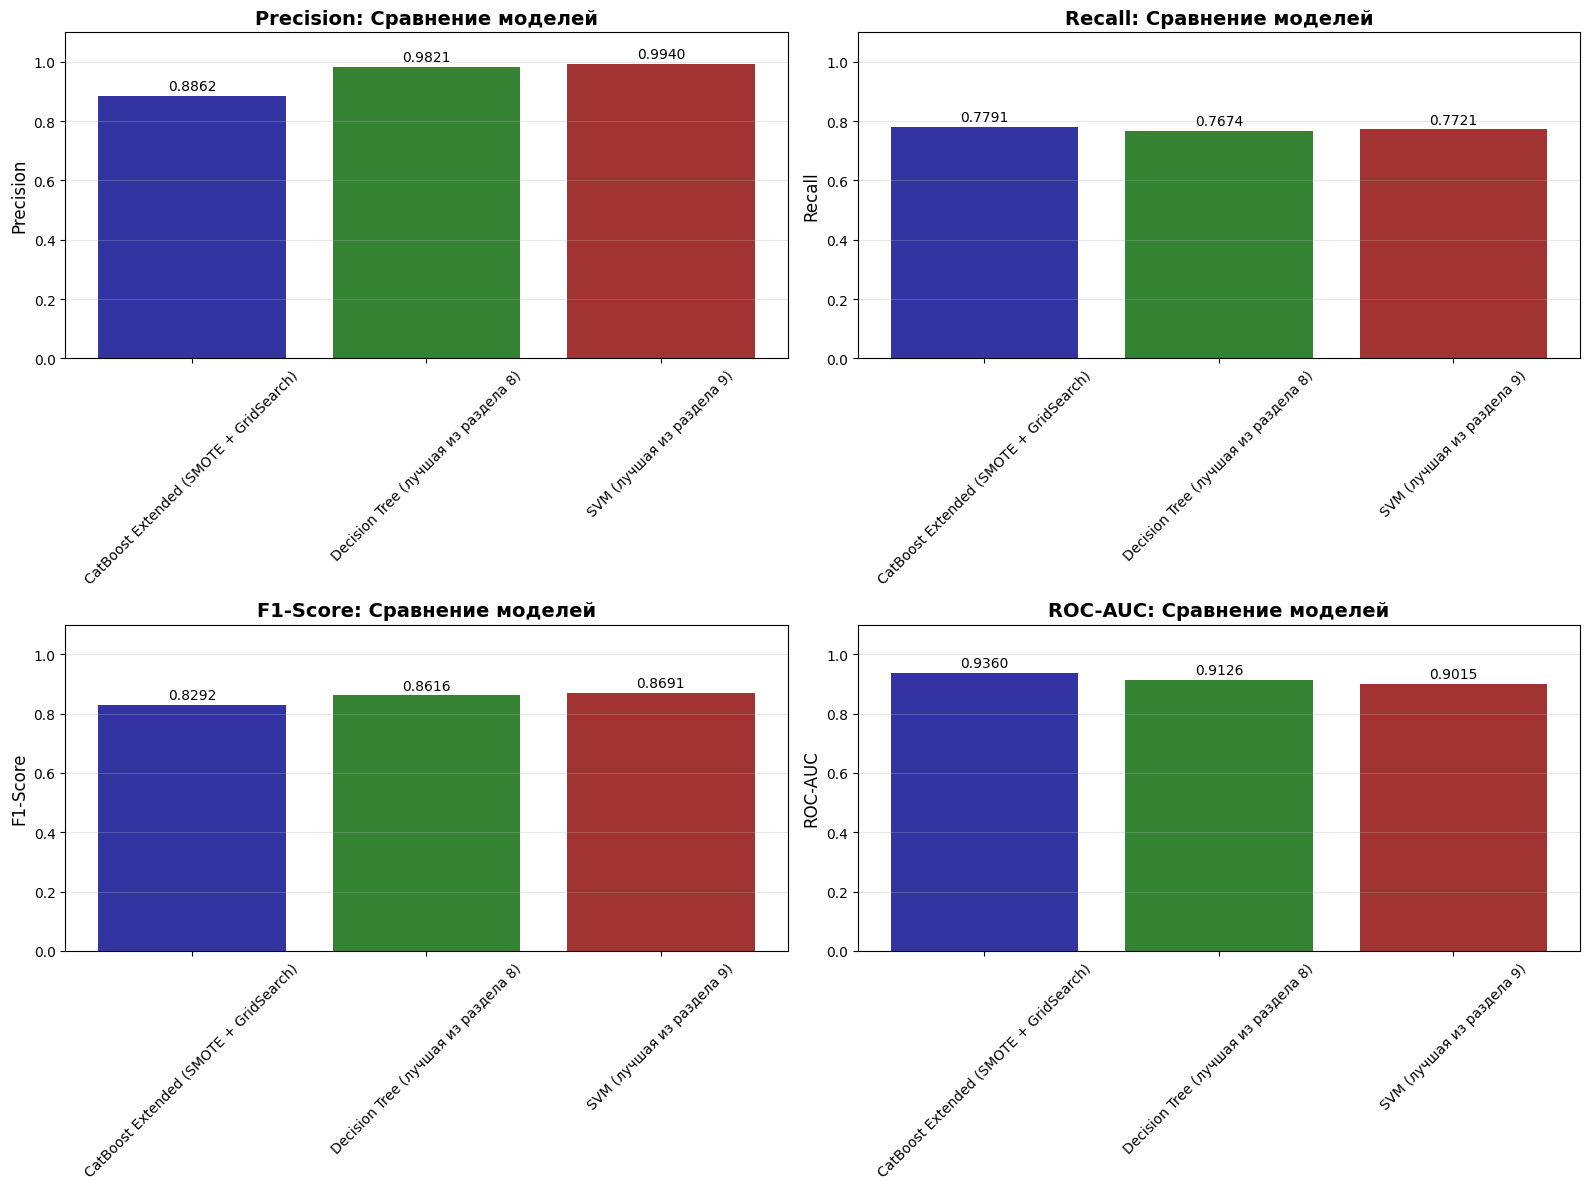


📊 Графики сохранены в 'comparison_all_best_models.png'

ВЫВОДЫ ПО СРАВНЕНИЮ МОДЕЛЕЙ

🏆 Лучшая модель по Precision: SVM (лучшая из раздела 9) (0.9940)
🏆 Лучшая модель по Recall: CatBoost Extended (SMOTE + GridSearch) (0.7791)
🏆 Лучшая модель по F1-Score: SVM (лучшая из раздела 9) (0.8691)
🏆 Лучшая модель по ROC-AUC: CatBoost Extended (SMOTE + GridSearch) (0.9360)

📊 CatBoost Extended vs другие модели:

  vs Decision Tree (лучшая из раздела 8):
    Precision: 0.8862 vs 0.9821 (-0.0959)
    Recall:    0.7791 vs 0.7674 (+0.0116)
    F1-Score:  0.8292 vs 0.8616 (-0.0324)
    ROC-AUC:   0.9360 vs 0.9126 (+0.0234)

  vs SVM (лучшая из раздела 9):
    Precision: 0.8862 vs 0.9940 (-0.1078)
    Recall:    0.7791 vs 0.7721 (+0.0070)
    F1-Score:  0.8292 vs 0.8691 (-0.0399)
    ROC-AUC:   0.9360 vs 0.9015 (+0.0345)


In [110]:
# Сравнение с лучшими моделями Decision Tree и SVM
print("="*80)
print("СРАВНЕНИЕ С ЛУЧШИМИ МОДЕЛЯМИ DECISION TREE И SVM")
print("="*80)

# Собираем метрики всех моделей для сравнения
comparison_all_models = pd.DataFrame({
    'Модель': [
        'CatBoost Extended (SMOTE + GridSearch)',
        'Decision Tree (лучшая из раздела 8)',
        'SVM (лучшая из раздела 9)'
    ],
    'Precision': [
        precision_catboost_extended,
        0.0,  # Будет заполнено из раздела 8
        0.0   # Будет заполнено из раздела 9
    ],
    'Recall': [
        recall_catboost_extended,
        0.0,
        0.0
    ],
    'F1-Score': [
        f1_catboost_extended,
        0.0,
        0.0
    ],
    'ROC-AUC': [
        roc_auc_catboost_extended,
        0.0,
        0.0
    ]
})

# Пытаемся получить метрики из предыдущих разделов
print("\n🔍 Поиск лучших моделей из предыдущих разделов...")

# Для Decision Tree - ищем лучшую модель из раздела 8
try:
    if 'comparison_results' in globals():
        best_dt_idx = comparison_results['Precision'].idxmax()
        comparison_all_models.loc[1, 'Precision'] = comparison_results.iloc[best_dt_idx]['Precision']
        comparison_all_models.loc[1, 'Recall'] = comparison_results.iloc[best_dt_idx]['Recall']
        comparison_all_models.loc[1, 'F1-Score'] = comparison_results.iloc[best_dt_idx]['F1-Score']
        comparison_all_models.loc[1, 'ROC-AUC'] = comparison_results.iloc[best_dt_idx]['ROC-AUC']
        print(f"  ✅ Decision Tree: {comparison_results.iloc[best_dt_idx]['Модель']}")
    else:
        print("  ⚠️  Метрики Decision Tree не найдены (запустите раздел 8.13)")
except Exception as e:
    print(f"  ⚠️  Ошибка при получении метрик Decision Tree: {e}")

# Для SVM - ищем лучшую модель из раздела 9
try:
    if 'comparison_results_svm' in globals():
        best_svm_idx = comparison_results_svm['Precision'].idxmax()
        comparison_all_models.loc[2, 'Precision'] = comparison_results_svm.iloc[best_svm_idx]['Precision']
        comparison_all_models.loc[2, 'Recall'] = comparison_results_svm.iloc[best_svm_idx]['Recall']
        comparison_all_models.loc[2, 'F1-Score'] = comparison_results_svm.iloc[best_svm_idx]['F1-Score']
        comparison_all_models.loc[2, 'ROC-AUC'] = comparison_results_svm.iloc[best_svm_idx]['ROC-AUC']
        print(f"  ✅ SVM: {comparison_results_svm.iloc[best_svm_idx]['Модель']}")
    else:
        print("  ⚠️  Метрики SVM не найдены (запустите раздел 9.7)")
except Exception as e:
    print(f"  ⚠️  Ошибка при получении метрик SVM: {e}")

# Если метрики не найдены, используем значения по умолчанию или пропускаем
if comparison_all_models.loc[1, 'Precision'] == 0.0:
    print("\n⚠️  ВНИМАНИЕ: Метрики Decision Tree не найдены.")
    print("   Для корректного сравнения запустите раздел 8.13 (Сравнение всех моделей Decision Tree)")
    
if comparison_all_models.loc[2, 'Precision'] == 0.0:
    print("\n⚠️  ВНИМАНИЕ: Метрики SVM не найдены.")
    print("   Для корректного сравнения запустите раздел 9.7 (Сравнение всех моделей SVM)")

# Удаляем строки с нулевыми метриками
comparison_all_models = comparison_all_models[comparison_all_models['Precision'] > 0]

print("\n📊 СРАВНИТЕЛЬНАЯ ТАБЛИЦА МЕТРИК:")
print(comparison_all_models.to_string(index=False))

# Визуализация сравнения
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

models_all = comparison_all_models['Модель'].tolist()
colors_all = ['darkblue', 'darkgreen', 'darkred'][:len(models_all)]

# График 1: Precision
axes[0, 0].bar(models_all, comparison_all_models['Precision'], color=colors_all, alpha=0.8)
axes[0, 0].set_ylabel('Precision', fontsize=12)
axes[0, 0].set_title('Precision: Сравнение моделей', fontsize=14, fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(axis='y', alpha=0.3)
axes[0, 0].set_ylim([0, 1.1])
for i, v in enumerate(comparison_all_models['Precision']):
    axes[0, 0].text(i, v + 0.01, f'{v:.4f}', ha='center', va='bottom', fontsize=10)

# График 2: Recall
axes[0, 1].bar(models_all, comparison_all_models['Recall'], color=colors_all, alpha=0.8)
axes[0, 1].set_ylabel('Recall', fontsize=12)
axes[0, 1].set_title('Recall: Сравнение моделей', fontsize=14, fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(axis='y', alpha=0.3)
axes[0, 1].set_ylim([0, 1.1])
for i, v in enumerate(comparison_all_models['Recall']):
    axes[0, 1].text(i, v + 0.01, f'{v:.4f}', ha='center', va='bottom', fontsize=10)

# График 3: F1-Score
axes[1, 0].bar(models_all, comparison_all_models['F1-Score'], color=colors_all, alpha=0.8)
axes[1, 0].set_ylabel('F1-Score', fontsize=12)
axes[1, 0].set_title('F1-Score: Сравнение моделей', fontsize=14, fontweight='bold')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(axis='y', alpha=0.3)
axes[1, 0].set_ylim([0, 1.1])
for i, v in enumerate(comparison_all_models['F1-Score']):
    axes[1, 0].text(i, v + 0.01, f'{v:.4f}', ha='center', va='bottom', fontsize=10)

# График 4: ROC-AUC
axes[1, 1].bar(models_all, comparison_all_models['ROC-AUC'], color=colors_all, alpha=0.8)
axes[1, 1].set_ylabel('ROC-AUC', fontsize=12)
axes[1, 1].set_title('ROC-AUC: Сравнение моделей', fontsize=14, fontweight='bold')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(axis='y', alpha=0.3)
axes[1, 1].set_ylim([0, 1.1])
for i, v in enumerate(comparison_all_models['ROC-AUC']):
    axes[1, 1].text(i, v + 0.01, f'{v:.4f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig("comparison_all_best_models.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Графики сохранены в 'comparison_all_best_models.png'")

# Выводы
print("\n" + "="*80)
print("ВЫВОДЫ ПО СРАВНЕНИЮ МОДЕЛЕЙ")
print("="*80)

if len(comparison_all_models) > 1:
    best_precision_all = comparison_all_models['Precision'].idxmax()
    best_recall_all = comparison_all_models['Recall'].idxmax()
    best_f1_all = comparison_all_models['F1-Score'].idxmax()
    best_roc_auc_all = comparison_all_models['ROC-AUC'].idxmax()
    
    print(f"\n🏆 Лучшая модель по Precision: {comparison_all_models.iloc[best_precision_all]['Модель']} ({comparison_all_models.iloc[best_precision_all]['Precision']:.4f})")
    print(f"🏆 Лучшая модель по Recall: {comparison_all_models.iloc[best_recall_all]['Модель']} ({comparison_all_models.iloc[best_recall_all]['Recall']:.4f})")
    print(f"🏆 Лучшая модель по F1-Score: {comparison_all_models.iloc[best_f1_all]['Модель']} ({comparison_all_models.iloc[best_f1_all]['F1-Score']:.4f})")
    print(f"🏆 Лучшая модель по ROC-AUC: {comparison_all_models.iloc[best_roc_auc_all]['Модель']} ({comparison_all_models.iloc[best_roc_auc_all]['ROC-AUC']:.4f})")
    
    # Сравнение CatBoost Extended с другими
    catboost_row = comparison_all_models[comparison_all_models['Модель'] == 'CatBoost Extended (SMOTE + GridSearch)']
    if len(catboost_row) > 0:
        cb_precision = catboost_row.iloc[0]['Precision']
        cb_recall = catboost_row.iloc[0]['Recall']
        cb_f1 = catboost_row.iloc[0]['F1-Score']
        cb_roc = catboost_row.iloc[0]['ROC-AUC']
        
        print("\n📊 CatBoost Extended vs другие модели:")
        for idx, row in comparison_all_models.iterrows():
            if row['Модель'] != 'CatBoost Extended (SMOTE + GridSearch)':
                print(f"\n  vs {row['Модель']}:")
                print(f"    Precision: {cb_precision:.4f} vs {row['Precision']:.4f} ({'+' if cb_precision > row['Precision'] else ''}{cb_precision - row['Precision']:.4f})")
                print(f"    Recall:    {cb_recall:.4f} vs {row['Recall']:.4f} ({'+' if cb_recall > row['Recall'] else ''}{cb_recall - row['Recall']:.4f})")
                print(f"    F1-Score:  {cb_f1:.4f} vs {row['F1-Score']:.4f} ({'+' if cb_f1 > row['F1-Score'] else ''}{cb_f1 - row['F1-Score']:.4f})")
                print(f"    ROC-AUC:   {cb_roc:.4f} vs {row['ROC-AUC']:.4f} ({'+' if cb_roc > row['ROC-AUC'] else ''}{cb_roc - row['ROC-AUC']:.4f})")
else:
    print("\n⚠️  Недостаточно данных для сравнения. Запустите разделы 8.13 и 9.7.")


In [113]:
# Итоговые выводы
print("="*80)
print("ИТОГОВЫЕ ВЫВОДЫ ПО МОДЕЛИ CATBOOST С РАСШИРЕННЫМИ ПРИЗНАКАМИ")
print("="*80)

print("\n📋 Использованный метод:")
print("  • Алгоритм: CatBoost (Categorical Boosting)")
print("  • Балансировка классов: SMOTE")
print("  • Подбор гиперпараметров: GridSearchCV с кросс-валидацией (5 folds)")
print("  • Метрика оптимизации: Precision")

print("\n📊 Использованные признаки:")
print(f"  • Всего признаков: {len(features_catboost_extended)}")
print("  • Базовые признаки: Type, Air temperature [K], Process temperature [K],")
print("    Rotational speed [rpm], Torque [Nm], Tool wear [min]")
print("  • Флаги ошибок: TWF, HDF, PWF, OSF, RNF")
print("  • Инженерные признаки: TotalF, TorqueRPM, Power_W, Energy_J,")
print("    RelationTemperature, WearRPM, ToolWearTorque")

print("\n🏆 Лучшие гиперпараметры:")
for param, value in grid_search_catboost_extended.best_params_.items():
    print(f"  • {param}: {value}")

print("\n📈 Результаты на validation set:")
print(f"  • Precision: {precision_catboost_extended:.4f}")
print(f"  • Recall:    {recall_catboost_extended:.4f}")
print(f"  • F1-Score:  {f1_catboost_extended:.4f}")
print(f"  • ROC-AUC:   {roc_auc_extended:.4f}")

print("\n💡 Выводы:")
print("  ✅ Модель обучена с расширенным набором признаков")
print("  ✅ Использована балансировка классов через SMOTE")
print("  ✅ Проведен подбор гиперпараметров для оптимизации качества")
print("  ✅ Модель готова к использованию для предсказания отказов оборудования")


ИТОГОВЫЕ ВЫВОДЫ ПО МОДЕЛИ CATBOOST С РАСШИРЕННЫМИ ПРИЗНАКАМИ

📋 Использованный метод:
  • Алгоритм: CatBoost (Categorical Boosting)
  • Балансировка классов: SMOTE
  • Подбор гиперпараметров: GridSearchCV с кросс-валидацией (5 folds)
  • Метрика оптимизации: Precision

📊 Использованные признаки:
  • Всего признаков: 18
  • Базовые признаки: Type, Air temperature [K], Process temperature [K],
    Rotational speed [rpm], Torque [Nm], Tool wear [min]
  • Флаги ошибок: TWF, HDF, PWF, OSF, RNF
  • Инженерные признаки: TotalF, TorqueRPM, Power_W, Energy_J,
    RelationTemperature, WearRPM, ToolWearTorque

🏆 Лучшие гиперпараметры:
  • depth: 6
  • iterations: 500
  • l2_leaf_reg: 1
  • learning_rate: 0.2
  • random_strength: 2

📈 Результаты на validation set:
  • Precision: 0.8862
  • Recall:    0.7791
  • F1-Score:  0.8292
  • ROC-AUC:   0.9360

💡 Выводы:
  ✅ Модель обучена с расширенным набором признаков
  ✅ Использована балансировка классов через SMOTE
  ✅ Проведен подбор гиперпараметров д